In [1]:
import pandas as pd
import xarray as xr
import numpy as np
import netCDF4
# import nc_time_axis
import matplotlib.pyplot as plt
import glob
import cmocean
import xskillscore as xs
import datetime
# from sklearn.metrics import mean_squared_error

import h5py
from scipy.io import loadmat
from scipy import signal
from scipy.interpolate import griddata
import cartopy.crs as ccrs

In [5]:
## Working directory
wrk_dir = '~/work/OBS/dashcams_data/plotting_for_draft_supplementary/'

# Load SST

In [4]:
# load satellite data (2007-2021)

for iy in range(2020,2025):
    print(iy)
    with h5py.File(f'/home/server/pi/homes/liux8/work/OBS/xliu_obs_process/model_satellite/sst_data/sst_{iy}_MUR.mat', 'r') as file:
        def print_attrs(name, obj):
            print(name)
            for key, val in obj.attrs.items():
                print(f"    {key}: {val}")
        
        sst0 = file['sst'][:]
        if iy < 2023:
            sst0=sst0-273.15
        
        # sst_mean = np.nanmean(np.nanmean(sst,axis=1),axis=1)
        if iy==2020:
            sst = sst0
        else:
            sst = np.concatenate((sst,sst0),axis=0)
            
            # sst_mean0 = np.concatenate((sst_mean0,sst_mean),axis=0)
            
        file.visititems(print_attrs)


2020
ilon1
    MATLAB_class: b'double'
jlat1
    MATLAB_class: b'double'
sst
    MATLAB_class: b'double'
2021
ilon1
    MATLAB_class: b'double'
jlat1
    MATLAB_class: b'double'
sst
    MATLAB_class: b'double'
2022
ilon1
    MATLAB_class: b'double'
jlat1
    MATLAB_class: b'double'
sst
    MATLAB_class: b'double'
2023
ilon1
    MATLAB_class: b'double'
jlat1
    MATLAB_class: b'double'
sst
    MATLAB_class: b'double'
2024
ilon1
    MATLAB_class: b'double'
jlat1
    MATLAB_class: b'double'
sst
    MATLAB_class: b'double'


In [5]:
lon0 = loadmat('/home/server/pi/homes/liux8/work/OBS/xliu_obs_process/sst_lonlat_MUR.mat')['lon']
lat0 = loadmat('/home/server/pi/homes/liux8/work/OBS/xliu_obs_process/sst_lonlat_MUR.mat')['lat']

ilon = loadmat('/home/server/pi/homes/liux8/work/OBS/xliu_obs_process/sst_ilon_ilat_MUR.mat')['ilon1']
jlat = loadmat('/home/server/pi/homes/liux8/work/OBS/xliu_obs_process/sst_ilon_ilat_MUR.mat')['jlat1']

lon_mur = lon0[ilon[0,0].astype(int)-1:ilon[-1,0].astype(int)]
lat_mur = lat0[jlat[0,0].astype(int)-1:jlat[-1,0].astype(int)]

In [6]:
tdim = sst.shape[0]
print(tdim)
da_mur = xr.DataArray(sst, coords={'time': np.arange(0,tdim*86400,86400)+50*365*86400+12*86400,'lon': lon_mur[:,0] ,'lat': lat_mur[:,0]},
                  dims=['time','lat','lon'])

# da2_mur = da_mur.interp(lon=datasets_era[0].lonc,lat=datasets_era[0].latc,method='linear')

ds_mur = xr.Dataset({'sst': da_mur})
ds_mur['time'] = pd.to_datetime(ds_mur['time'].values,unit='s')
# ds_dust['time'] = pd.to_datetime(ds_dust['time'].values,unit='s')

1735


# load raw data

## can use NC file below directly

In [7]:
ID_deploy = 'UAEBUSO20'

file1=wrk_dir+f'PG_dive_raw_v1_longrec_keepGPS_{ID_deploy}.csv'; ptime=165
# file1='surf_processed/Jul_Sep_2021.csv'; ptime=220
# file1='surf_processed/Oct_Dec_2021.csv'

# yr=file1[-21:-17]
# yr=file1[-13:-9]
df = pd.read_csv(file1,parse_dates=True,index_col='UTC_datetime')

/tmp/ipykernel_553418/3571139322.py:9: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file1,parse_dates=True,index_col='UTC_datetime')


In [8]:
df[(pd.to_datetime(df['date'])>=pd.to_datetime('2021-5-15 3:36'))&(pd.to_datetime(df['date'])<=pd.to_datetime('2021-5-15 9:42'))]

,device_id,UTC_date,UTC_time,datatype,satcount,Latitude,Longitude,int_temperature_C,UTC_timestamp,milliseconds,depth_m,ext_temperature_C,date
UTC_datetime,,,,,,,,,,,,,
2021-05-15 03:50:44,203018,2021-05-15,03:50:44,GPSS,11.0,25.253420,55.180595,42.0,2021-05-15 03:50:44.896,896.0,NaN,NaN,2021-05-15 03:50:44
2021-05-15 04:10:45,203018,2021-05-15,04:10:45,GPSS,9.0,25.253160,55.180298,45.0,2021-05-15 04:10:45.853,853.0,NaN,NaN,2021-05-15 04:10:45
2021-05-15 04:30:45,203018,2021-05-15,04:30:45,GPSS,9.0,25.251207,55.177139,32.0,2021-05-15 04:30:45.882,882.0,NaN,NaN,2021-05-15 04:30:45
2021-05-15 04:50:44,203018,2021-05-15,04:50:44,GPSS,9.0,25.251192,55.177551,42.0,2021-05-15 04:50:44.899,899.0,NaN,NaN,2021-05-15 04:50:44
2021-05-15 05:10:44,203018,2021-05-15,05:10:44,GPSS,10.0,25.251369,55.177410,47.0,2021-05-15 05:10:44.889,889.0,NaN,NaN,2021-05-15 05:10:44
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-05-15 08:13:47,201411,2021-05-15,08:13:47,GPSD,6.0,25.251188,55.177589,40.0,2021-05-15 08:13:47.611,611.0,NaN,NaN,2021-05-15 08:13:47
2021-05-15 08:33:47,201411,2021-05-15,08:33:47,GPSD,7.0,25.251490,55.177437,40.0,2021-05-15 08:33:47.628,628.0,NaN,NaN,2021-05-15 08:33:47
2021-05-15 08:53:47,201411,2021-05-15,08:53:47,GPS,7.0,25.251476,55.177315,41.0,2021-05-15 08:53:47.629,629.0,NaN,NaN,2021-05-15 08:53:47


In [9]:
df['t'] = pd.to_datetime(df['date']) + pd.to_timedelta(df['milliseconds'], unit='ms')

In [10]:
df['date2'] = df['t']
df = df.set_index('t')
df

,device_id,UTC_date,UTC_time,datatype,satcount,Latitude,Longitude,int_temperature_C,UTC_timestamp,milliseconds,depth_m,ext_temperature_C,date,date2
t,,,,,,,,,,,,,,
2020-11-02 20:11:05.000,203018,2020-11-02,20:11:05,GPS,6.0,44.5583,-123.2715,16.0,2020-11-02 20:11:05.000,0.0,NaN,NaN,2020-11-02 20:11:05,2020-11-02 20:11:05.000
2020-11-02 22:14:06.000,203018,2020-11-02,22:14:06,GPS,0.0,0.0000,0.0000,26.0,2020-11-02 22:14:06.000,0.0,NaN,NaN,2020-11-02 22:14:06,2020-11-02 22:14:06.000
2020-11-02 22:19:19.100,203018,2020-11-02,22:19:19,SEND_ALL2_10Hz_START,NaN,NaN,NaN,NaN,2020-11-02 22:19:19.2020-11-02 22:19:19.100,100.0,0.58,14.671875,2020-11-02 22:19:19,2020-11-02 22:19:19.100
2020-11-02 22:19:19.200,203018,2020-11-02,22:19:19,SEND_ALL2_10Hz,NaN,NaN,NaN,NaN,2020-11-02 22:19:19.2020-11-02 22:19:19.200,200.0,0.64,14.429688,2020-11-02 22:19:19,2020-11-02 22:19:19.200
2020-11-02 22:19:19.300,203018,2020-11-02,22:19:19,SEND_ALL2_10Hz,NaN,NaN,NaN,NaN,2020-11-02 22:19:19.2020-11-02 22:19:19.300,300.0,0.69,14.250000,2020-11-02 22:19:19,2020-11-02 22:19:19.300
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-08-13 22:22:22.000,201411,2021-08-13,22:22:22,GPSS,0.0,0.0000,0.0000,43.0,2021-08-13 22:22:22.000,0.0,NaN,NaN,2021-08-13 22:22:22,2021-08-13 22:22:22.000
2021-08-14 01:22:22.000,201411,2021-08-14,01:22:22,GPSS,0.0,0.0000,0.0000,43.0,2021-08-14 01:22:22.000,0.0,NaN,NaN,2021-08-14 01:22:22,2021-08-14 01:22:22.000
2021-08-14 04:22:22.000,201411,2021-08-14,04:22:22,GPSS,0.0,0.0000,0.0000,43.0,2021-08-14 04:22:22.000,0.0,NaN,NaN,2021-08-14 04:22:22,2021-08-14 04:22:22.000


In [11]:
df[(df['date2']>=pd.to_datetime('2021-5-23 1:21'))&(df['date2']<=pd.to_datetime('2021-5-23 6:50'))]

,device_id,UTC_date,UTC_time,datatype,satcount,Latitude,Longitude,int_temperature_C,UTC_timestamp,milliseconds,depth_m,ext_temperature_C,date,date2
t,,,,,,,,,,,,,,
2021-05-23 01:25:36.000,203018,2021-05-23,01:25:36,GPSD,8.0,25.252386,55.176315,33.0,2021-05-23 01:25:36.000,0.0,NaN,NaN,2021-05-23 01:25:36,2021-05-23 01:25:36.000
2021-05-23 01:45:36.662,203018,2021-05-23,01:45:36,GPSD,9.0,25.252392,55.176651,32.0,2021-05-23 01:45:36.662,662.0,NaN,NaN,2021-05-23 01:45:36,2021-05-23 01:45:36.662
2021-05-23 02:05:36.646,203018,2021-05-23,02:05:36,GPSD,8.0,25.252457,55.176556,33.0,2021-05-23 02:05:36.646,646.0,NaN,NaN,2021-05-23 02:05:36,2021-05-23 02:05:36.646
2021-05-23 02:25:35.596,203018,2021-05-23,02:25:35,GPSD,8.0,25.252579,55.176250,37.0,2021-05-23 02:25:35.596,596.0,NaN,NaN,2021-05-23 02:25:35,2021-05-23 02:25:35.596
2021-05-23 02:45:37.000,203018,2021-05-23,02:45:37,GPSD,9.0,25.252506,55.176598,36.0,2021-05-23 02:45:37.000,0.0,NaN,NaN,2021-05-23 02:45:37,2021-05-23 02:45:37.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-05-23 06:23:06.000,201411,2021-05-23,06:23:06,GPSD,14.0,25.236813,55.101410,34.0,2021-05-23 06:23:06.000,0.0,NaN,NaN,2021-05-23 06:23:06,2021-05-23 06:23:06.000
2021-05-23 06:23:07.000,201411,2021-05-23,06:23:07,GPSD,12.0,25.236820,55.101410,34.0,2021-05-23 06:23:07.000,0.0,NaN,NaN,2021-05-23 06:23:07,2021-05-23 06:23:07.000
2021-05-23 06:23:08.000,201411,2021-05-23,06:23:08,GPSD,13.0,25.236826,55.101406,34.0,2021-05-23 06:23:08.000,0.0,NaN,NaN,2021-05-23 06:23:08,2021-05-23 06:23:08.000


In [12]:
# df1 = df.loc[df['device_id']==203013]

# x = xr.DataArray(df.Longitude_1, dims="t")
# y = xr.DataArray(df.Latitude_1, dims="t")
time = xr.DataArray(df.date2, dims="t")
did = xr.DataArray(df.device_id, dims="t")
# accx = xr.DataArray(df.acc_x,dims='t')
# accy = xr.DataArray(df.acc_y,dims='t')
# accz = xr.DataArray(df.acc_z,dims='t')
lon = xr.DataArray(df.Longitude,dims='t')
lat = xr.DataArray(df.Latitude,dims='t')
datatype = xr.DataArray(df.datatype,dims='t')
depth = xr.DataArray(df.depth_m,dims='t')
temp = xr.DataArray(df.ext_temperature_C, dims="t")
temp_int = xr.DataArray(df.int_temperature_C, dims="t")
# conduc = xr.DataArray(df['conductivity_mS/cm'], dims="t")

ds_obs = xr.Dataset({
    # 'x': x,
    # 'y': y,
    'time': time,
    'id': did,
    # 'accx': accx,
    # 'accy': accy,
    # 'accz': accz,
    'lon': lon,
    'lat': lat,
    'datatype': datatype,
    'depth': depth,
    'temp': temp,
    'temp_int': temp_int,
    # 'cond': conduc
})

In [13]:
ds_obs.to_netcdf('PG_acc_raw_v1_keep_gps_UAEBUSO20.nc')

# load NC files

In [6]:
ds_obs = xr.open_dataset(wrk_dir+'PG_acc_raw_v1_keep_gps_BAHHASO23.nc',mode='r')
ds_obs

<xarray.Dataset>
Dimensions:   (t: 16614684)
Coordinates:
  * t         (t) datetime64[ns] 2023-11-03T07:11:53 ... 2024-04-27T01:20:03
Data variables:
    time      (t) datetime64[ns] ...
    id        (t) int64 ...
    lon       (t) float64 ...
    lat       (t) float64 ...
    datatype  (t) object ...
    depth     (t) float64 ...
    temp      (t) float64 ...

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


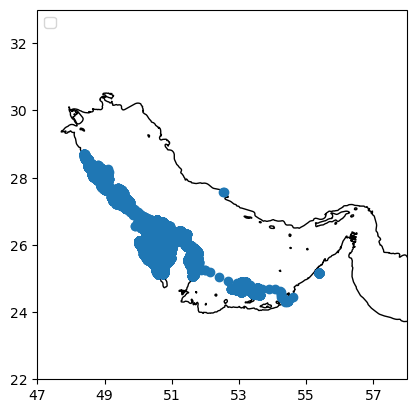

In [8]:
### OLD version
ax = plt.axes(projection=ccrs.PlateCarree())
plt.plot(ds_obs.lon,ds_obs.lat,'o')

ax.coastlines()
ax.set_xlim(47,58)
ax.set_ylim(22,33)
ax.set_xticks(np.arange(47,58,2), crs=ccrs.PlateCarree())
ax.set_yticks(np.arange(22,33,2), crs=ccrs.PlateCarree())
ax.legend(loc = "upper left")

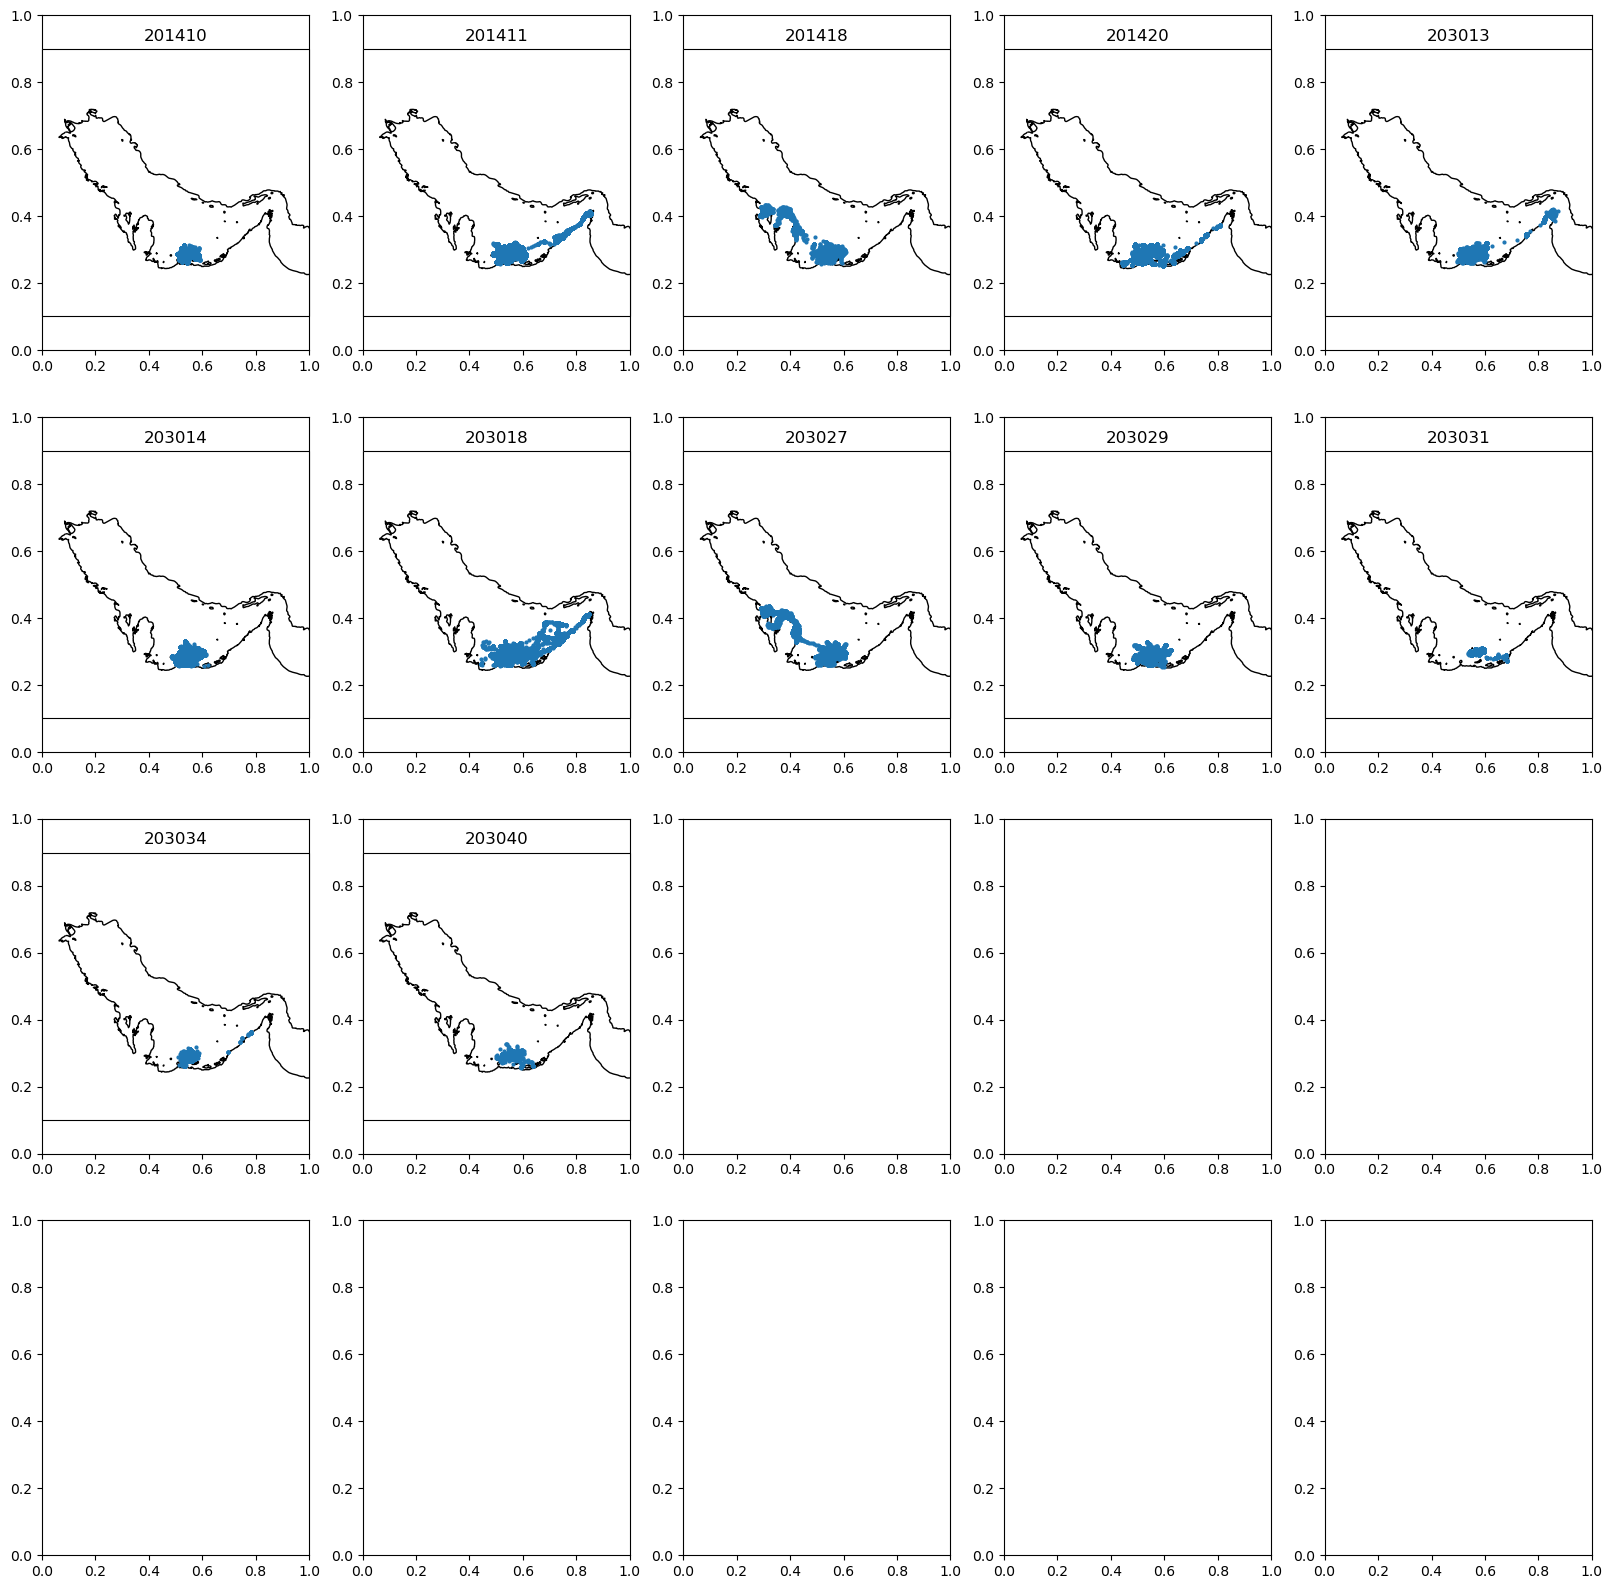

In [258]:
fig,axs = plt.subplots(4,5,figsize=(20,20))
iplt = 0
for i in np.unique(ds_obs.id):
    ax = plt.subplot(4, 5, iplt + 1, projection=ccrs.PlateCarree())
    # ax = plt.axes(projection=ccrs.PlateCarree())
    plt.plot(ds_obs.lon.where(ds_obs.id==i),ds_obs.lat,'o',markersize=2)
    # plt.plot([x_geobox[0],x_geobox[0],x_geobox[1],x_geobox[1],x_geobox[0]],[y_geobox[1],y_geobox[0],y_geobox[0],y_geobox[1],y_geobox[1]])

    ax.coastlines()
    ax.set_xlim(47,58)
    ax.set_ylim(22,33)
    ax.set_title(i)
    iplt += 1
    # ax.set_xlim(x_geobox[0]-0.1,x_geobox[1]+0.1)
    # ax.set_ylim(y_geobox[0]-0.1,y_geobox[1]+0.1)

In [16]:
print( 'tags in the Persian Gulf:' , np.unique(ds_obs.id),len(np.unique(ds_obs.id)))
print( 'tags in the Persian Gulf:' , np.unique(ds_obs.datatype),len(np.unique(ds_obs.datatype)))

tags in the Persian Gulf: [201410 201411 201418 201420 203013 203014 203018 203027 203029 203031
 203034 203040] 12
tags in the Persian Gulf: ['GPS' 'GPSD' 'GPSF' 'GPSS' 'NOTE_DIVING' 'SEND_ALL2_10Hz'
 'SEND_ALL2_10Hz_END' 'SEND_ALL2_10Hz_START' 'SEND_ALL2_10Hz_START_END'
 'SEND_ALL2_1Hz' 'SEND_ALL2_1Hz_END' 'SEND_ALL2_1Hz_START'
 'SEND_ALL2_1Hz_START_END' 'SEN_ACC_5Hz_START_ENDINT' 'SEN_ALL_1Hz'
 'SEN_ALL_1Hz_END' 'SEN_ALL_1Hz_START'] 17


201410
<xarray.DataArray 'time' (t: 293315)>
array(['2020-07-02T01:07:14.000000000', '2020-07-02T01:07:15.000000000',
       '2020-07-02T01:07:49.151000000', ...,
       '2021-07-13T07:39:39.719000000', '2021-07-13T07:59:39.763000000',
       '2021-07-13T08:19:39.793000000'], dtype='datetime64[ns]')
Coordinates:
  * t        (t) datetime64[ns] 2020-07-02T01:07:14 ... 2021-07-13T08:19:39.7...
201411
<xarray.DataArray 'time' (t: 593889)>
array(['2020-07-02T00:33:35.000000000', '2020-07-02T00:33:36.000000000',
       '2020-07-02T00:34:11.427000000', ...,
       '2021-08-14T04:22:22.000000000', '2021-08-14T04:51:17.000000000',
       '2021-08-14T19:26:56.000000000'], dtype='datetime64[ns]')
Coordinates:
  * t        (t) datetime64[ns] 2020-07-02T00:33:35 ... 2021-08-14T19:26:56
201418
<xarray.DataArray 'time' (t: 179776)>
array(['2020-07-02T01:03:44.000000000', '2020-07-02T01:03:45.000000000',
       '2020-07-02T01:03:46.000000000', ...,
       '2023-03-09T04:16:05.000000000', '2023-03-11T

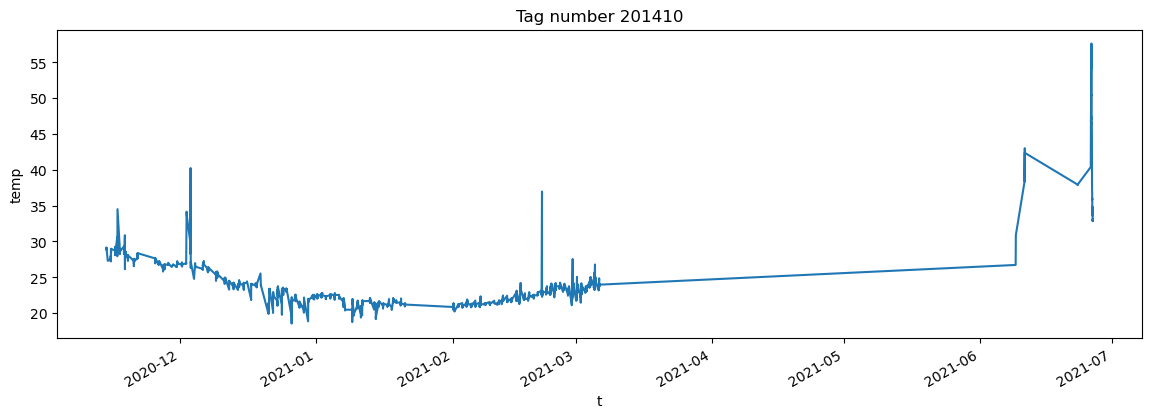

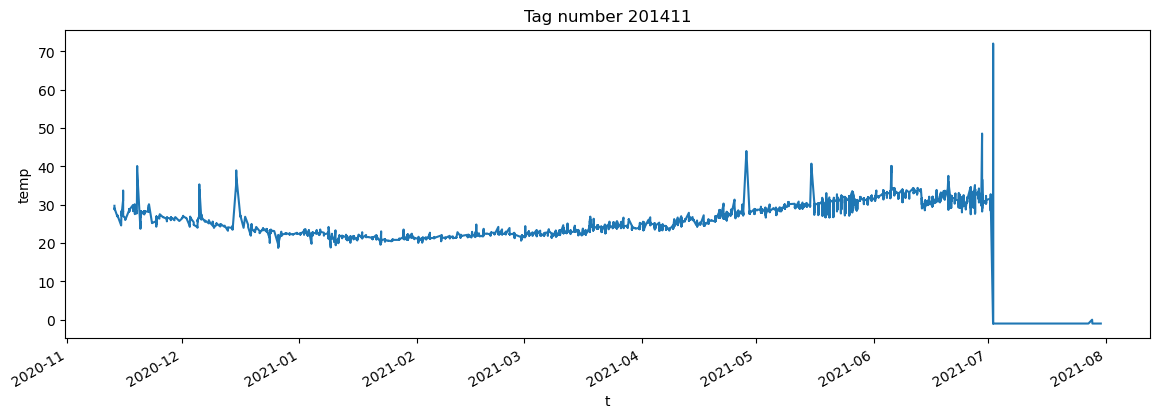

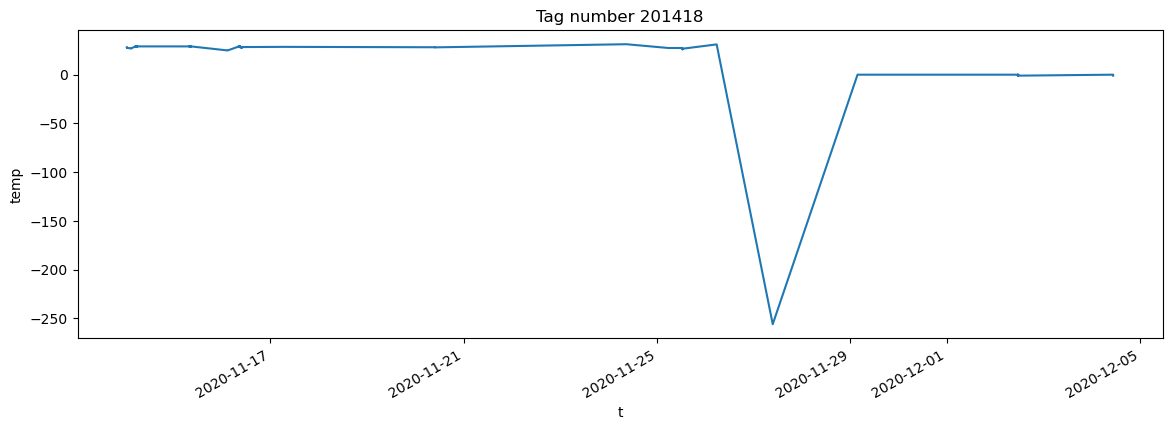

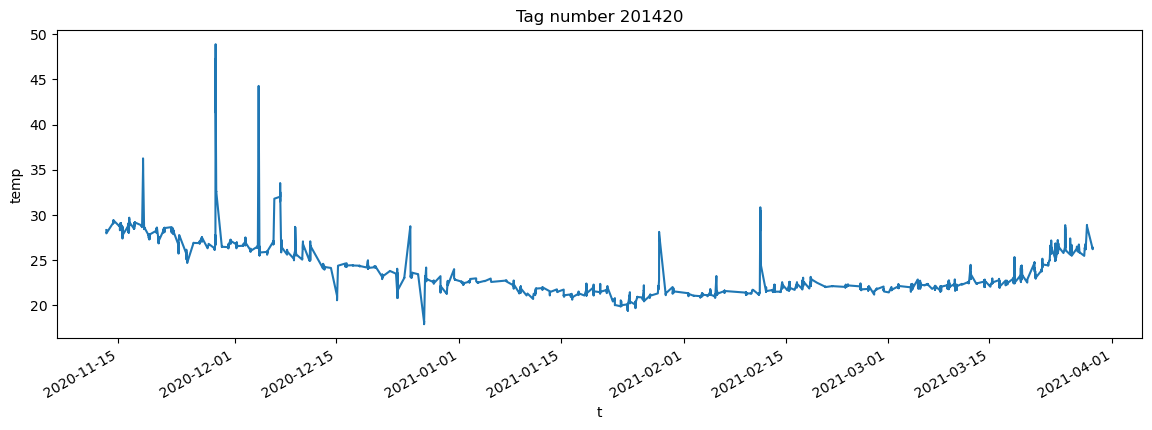

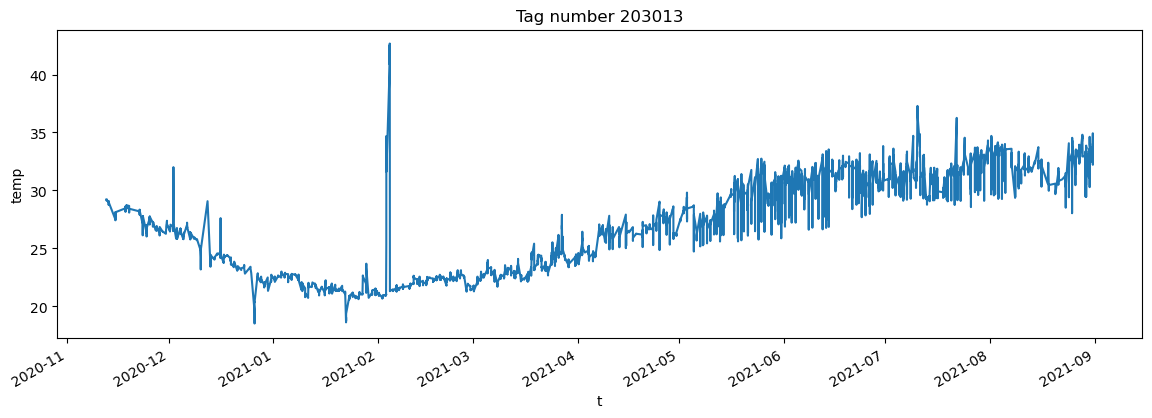

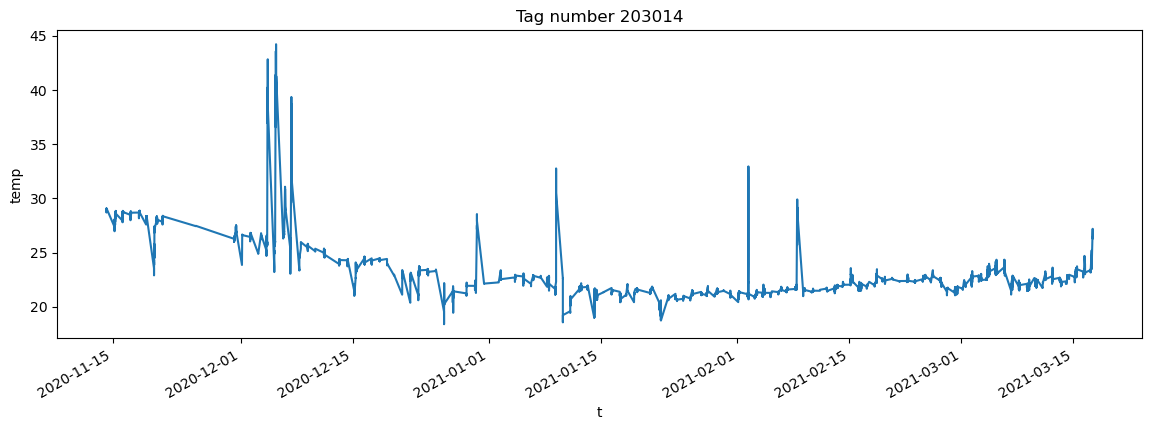

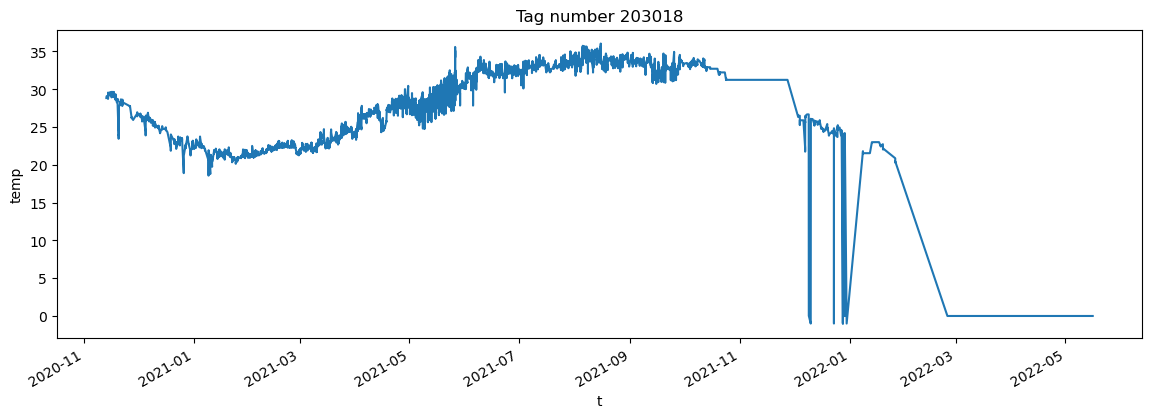

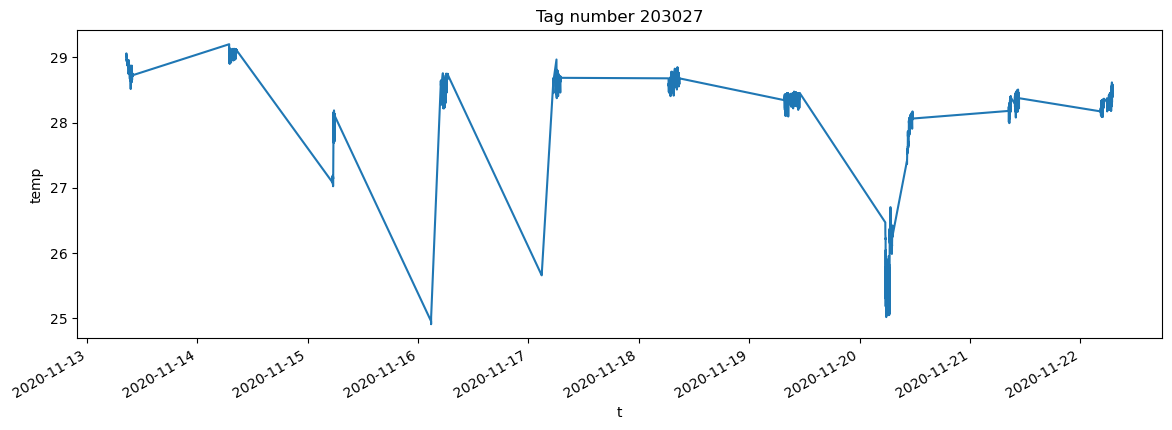

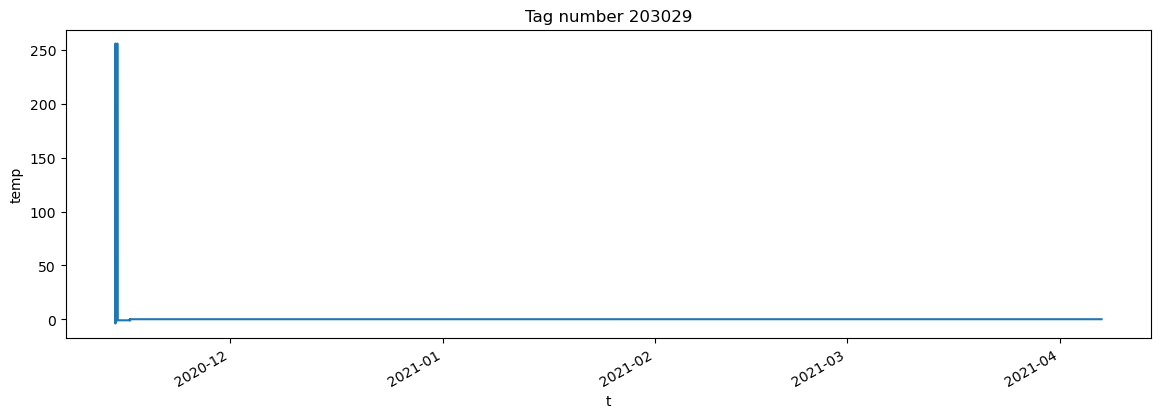

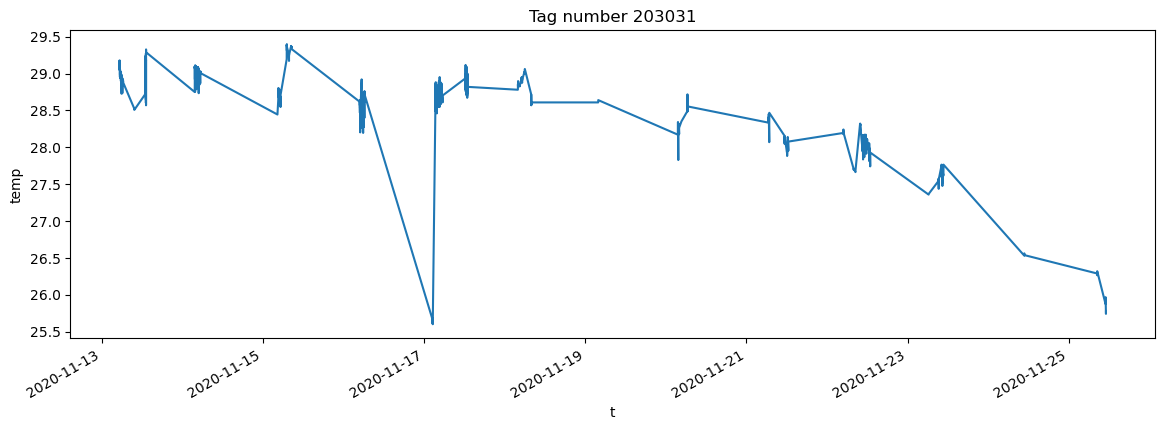

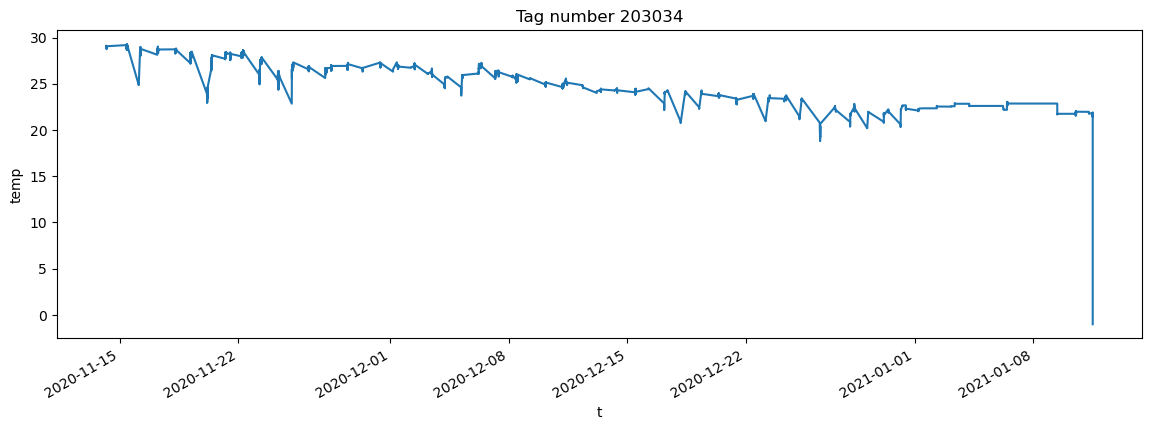

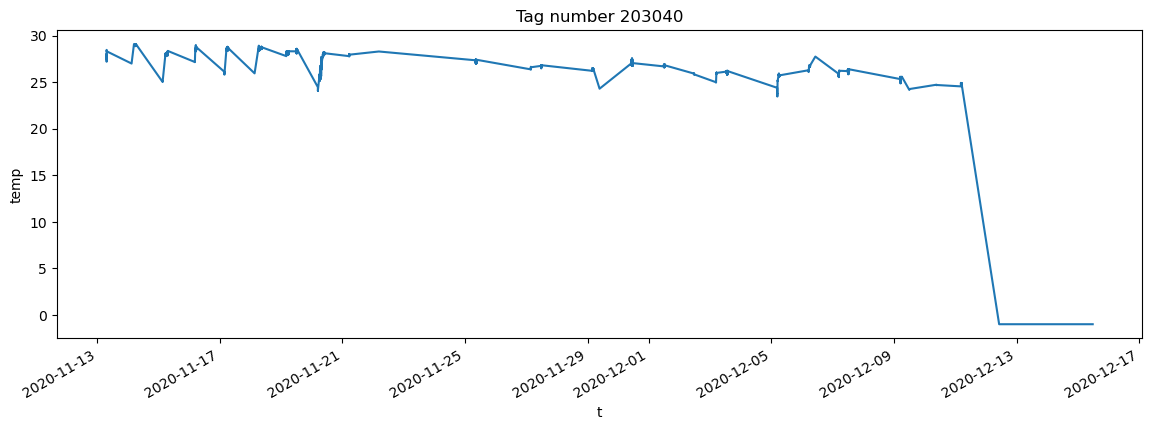

In [17]:
for i in np.unique(ds_obs.id):
    print(i)
    ds_obs_1 = ds_obs.where((ds_obs.id == i),drop=True)
    print(ds_obs_1.time)
    plt.figure(figsize=(14,4))
    ds_obs_1.where(ds_obs_1.datatype=='SEND_ALL2_1Hz',drop=True).temp.plot()
    plt.title(f'Tag number {i}')

    # break

# calculate the total number of SEND_ALL2_1HZ, data for all tags

## Take TAG 237244 as an example

In [54]:
ds_obs_1.isel(time_index=idx[0]).temp_int.values

array(27.)

201410
201411
201418
201420
203013
203014
203018
203027
203029
203031
203034
203040


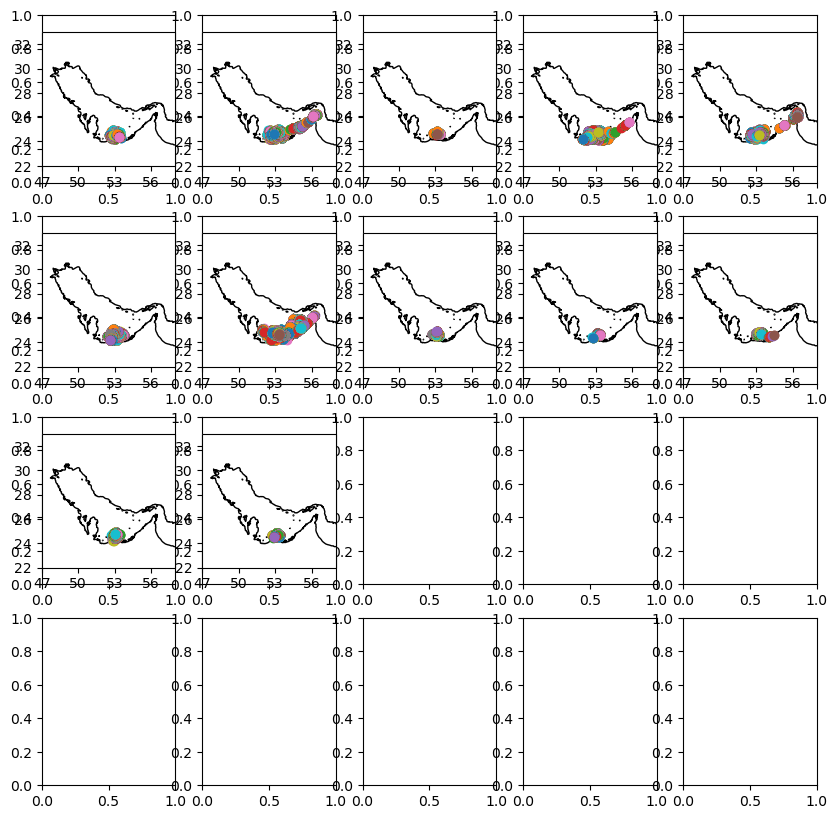

In [366]:
# pick a tag with its id number 191989
# ds_obs_1 is the dataset for the tag 191989

# pd_dive_2 = pd.DataFrame(columns=['ik', 'temp0', 'temp1', 'rec_len','first_record','last_record'])
ds_dive_2 = xr.Dataset(
    {
        'tag_id': ('dive_index', np.array([])),
        'temp1': ('dive_index', np.array([])),
        'temp0': ('dive_index', np.array([])),
        'temp_int1': ('dive_index', np.array([])),
        'temp_int0': ('dive_index', np.array([])),
        'rec_len': ('dive_index', np.array([])),
        'first_record': ('dive_index', np.array([])),
        'last_record': ('dive_index', np.array([])),
        'depth_max': ('dive_index', np.array([])),
    },
    coords={'dive_index': np.array([])}
)

fig,axs = plt.subplots(4,5,figsize=(10,10))
iplt = 0
for idn in np.unique(ds_obs.id):
    print(idn)
    # create ds_obs_1 for one tag
    ds_obs_1 = ds_obs.where((ds_obs.id == idn),drop=True)
    # Create a new integer coordinate
    new_t = np.arange(len(ds_obs_1['t']))

    # Optionally, store the original time as a data variable for reference
    ds_obs_1 = ds_obs_1.assign(original_time=('time_index', ds_obs_1['t'].values))

    # Assign the new integer coordinate while keeping the original as a variable
    ds_obs_1 = ds_obs_1.assign_coords(t=new_t).rename({'t': 'time_index'})

    # assign a new variable 'mask' (with NaNs)
    ds_obs_1 = ds_obs_1.assign(mask=(('time_index',), np.full(ds_obs_1.dims['time_index'], np.nan)))

    # Find the indices where 'datatype' is 'GPS'
    # list the "indices" where the difference between two consecutive indices is greater than 10
    # assign a new mask for each of these indices

    gps_indices = ds_obs_1.time_index.where((ds_obs_1.datatype == 'GPS')|(ds_obs_1.datatype == 'GPSS')|(ds_obs_1.datatype == 'GPSD'), drop=True).values.astype(int)

    indices = [(i, j, j-i) for i, j in zip(gps_indices[:-1], gps_indices[1:]) if j - i > 10]
    imask = 0
    for idx in indices:
        # print(idx)
        ds_obs_1['mask'].loc[dict(time_index=slice(idx[0], idx[1]))] = imask
        imask = imask+1
    
    # for each chunk between two GPS records, find the indices where the datatype is 'SEND_ALL2_1Hz'
    imask = 0


    # Define indices_inbox list
    ds_obs_1['mask2'] = xr.DataArray(np.zeros(ds_obs_1.dims['time_index']), dims='time_index')
    ds_obs_1['lon_bef'] = xr.DataArray(np.zeros(ds_obs_1.dims['time_index']), dims='time_index')
    ds_obs_1['lat_bef'] = xr.DataArray(np.zeros(ds_obs_1.dims['time_index']), dims='time_index')
    ds_obs_1['lon_end'] = xr.DataArray(np.zeros(ds_obs_1.dims['time_index']), dims='time_index')
    ds_obs_1['lat_end'] = xr.DataArray(np.zeros(ds_obs_1.dims['time_index']), dims='time_index')
    ds_obs_1['temp_int_bef'] = xr.DataArray(np.zeros(ds_obs_1.dims['time_index']), dims='time_index')
    ds_obs_1['temp_int_end'] = xr.DataArray(np.zeros(ds_obs_1.dims['time_index']), dims='time_index')

    ax = plt.subplot(4, 5, iplt + 1, projection=ccrs.PlateCarree())
    # first find the indices whose GPS location is in the box
    for idx in indices:
        p1 = ds_obs_1.isel(time_index=idx[0])
        p2 = ds_obs_1.isel(time_index=idx[1])

        if 'SEND_ALL2_1Hz' in ds_obs_1.datatype.isel(time_index=slice(idx[0], idx[1])).values:
            # Find pairs of 'SEND_ALL2_1Hz_START' and 'SEND_ALL2_1Hz_END' in ds_obs_1.datatype.isel(time_index=slice(idx[0], idx[1]))
            start_indices = ds_obs_1.time_index.where(ds_obs_1.datatype.isel(time_index=slice(idx[0], idx[1])) == 'SEND_ALL2_1Hz_START', drop=True).values.astype(int)
            end_indices = ds_obs_1.time_index.where(ds_obs_1.datatype.isel(time_index=slice(idx[0], idx[1])) == 'SEND_ALL2_1Hz_END', drop=True).values.astype(int)
            
            # Ensure that each start has a corresponding end
            for start, end in zip(start_indices, end_indices):
                if start < end:
                    ds_obs_1['mask2'].loc[dict(time_index=slice(start, end))] = imask
                    ds_obs_1['lon_bef'].loc[dict(time_index=slice(start, end))] = p1.lon.values
                    ds_obs_1['lat_bef'].loc[dict(time_index=slice(start, end))] = p1.lat.values
                    ds_obs_1['lon_end'].loc[dict(time_index=slice(start, end))] = p2.lon.values
                    ds_obs_1['lat_end'].loc[dict(time_index=slice(start, end))] = p2.lat.values
                    ds_obs_1['temp_int_bef'].loc[dict(time_index=slice(start, end))] = p1.temp_int.values
                    ds_obs_1['temp_int_end'].loc[dict(time_index=slice(start, end))] = p2.temp_int.values
                    dnmax = np.max(ds_obs_1['depth'].loc[dict(time_index=slice(start, end))].values)
                    new_data = xr.Dataset(
                        {
                            'temp1': ('dive_index', [ds_obs_1.temp.isel(time_index=end).values]),
                            'temp0': ('dive_index', [ds_obs_1.temp.isel(time_index=start).values]),
                            'temp_int1': ('dive_index', [ds_obs_1.temp_int_end.isel(time_index=end).values]),
                            'temp_int0': ('dive_index', [ds_obs_1.temp_int_bef.isel(time_index=start).values]),
                            'rec_len': ('dive_index', [(end-start).astype(float)]),
                            'first_record': ('dive_index', [start]),
                            'lon': ('dive_index', [ds_obs_1.lon_end.isel(time_index=end).values]),
                            'lat': ('dive_index', [ds_obs_1.lat_end.isel(time_index=end).values]),
                            'time': ('dive_index', [ds_obs_1.original_time.isel(time_index=end).values]),
                            'last_record': ('dive_index', [end]),
                            'tag_id': ('dive_index', [idn]),
                            'depth_max': ('dive_index', [dnmax]),
                        },
                        coords={'dive_index': [imask]}
                    )
            
                    # Concatenate with existing dataset
                    ds_dive_2 = xr.concat([ds_dive_2, new_data], dim='dive_index')   
                    imask += 1

                    plt.plot([p1.lon.values,p2.lon.values], [p1.lat.values,p2.lat.values],'o')
    ax.coastlines()
    ax.set_xlim(47,58)
    ax.set_ylim(22,33)
    ax.set_xticks(np.arange(47,58,3), crs=ccrs.PlateCarree())
    ax.set_yticks(np.arange(22,33,2), crs=ccrs.PlateCarree())
    # ax.legend(loc = "upper left")
    iplt += 1


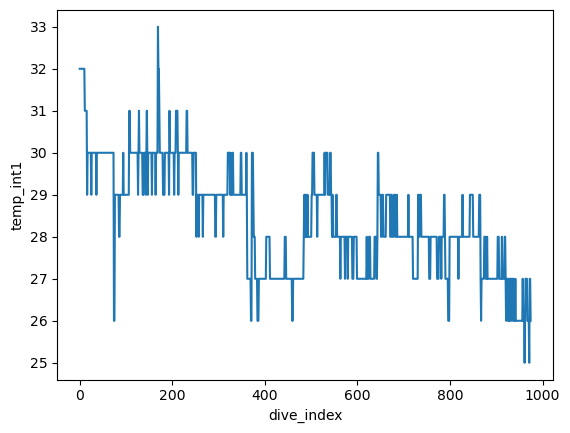

In [68]:
ds_dive_2.where(ds_dive_2.tag_id==203040,drop=True).temp_int1.plot()

1000000000 nanoseconds
39.0
1000000000 nanoseconds
52.0
1000000000 nanoseconds
36.0
1000000000 nanoseconds
39.0
1000000000 nanoseconds
43.0
1000000000 nanoseconds
30.0
1000000000 nanoseconds
51.0
1000000000 nanoseconds
36.0
1000000000 nanoseconds
34.0
1000000000 nanoseconds
39.0
1000000000 nanoseconds
41.0
1000000000 nanoseconds
40.0
1000000000 nanoseconds
46.0
1000000000 nanoseconds
45.0
1000000000 nanoseconds
40.0
1000000000 nanoseconds
48.0
1000000000 nanoseconds
38.0
1000000000 nanoseconds
38.0


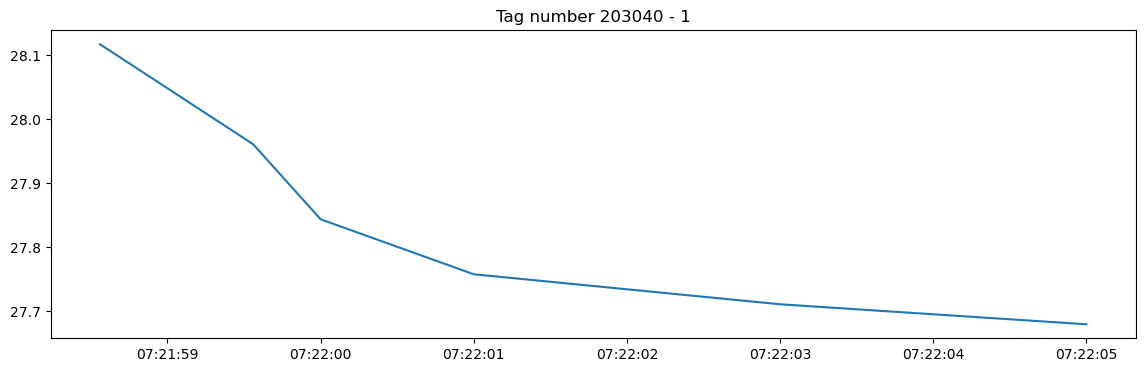

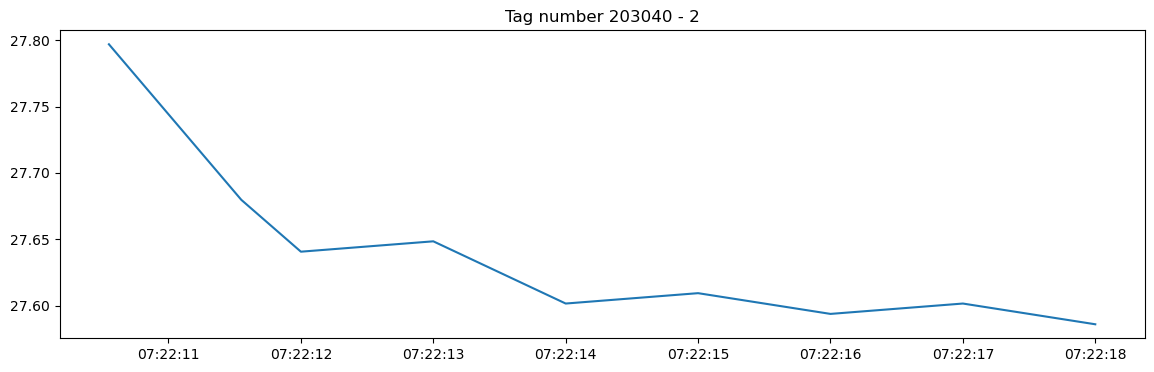

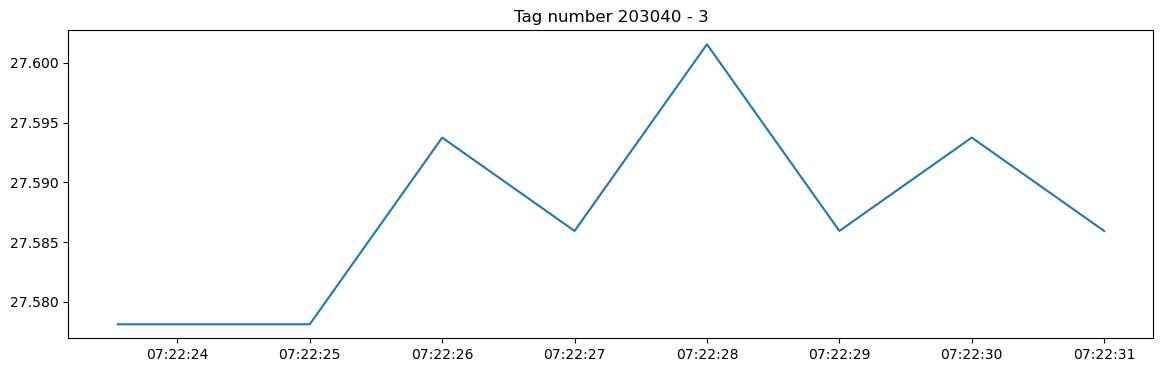

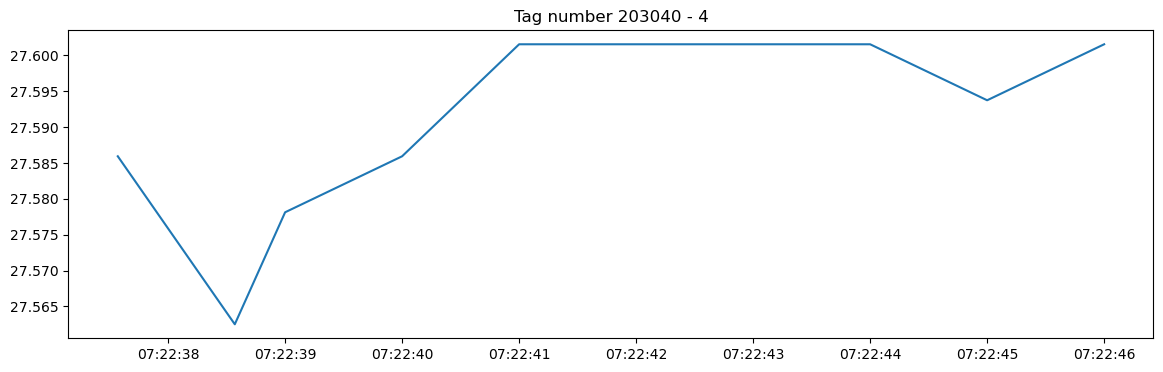

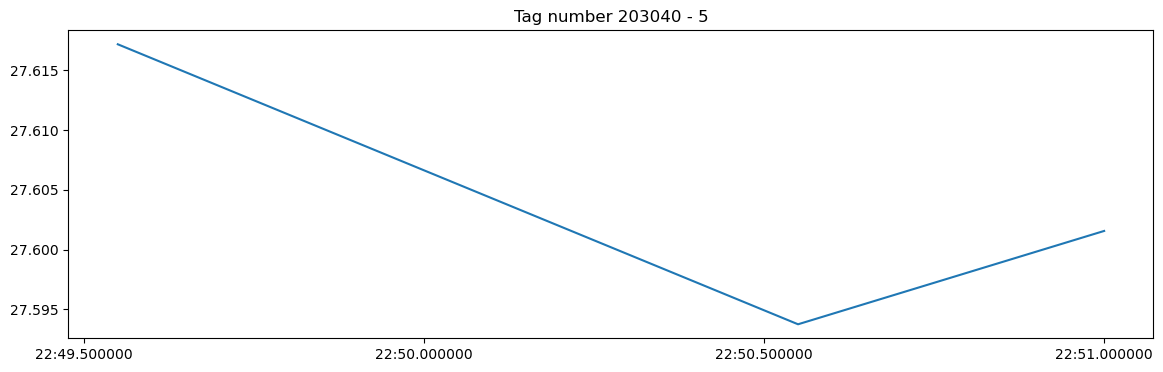

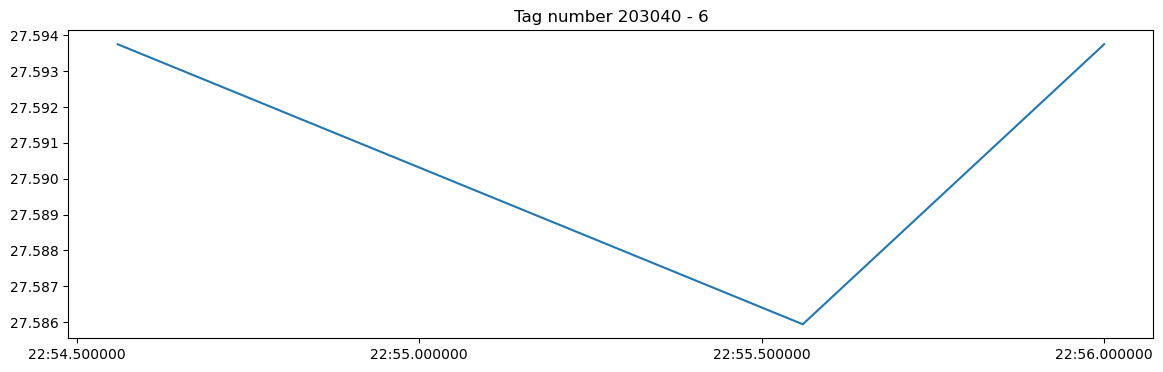

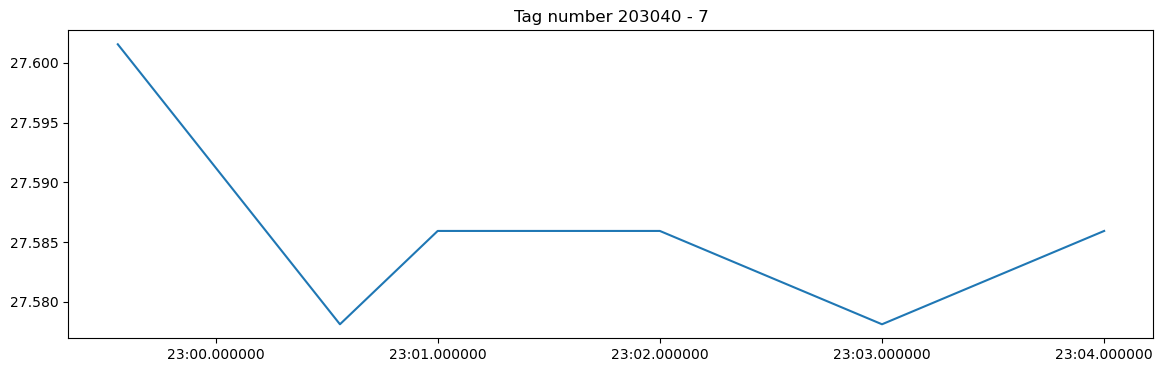

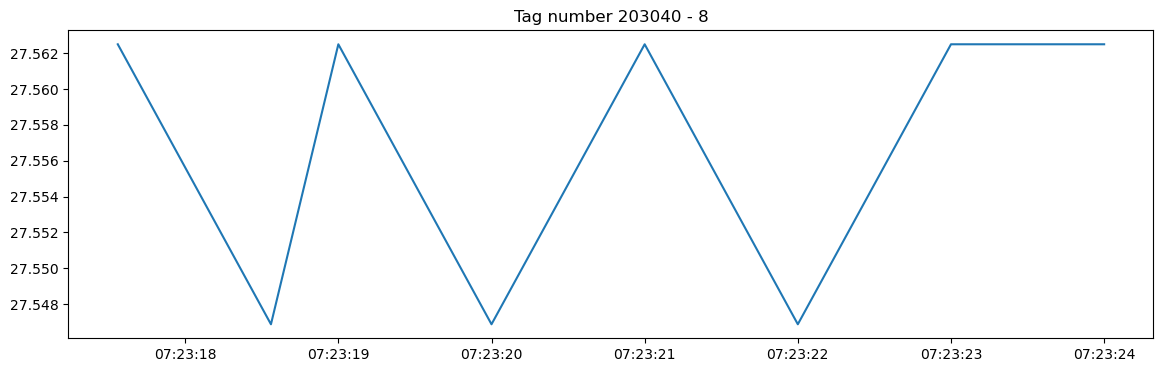

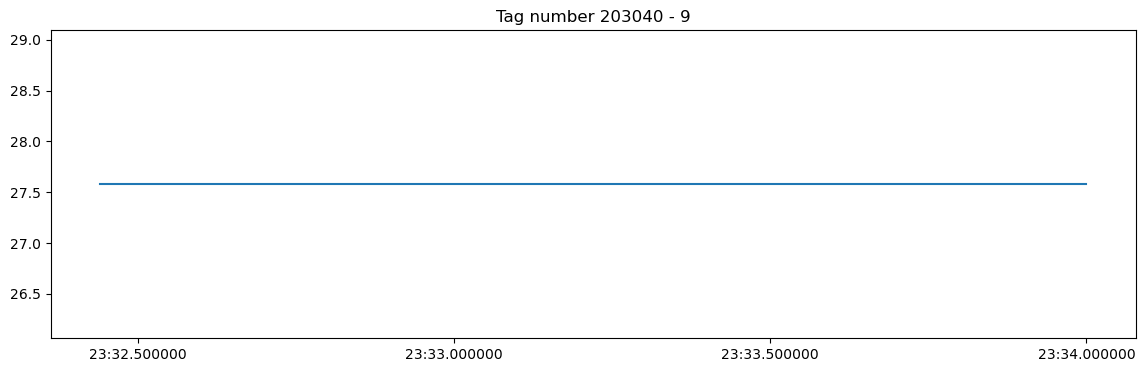

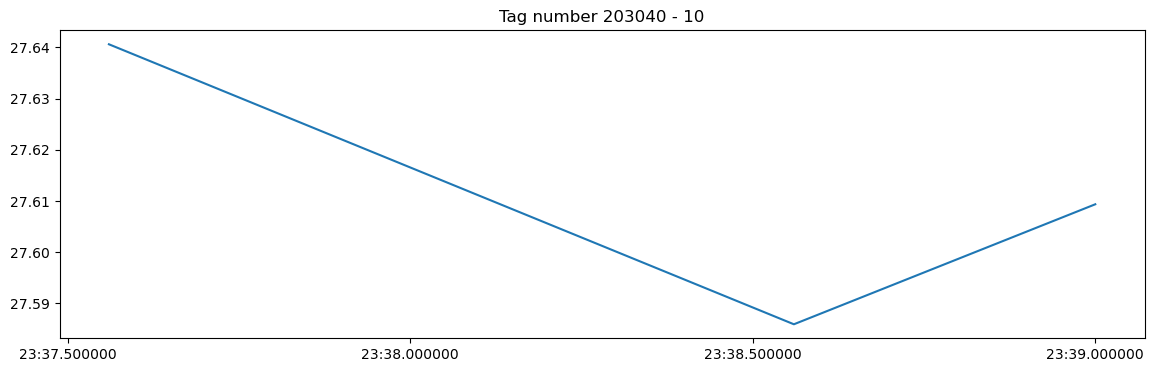

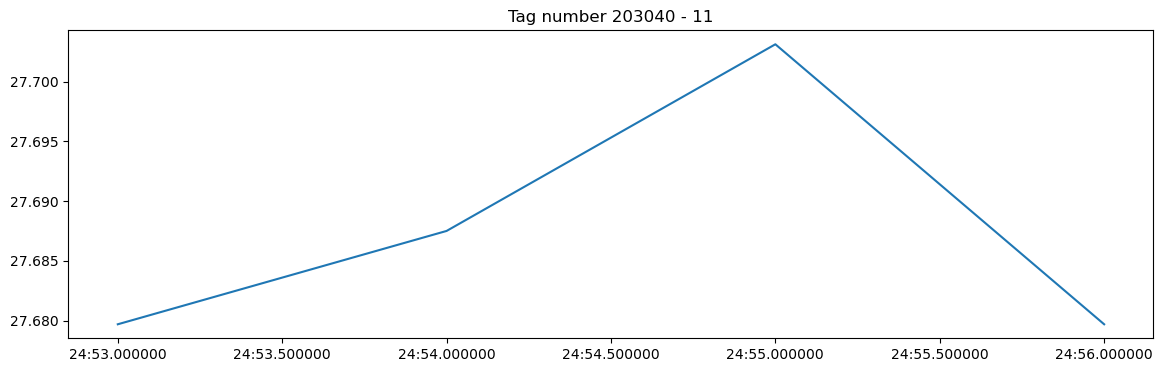

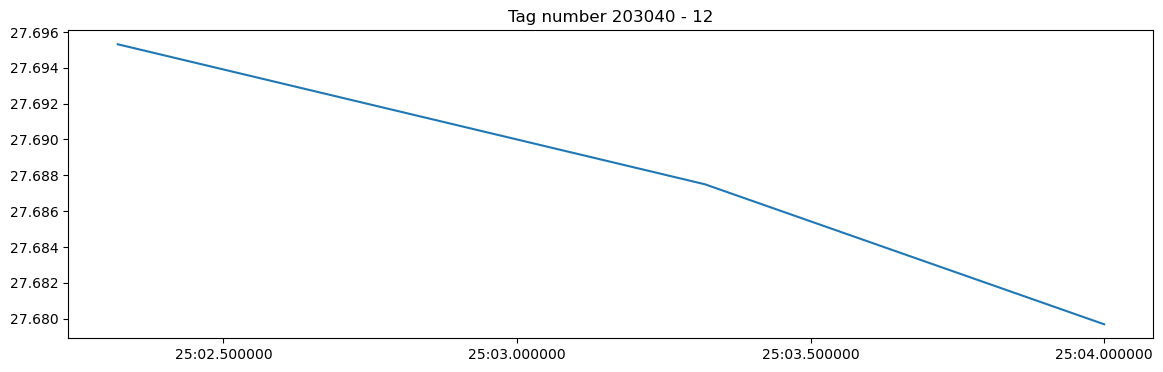

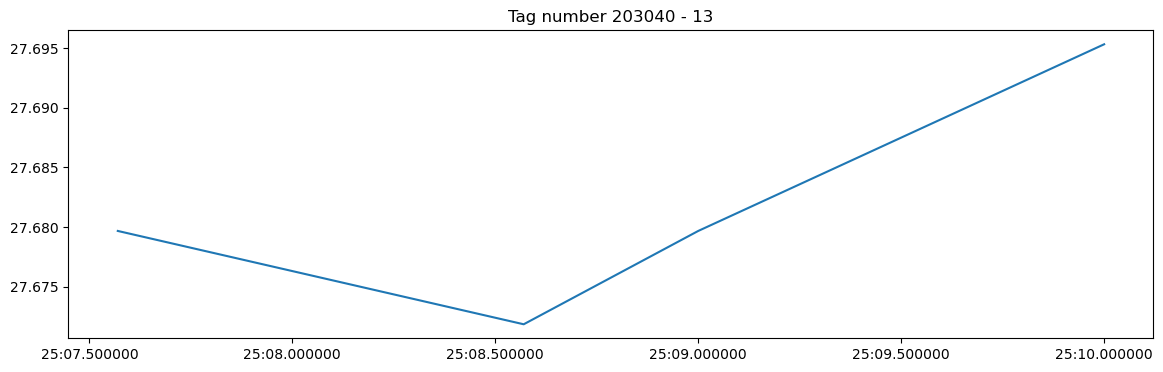

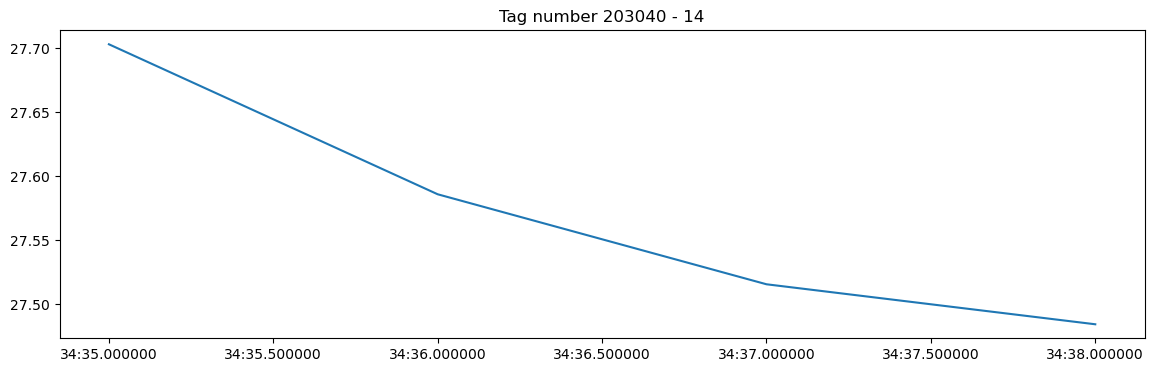

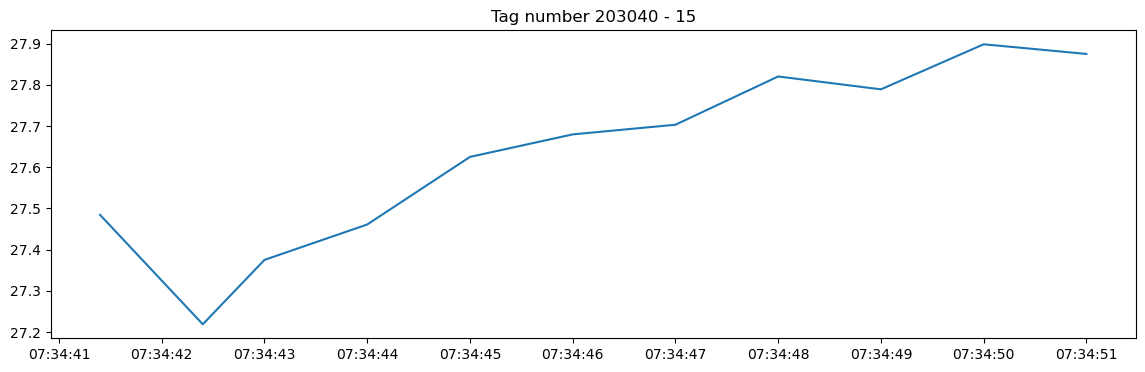

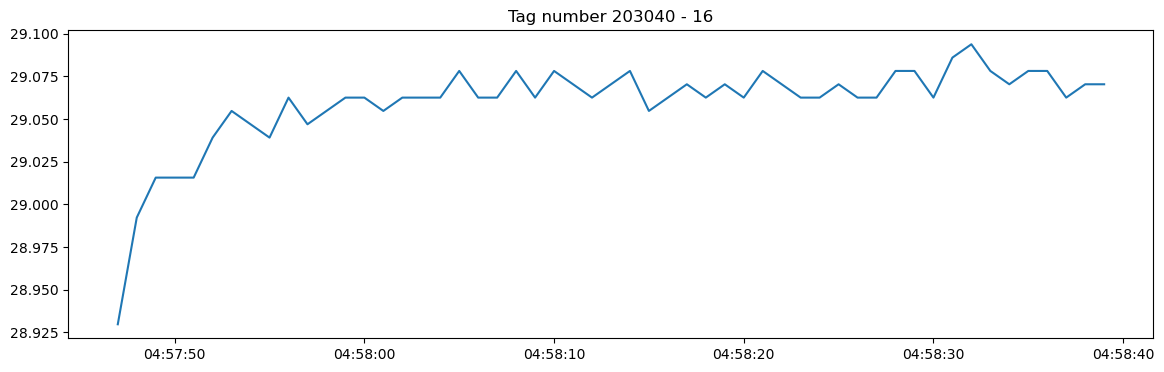

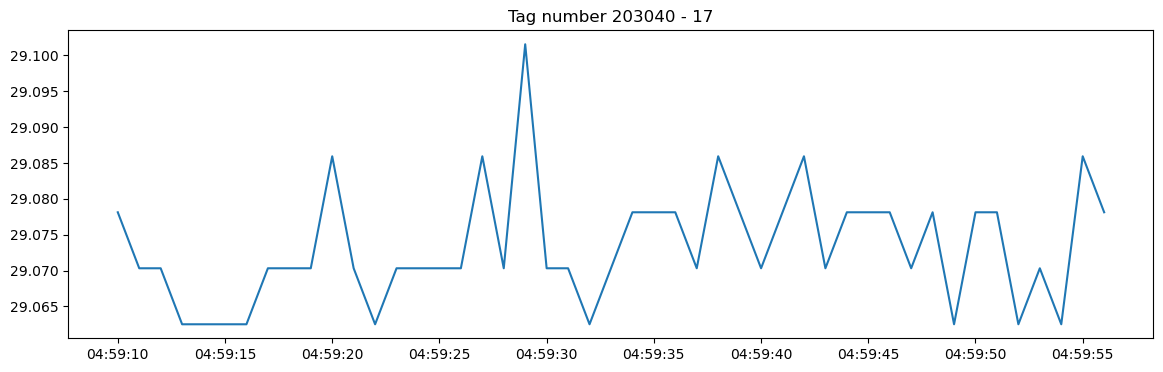

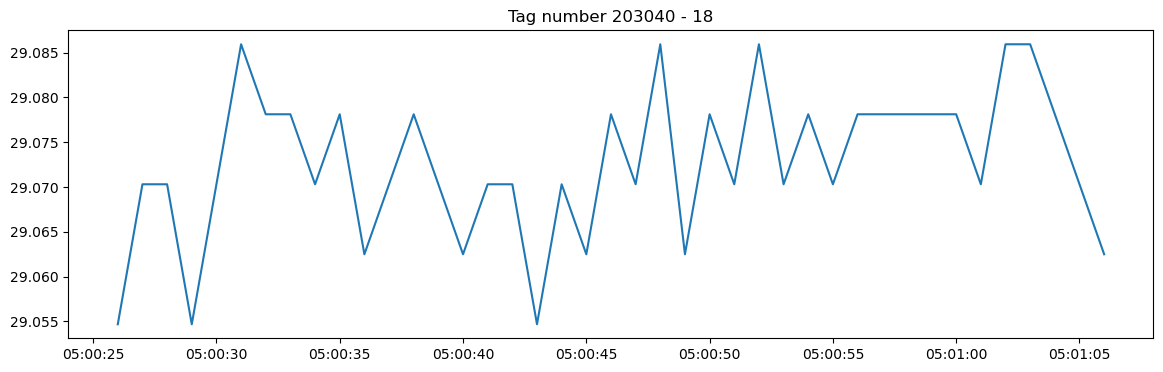

In [15]:
for ik in range(18):
    plt.figure(figsize=(14,4))
    plt.plot(ds_obs_1.where(ds_obs_1.mask2==ik+1,drop=True).original_time,ds_obs_1.where(ds_obs_1.mask2==ik+1,drop=True).temp)
    # plt.plot(ds_obs_1.where(ds_obs_1.mask2==ik+1,drop=True).original_time,ds_obs_1.where(ds_obs_1.mask2==ik+1,drop=True).depth)
    plt.title(f'Tag number {idn} - {ik+1}')
    print(np.max(np.diff(ds_obs_1.where(ds_obs_1.mask2==ik+1,drop=True).time)))
    print(ds_dive_2.isel(dive_index=ik).rec_len.values)

[2.39 3.55 4.61 5.73 6.42 7.2  7.82 8.17 8.41 8.47 8.5  8.44 8.44 8.44
 8.44 8.47 8.44 8.35 8.2  8.2  8.23 8.29 8.47 8.44 8.38 8.41 8.41 8.47
 8.47 8.5  8.44 8.23 8.38 8.17 7.32 5.92 4.39 2.8  1.18 0.  ] 8.5
26.0
40
[2.42 3.67 5.05 6.11 6.88 7.6  8.13 8.2  8.47 8.35 8.17 8.47 8.53 8.5
 8.53 8.5  8.47 8.5  8.53 8.53 8.6  8.5  8.5  8.5  8.47 8.5  8.47 8.41
 8.5  8.5  8.53 8.53 8.53 8.41 8.29 8.41 8.35 8.29 8.29 8.38 8.5  8.47
 8.44 8.47 8.44 8.38 8.26 7.82 7.1  6.11 4.73 3.33 1.92 0.33] 8.6
40.0
54
[3.27 4.36 5.42 6.29 7.26 8.04 8.5  8.57 8.73 8.67 8.57 8.67 8.7  8.73
 8.73 8.7  8.7  8.7  8.7  8.7  8.63 8.67 8.67 8.7  8.73 8.67 8.7  8.76
 8.67 8.67 8.67 8.67 8.63 8.63 8.63 8.63 8.63 8.63 8.63 8.67 8.67 8.56
 8.63 8.6  8.53 8.56 8.6  8.5  8.6  8.5  8.44 8.35 7.79 6.98 5.98 4.92
 3.67 2.21 0.65] 8.76
45.0
59
[3.27 4.51 5.54 6.35 7.01 7.64 8.13 8.41 8.47 8.44 8.38 8.38 8.41 8.38
 8.44 8.38 8.35 8.35 8.35 8.32 8.35 8.41 8.29 8.35 8.41 8.35 8.41 8.38
 8.38 8.35 8.32 8.35 8.41 8.38 8.38 8.38 8

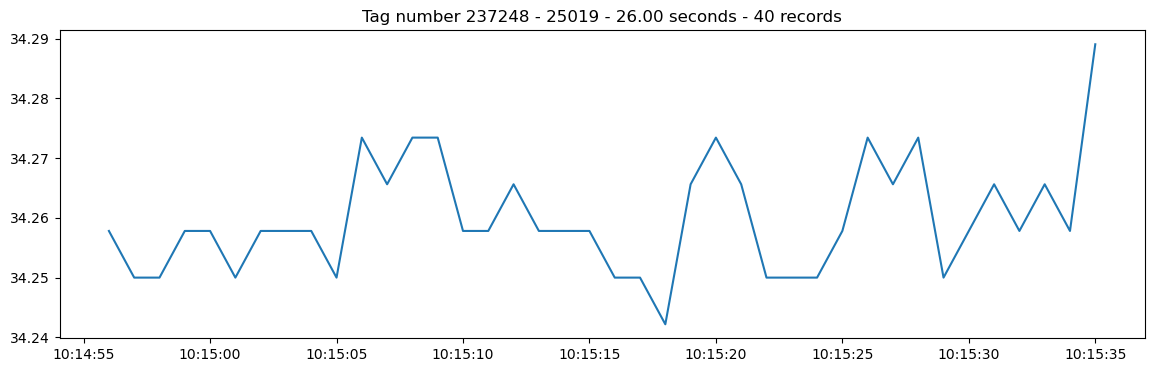

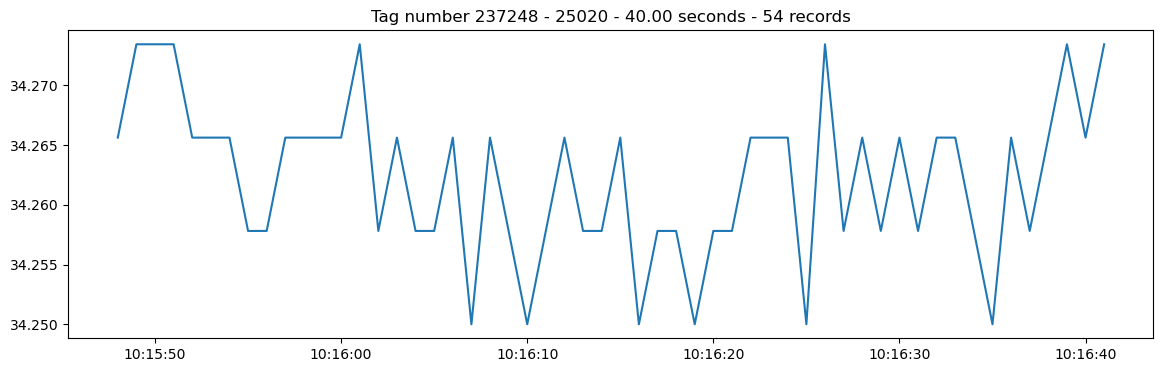

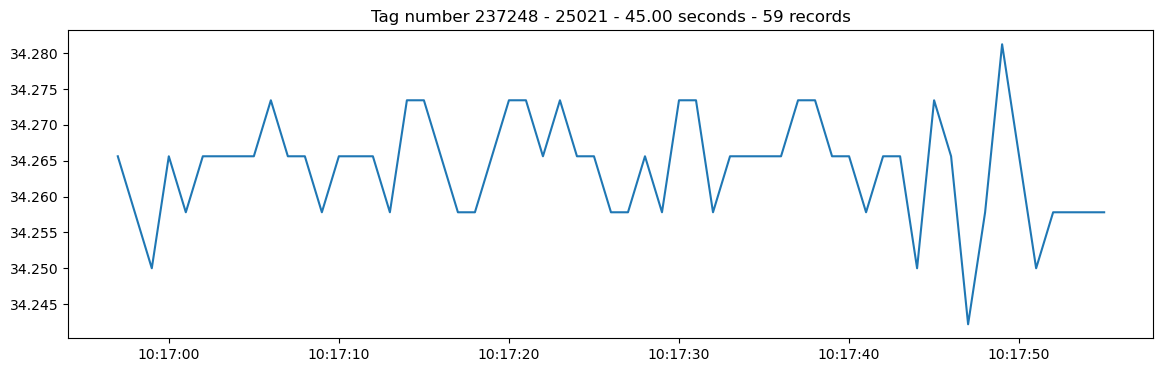

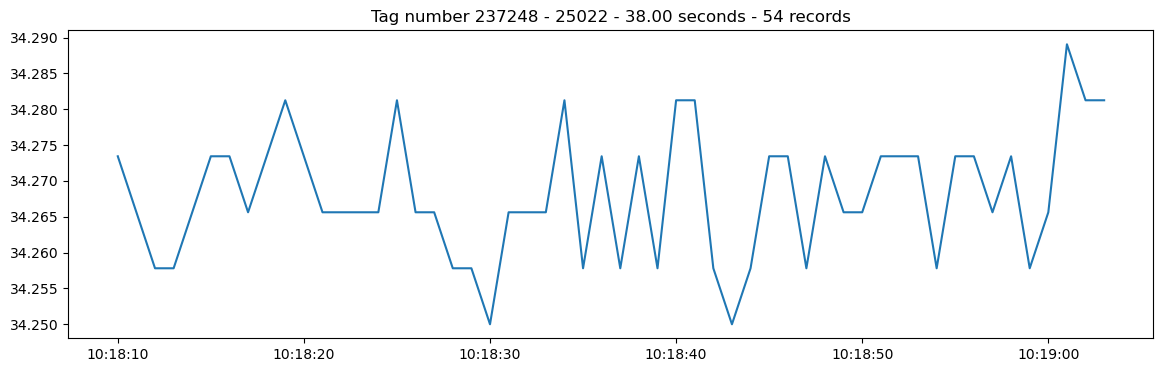

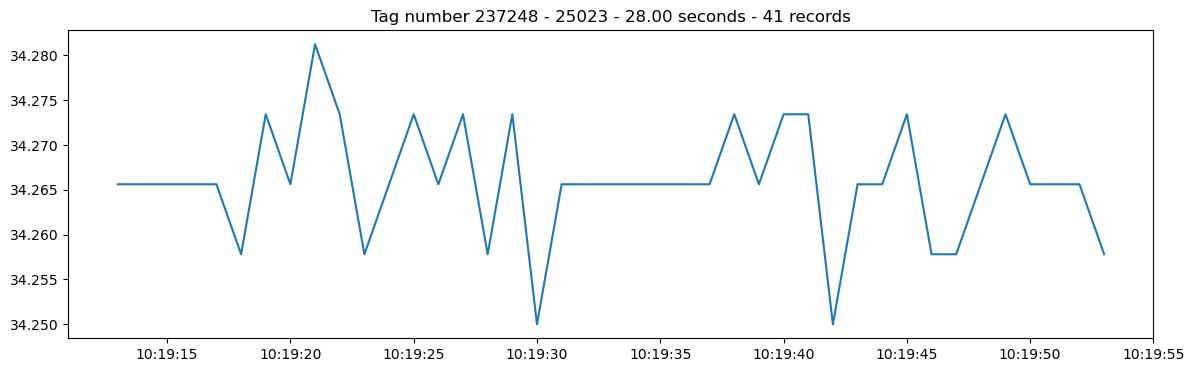

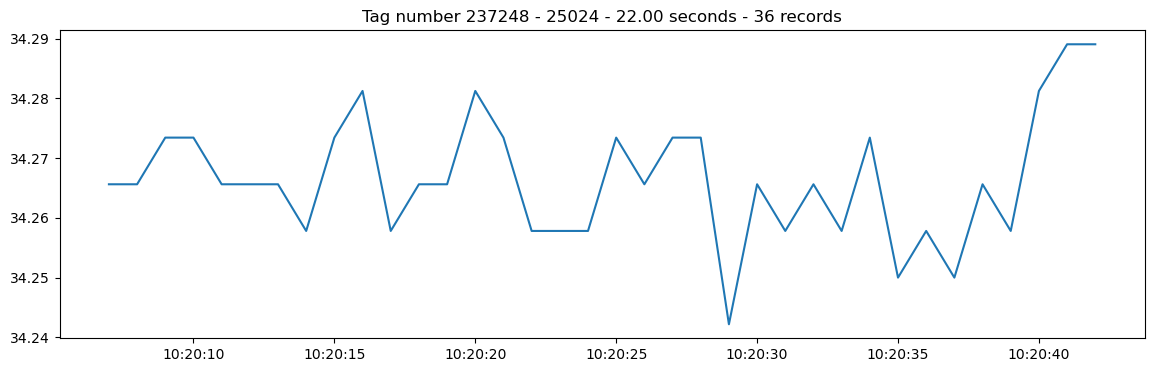

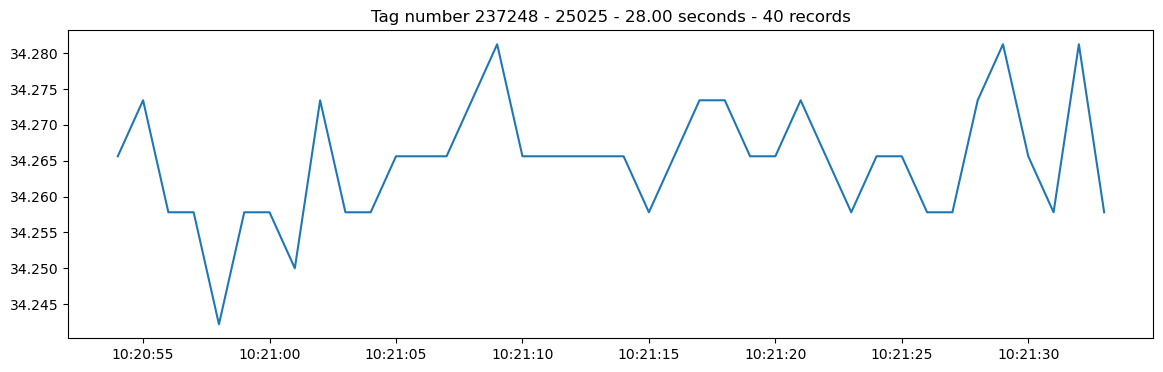

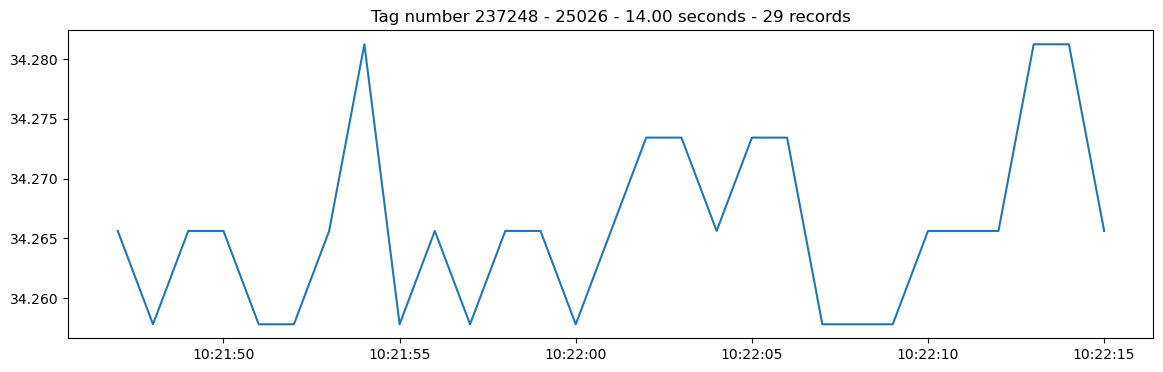

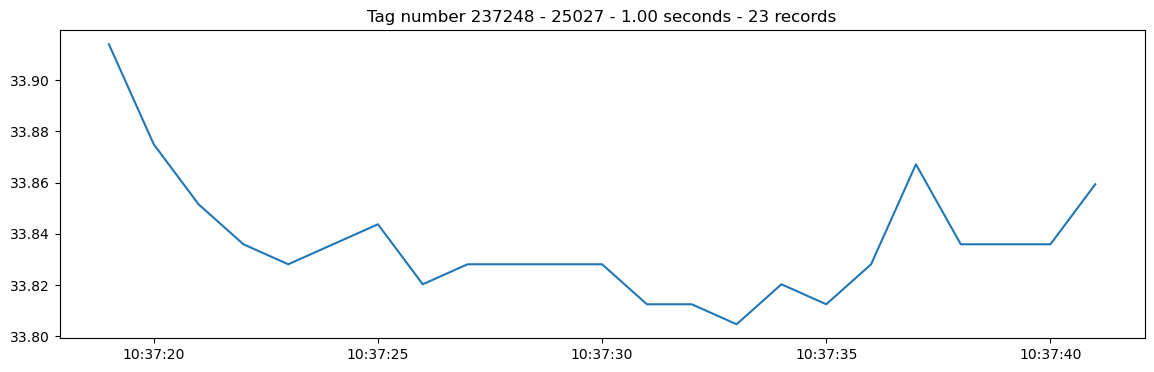

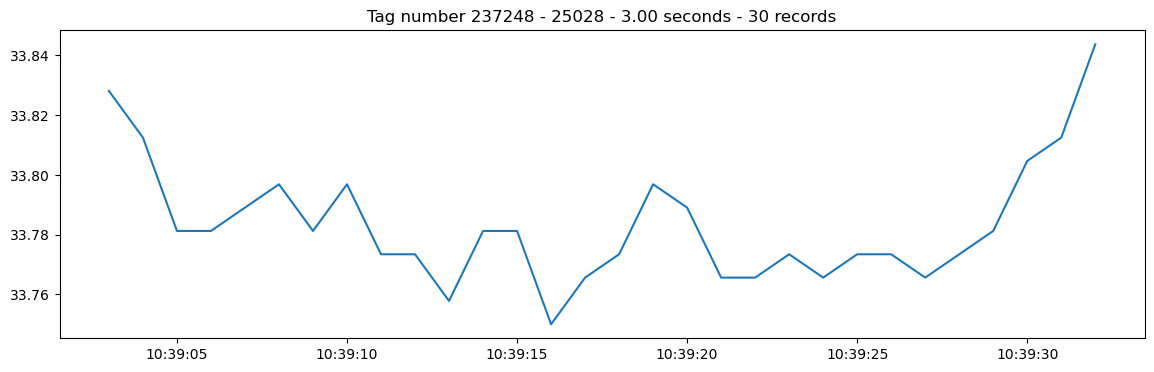

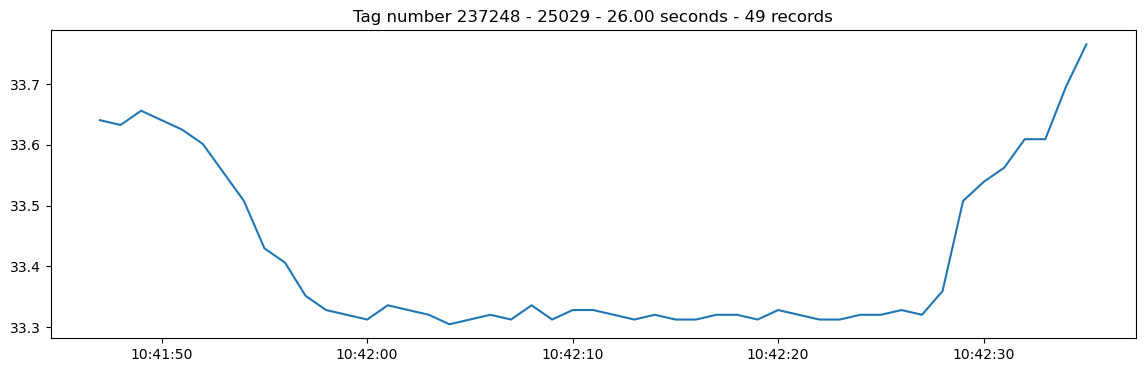

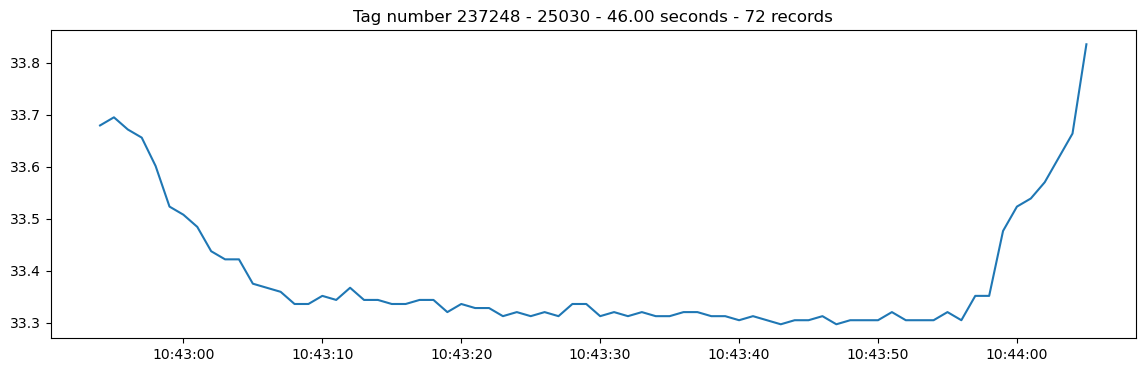

In [ ]:
# # Initialize the new variables in ds_obs_1
# ds_obs_1['first_record'] = xr.DataArray(np.full(ds_obs_1.dims['time_index'], np.nan), dims='time_index')
# ds_obs_1['last_record'] = xr.DataArray(np.full(ds_obs_1.dims['time_index'], np.nan), dims='time_index')
# ds_obs_1['dtb'] = xr.DataArray(np.full(ds_obs_1.dims['time_index'], np.nan), dims='time_index')

# for ik in range(25018,25030):
#     plt.figure(figsize=(14,4))
#     # plt.plot(ds_obs_1.where(ds_obs_1.mask2==ik+1,drop=True).original_time,ds_obs_1.where(ds_obs_1.mask2==ik+1,drop=True).temp)
#     profile0 = ds_obs_1.where(ds_obs_1.mask2==ik+1,drop=True)
#     dd = profile0.depth
#     dnmax = np.max(dd)
#     print(dd.values,dnmax.values)
#     nn = len(dd[dd - dnmax <= 0.5])
#     first_record = dd[abs(dd - dnmax)<=0.5].time_index.values[0]
#     last_record = dd[abs(dd - dnmax) <= 0.5].time_index.values[-1]
#     dtb = profile0.original_time.sel(time_index=last_record) - profile0.original_time.sel(time_index=first_record)
#     dtb_seconds = dtb.values/np.timedelta64(1, 's')
#     print(dtb_seconds)
#     print(nn)
#     plt.plot(ds_obs_1.where(ds_obs_1.mask2==ik+1,drop=True).original_time,ds_obs_1.where(ds_obs_1.mask2==ik+1,drop=True).temp)
#     plt.title(f'Tag number {idn} - {ik+1} - {dtb_seconds:.2f} seconds - {nn} records')
#     ds_obs_1['first_record'] = xr.where(ds_obs_1.mask2 == ik+1, first_record, ds_obs_1.first_record)
#     ds_obs_1['last_record'] = xr.where(ds_obs_1.mask2 == ik+1, last_record, ds_obs_1.last_record)
#     ds_obs_1['dtb'] = xr.where(ds_obs_1.mask2 == ik+1, dtb_seconds, ds_obs_1.dtb)

# 1. Find the bottom dives / max depth / duration of dives

In [ ]:
# Initialize the new variables in ds_obs_1
# ds_obs_1['first_record'] = xr.DataArray(np.full(ds_obs_1.dims['time_index'], np.nan), dims='time_index')
# ds_obs_1['last_record'] = xr.DataArray(np.full(ds_obs_1.dims['time_index'], np.nan), dims='time_index')
# ds_obs_1['dtb'] = xr.DataArray(np.full(ds_obs_1.dims['time_index'], np.nan), dims='time_index')

# Create an empty pandas DataFrame to store the results
# pd_dive = pd.DataFrame(columns=['ik', 'first_record', 'last_record', 'dtb', 'dmax','T_surf','T_bot'])
ds_dive = xr.Dataset(
    {
        'tag_id': ('dive_index', np.array([])),
        'temp1': ('dive_index', np.array([])),
        'temp0': ('dive_index', np.array([])),
        # 'temp_int1': ('dive_index', np.array([])),
        # 'temp_int0': ('dive_index', np.array([])),
        'rec_len_bot': ('dive_index', np.array([])),
        'depth_max': ('dive_index', np.array([])),
        'first_record': ('dive_index', np.array([])),
        'last_record': ('dive_index', np.array([]))
    },
    coords={'dive_index': np.array([])}
)

for ik in np.unique(ds_obs_1.mask2)[1:]:  ### omit 0_start from 1 ___
# for ik in range(30):
    if ik % 100 == 0:
        print(f'Processing mask2 value: {ik}')
    # plt.figure(figsize=(14,4))
    # plt.plot(ds_obs_1.where(ds_obs_1.mask2==ik+1,drop=True).original_time,ds_obs_1.where(ds_obs_1.mask2==ik+1,drop=True).temp)
    profile0 = ds_obs_1.where(ds_obs_1.mask2==ik,drop=True)
    dd = profile0.depth
    dnmax = np.max(dd).values
    # print(dd.values,dnmax.values)
    nn = len(dd[dd - dnmax <= 0.5])
    first_record = dd[abs(dd - dnmax)<=0.5].time_index.values[0]
    last_record = dd[abs(dd - dnmax) <= 0.5].time_index.values[-1]
    # dtb = (profile0.original_time.sel(time_index=last_record) - profile0.original_time.sel(time_index=first_record)).values/np.timedelta64(1, 's')
    temp_surf = profile0.temp.isel(time_index=-1).values
    temp_surf0 = profile0.temp.isel(time_index=0).values
    # temp_bot = profile0.temp.sel(time_index=last_record).values
    # print(dtb_seconds)
    # print(nn)
    # plt.plot(ds_obs_1.where(ds_obs_1.mask2==ik+1,drop=True).original_time,ds_obs_1.where(ds_obs_1.mask2==ik+1,drop=True).depth)
    # plt.title(f'Tag number {idn} - {ik+1} - {dtb_seconds:.2f} seconds - {nn} records')
    # ds_obs_1['first_record'] = xr.where(ds_obs_1.mask2 == ik+1, first_record, ds_obs_1.first_record)
    # ds_obs_1['last_record'] = xr.where(ds_obs_1.mask2 == ik+1, last_record, ds_obs_1.last_record)
    # ds_obs_1['dtb'] = xr.where(ds_obs_1.mask2 == ik+1, dtb, ds_obs_1.dtb)

    # Store ik, first_record, last_record, dtb to a pandas DataFrame
    # if 'pd_dive' not in globals():
    #     pd_dive = pd.DataFrame(columns=['ik', 'first_record', 'last_record', 'dtb'])

    # pd_dive = pd.concat([pd_dive, pd.DataFrame({'ik': [ik], 'first_record': [first_record], 'last_record': [last_record], 'dtb': [dtb], 'dmax': [dnmax],'T_surf':[temp_surf],'T_bot':[temp_bot]})], ignore_index=True)
    # pd_dive = pd.concat([pd_dive, pd.DataFrame({'ik': [ik], 'first_record': [first_record], 'last_record': [last_record], 'dmax': [dnmax],'T_surf':[temp_surf],'T_surf0':[temp_surf0]})], ignore_index=True)

    new_data = xr.Dataset(
        {
            'temp1': ('dive_index', [temp_surf]),
            'temp0': ('dive_index', [temp_surf0]),
            # 'temp_int1': ('dive_index', [ds_obs_1.temp_int_end.isel(time_index=end).values]),
            # 'temp_int0': ('dive_index', [ds_obs_1.temp_int_bef.isel(time_index=start).values]),
            'rec_len_bot': ('dive_index', [(last_record-first_record).astype(float)]),
            'first_record': ('dive_index', [first_record]),
            # 'lon': ('dive_index', [ds_obs_1.lon_end.isel(time_index=end).values]),
            # 'lat': ('dive_index', [ds_obs_1.lat_end.isel(time_index=end).values]),
            # 'time': ('dive_index', [ds_obs_1.original_time.isel(time_index=end).values]),
            'last_record': ('dive_index', [last_record]),
            'depth_max': ('dive_index', [dnmax])
        },
        coords={'dive_index': [ik]}
    )

    # Concatenate with existing dataset
    ds_dive = xr.concat([ds_dive, new_data], dim='dive_index')   

Processing mask2 value: 100.0
Processing mask2 value: 200.0
Processing mask2 value: 300.0
Processing mask2 value: 400.0
Processing mask2 value: 500.0
Processing mask2 value: 600.0
Processing mask2 value: 700.0
Processing mask2 value: 800.0
Processing mask2 value: 900.0


(22.0, 30.0)

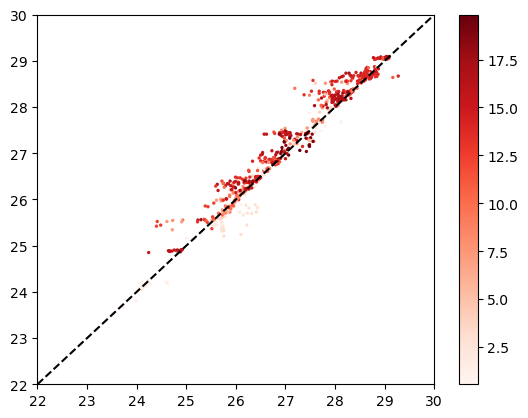

In [123]:
plt.scatter(ds_dive.temp0,ds_dive.temp1,c=ds_dive.depth_max,cmap='Reds',s=2)
# ds_dive.temp0.plot()
plt.colorbar()
# ds_dive.depth_max.plot()
plt.plot([22,30],[22,30],'k--')
plt.xlim(22,30)
plt.ylim(22,30)

In [78]:
pd_dive['lon'] = ds_obs_1.lon_end.isel(time_index=pd_dive['last_record'].values.astype(int)).values
pd_dive['lat'] = ds_obs_1.lat_end.isel(time_index=pd_dive['last_record'].values.astype(int)).values
pd_dive['time'] = ds_obs_1.original_time.isel(time_index=pd_dive['last_record'].values.astype(int)).values
pd_dive['T_bot'] = ds_obs_1.temp.isel(time_index=pd_dive['last_record'].values.astype(int)).values

pd_dive['rec_len'] = pd_dive['last_record']-pd_dive['first_record']
pd_dive

,ik,first_record,last_record,dtb,dmax,T_surf,T_bot,T_surf0,lon,lat,time,rec_len
0,1.0,64,68,NaN,2.91,28.2109375,28.101562,28.2578125,50.780949,25.729845,2023-11-04 06:51:35,4
1,2.0,74,93,NaN,3.04,28.0390625,28.039062,28.140625,50.780949,25.729845,2023-11-04 06:52:05,19
2,3.0,99,128,NaN,2.98,28.0390625,28.015625,28.0390625,50.780411,25.730028,2023-11-04 06:52:49,29
3,4.0,134,149,NaN,1.46,28.3828125,28.406250,28.359375,50.781914,25.724712,2023-11-04 06:54:27,15
4,5.0,153,181,NaN,1.32,28.3671875,28.367188,28.34375,50.781803,25.724785,2023-11-04 06:55:54,28
...,...,...,...,...,...,...,...,...,...,...,...,...
19602,19603.0,609245,609485,NaN,132.56,30.5546875,30.554688,30.28125,50.417881,25.488762,2024-04-26 14:32:49,240
19603,19604.0,609486,609726,NaN,132.56,30.546875,30.546875,30.59375,50.417881,25.488762,2024-04-26 14:40:51,240
19604,19605.0,609727,609967,NaN,132.56,30.359375,30.359375,30.46875,50.417881,25.488762,2024-04-26 14:48:55,240
19605,19606.0,609968,610208,NaN,132.56,30.03125,30.031250,30.21875,50.417881,25.488762,2024-04-26 14:56:59,240


,ik,first_record,last_record,dtb,dmax,T_surf,T_bot,lon,lat,time
0,1.0,64,68,NaN,2.91,28.2109375,28.101562,50.780949,25.729845,2023-11-04 06:51:35
1,2.0,74,93,NaN,3.04,28.0390625,28.039062,50.780949,25.729845,2023-11-04 06:52:05
2,3.0,99,128,NaN,2.98,28.0390625,28.015625,50.780411,25.730028,2023-11-04 06:52:49
3,4.0,134,149,NaN,1.46,28.3828125,28.406250,50.781914,25.724712,2023-11-04 06:54:27
4,5.0,153,181,NaN,1.32,28.3671875,28.367188,50.781803,25.724785,2023-11-04 06:55:54
...,...,...,...,...,...,...,...,...,...,...
19602,19603.0,609245,609485,NaN,132.56,30.5546875,30.554688,50.417881,25.488762,2024-04-26 14:32:49
19603,19604.0,609486,609726,NaN,132.56,30.546875,30.546875,50.417881,25.488762,2024-04-26 14:40:51
19604,19605.0,609727,609967,NaN,132.56,30.359375,30.359375,50.417881,25.488762,2024-04-26 14:48:55
19605,19606.0,609968,610208,NaN,132.56,30.03125,30.031250,50.417881,25.488762,2024-04-26 14:56:59


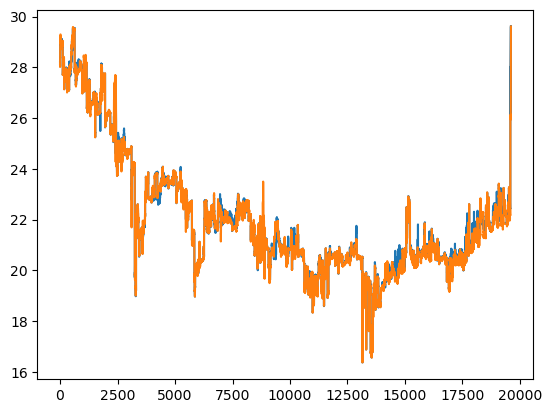

In [55]:
pd_dive[pd_dive['T_surf']<30].T_surf.astype(float).plot()
pd_dive[pd_dive['T_surf']<30].T_bot.astype(float).plot()
pd_dive

<Axes: >

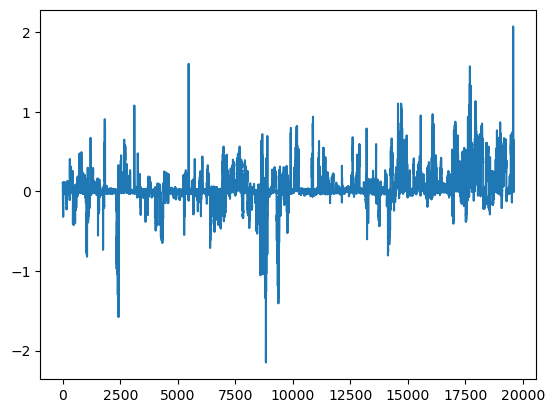

In [104]:
# pd_dive[pd_dive['T_surf']<50].T_surf.astype(float).plot()
(pd_dive[pd_dive['T_surf']<50].T_surf-pd_dive[pd_dive['T_surf']<50].T_bot).astype(float).plot()

In [105]:
pd_dive.to_csv(wrk_dir+'dive_profile_PG_acc_raw_v1_keep_gps_BAHHASO23.csv')

In [106]:
pd_dive = pd.read_csv('dive_profile_PG_acc_raw_v1_keep_gps_BAHHASO23.csv',parse_dates=True,index_col='time')
pd_dive

,Unnamed: 0,ik,first_record,last_record,dtb,dmax,T_surf,T_bot,T_surf0,lon,lat,rec_len
time,,,,,,,,,,,,
2023-11-04 06:51:35,0,1.0,64,68,NaN,2.91,28.210938,28.101562,28.257812,50.780949,25.729845,4
2023-11-04 06:52:05,1,2.0,74,93,NaN,3.04,28.039062,28.039062,28.140625,50.780949,25.729845,19
2023-11-04 06:52:49,2,3.0,99,128,NaN,2.98,28.039062,28.015625,28.039062,50.780411,25.730028,29
2023-11-04 06:54:27,3,4.0,134,149,NaN,1.46,28.382812,28.406250,28.359375,50.781914,25.724712,15
2023-11-04 06:55:54,4,5.0,153,181,NaN,1.32,28.367188,28.367188,28.343750,50.781803,25.724785,28
...,...,...,...,...,...,...,...,...,...,...,...,...
2024-04-26 14:32:49,19602,19603.0,609245,609485,NaN,132.56,30.554688,30.554688,30.281250,50.417881,25.488762,240
2024-04-26 14:40:51,19603,19604.0,609486,609726,NaN,132.56,30.546875,30.546875,30.593750,50.417881,25.488762,240
2024-04-26 14:48:55,19604,19605.0,609727,609967,NaN,132.56,30.359375,30.359375,30.468750,50.417881,25.488762,240


In [107]:
ds_dive = xr.Dataset.from_dataframe(pd_dive)
ds_dive

<xarray.Dataset>
Dimensions:       (time: 19607)
Coordinates:
  * time          (time) datetime64[ns] 2023-11-04T06:51:35 ... 2024-04-26T15...
Data variables:
    Unnamed: 0    (time) int64 0 1 2 3 4 5 ... 19602 19603 19604 19605 19606
    ik            (time) float64 1.0 2.0 3.0 ... 1.96e+04 1.961e+04 1.961e+04
    first_record  (time) int64 64 74 99 134 153 ... 609486 609727 609968 610209
    last_record   (time) int64 68 93 128 149 181 ... 609726 609967 610208 610449
    dtb           (time) float64 nan nan nan nan nan nan ... nan nan nan nan nan
    dmax          (time) float64 2.91 3.04 2.98 1.46 ... 132.6 132.6 132.6 132.6
    T_surf        (time) float64 28.21 28.04 28.04 28.38 ... 30.36 30.03 29.61
    T_bot         (time) float64 28.1 28.04 28.02 28.41 ... 30.36 30.03 29.61
    T_surf0       (time) float64 28.26 28.14 28.04 28.36 ... 30.47 30.22 29.76
    lon           (time) float64 50.78 50.78 50.78 50.78 ... 50.42 50.42 50.42
    lat           (time) float64 25.73 25.73 25.73 25.72 ... 25.49 25.49 25.49
    rec_len       (time) int64 4 19 29 15 28 22 14 ... 240 240 240 240 240 240

In [264]:
ds_mur_sec1=ds_mur.sst.sel(time=slice(ds_dive_2.time.min(),ds_dive_2.time.max()),lon=slice(47,58),lat=slice(22,33))


In [265]:
# UAE 2020
# ds_obs1_rnan = ds_obs1.where((ds_obs1.x>10)&(ds_obs1.y>10)&(ds_obs1.temp<40)&(ds_obs1.temp>10)&(ds_obs1.temp!=31.2421875),drop=True)

# ds_mur_sec1=ds_mur.sst.sel(time=slice(pd_dive.time.min(),pd_dive.time.max()))

fmm1=ds_mur_sec1.interp(lon=ds_dive.lon,lat=ds_dive.lat,time=ds_dive.time) #original

NameError: name 'ds_dive' is not defined

In [261]:
# plot ALL THE DATA (((BEFORE interpolation)))
# ds_obs1_rnan.temp.plot()
# (fmm-273.15).plot()
plt.scatter(fmm1, ds_dive.T_surf, c=ds_dive.T_surf - ds_dive.T_bot, cmap='RdYlBu', s=0.5,vmax=1,vmin=-1)
# plt.scatter(fmm1, ds_dive.T_surf, c=ds_dive.last_record - ds_dive.first_record, cmap='RdBu', s=1)

plt.colorbar(label='T_surf - T_bot')
# plt.colorbar(label='record length (seconds)')



plt.xlim([18, 30]),plt.ylim([18, 30])
plt.plot([18,37],[18,37])

# print(np.sqrt(np.mean(fmm-ds_obs_rnan1.temp)**2).values)
# print(np.sqrt(np.mean(fmm-ds_obs_rnan2.temp)**2).values)
# print(np.sqrt(np.mean(fmm-ds_obs_rnan3.temp)**2).values)
# print(np.sqrt(np.mean(fmm-ds_obs_rnan4.temp)**2).values)

NameError: name 'fmm1' is not defined

In [104]:
# plot ALL THE DATA (((BEFORE interpolation)))
# ds_obs1_rnan.temp.plot()
# (fmm-273.15).plot()
# plt.scatter(fmm1, ds_dive.T_surf, c=ds_dive.T_surf - ds_dive.T_bot, cmap='RdBu', s=0.5,vmax=1,vmin=-1)
plt.figure(figsize=(8,6))
plt.scatter(fmm1, ds_dive.T_surf, c=ds_dive.last_record - ds_dive.first_record, cmap='Reds', s=2,vmax=50)
# plt.scatter(fmm1, ds_dive.where(ds_dive.rec_len<30).T_surf, cmap='RdBu', s=2,vmax=50)
# plt.scatter(fmm1, ds_dive.where(ds_dive.rec_len>30).T_surf, cmap='RdBu', s=2,vmax=50)

# plt.colorbar(label='T_surf - T_bot')
plt.colorbar(label='record length (seconds)')

plt.xlim([18, 30]),plt.ylim([18, 30])
plt.plot([18,37],[18,37])

# print(np.sqrt(np.mean(fmm-ds_obs_rnan1.temp)**2).values)
# print(np.sqrt(np.mean(fmm-ds_obs_rnan2.temp)**2).values)
# print(np.sqrt(np.mean(fmm-ds_obs_rnan3.temp)**2).values)
# print(np.sqrt(np.mean(fmm-ds_obs_rnan4.temp)**2).values)

NameError: name 'fmm1' is not defined

<Figure size 800x600 with 0 Axes>

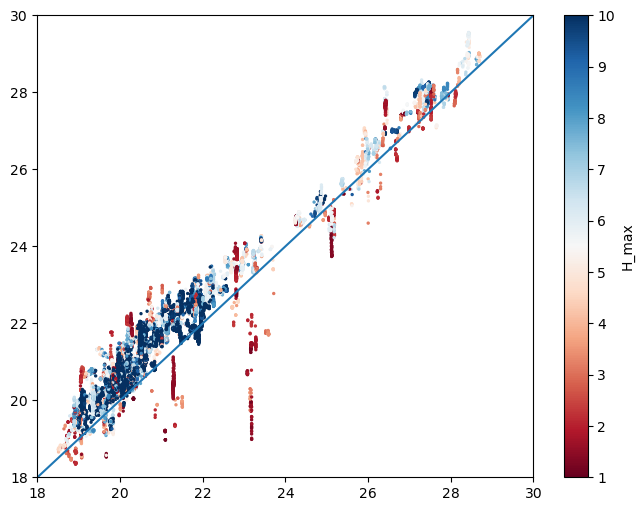

In [74]:
plt.figure(figsize=(8,6))
# plt.scatter(fmm1, ds_dive.T_surf, c=ds_dive.last_record - ds_dive.first_record, cmap='RdBu', s=2,vmax=50)
plt.scatter(fmm1, ds_dive.T_surf, c=ds_dive.dmax, cmap='RdBu', s=2,vmax=10)
# plt.scatter(fmm1, ds_dive.where(ds_dive.rec_len>30).T_surf, cmap='RdBu', s=2,vmax=50)

plt.colorbar(label='H_max (m)')
# plt.colorbar(label='record length (seconds)')

plt.xlim([18, 30]),plt.ylim([18, 30])
plt.plot([18,37],[18,37])

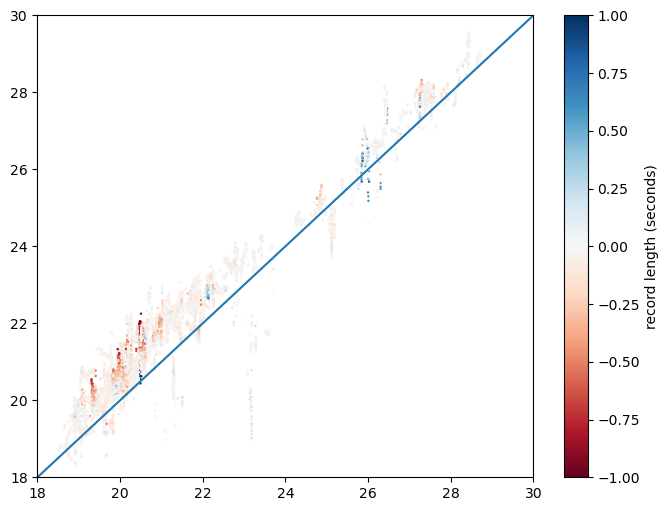

In [ ]:
# plot ALL THE DATA (((BEFORE interpolation)))
# ds_obs1_rnan.temp.plot()
# (fmm-273.15).plot()
plt.figure(figsize=(8,6))
plt.scatter(fmm1, ds_dive.T_surf, c=ds_dive.T_surf0 - ds_dive.T_surf, cmap='RdBu', s=0.5,vmax=1,vmin=-1)
# plt.scatter(fmm1, ds_dive.T_surf, c=(ds_dive.T_surf0 - ds_dive.T_surf)/np.exp(ds_dive.rec_len.astype(float)), cmap='RdBu',vmax=0.001,vmin=-0.001,s=1)
# plt.scatter(fmm1, ds_dive.where(ds_dive.rec_len<30).T_surf, cmap='RdBu', s=2,vmax=50)
# plt.scatter(fmm1, ds_dive.where(ds_dive.rec_len>30).T_surf, cmap='RdBu', s=2,vmax=50)

# plt.colorbar(label='T_surf - T_bot')
plt.colorbar(label='record length (seconds)')

plt.xlim([18, 30]),plt.ylim([18, 30])
plt.plot([18,37],[18,37])

# print(np.sqrt(np.mean(fmm-ds_obs_rnan1.temp)**2).values)
# print(np.sqrt(np.mean(fmm-ds_obs_rnan2.temp)**2).values)
# print(np.sqrt(np.mean(fmm-ds_obs_rnan3.temp)**2).values)
# print(np.sqrt(np.mean(fmm-ds_obs_rnan4.temp)**2).values)

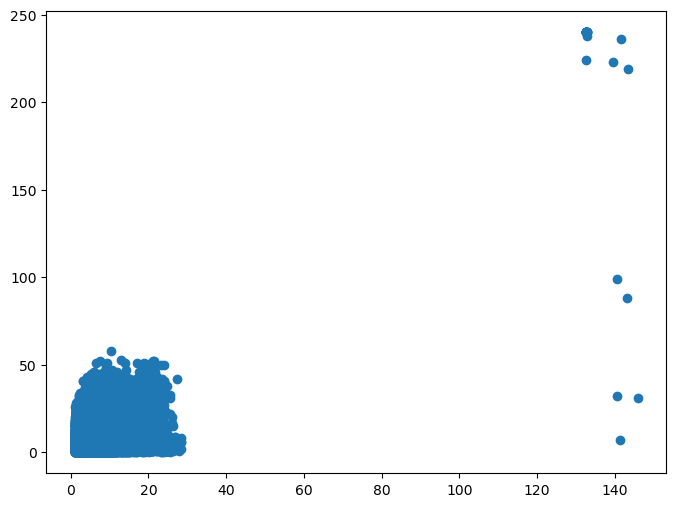

In [96]:

plt.figure(figsize=(8,6))
plt.scatter( ds_dive.dmax,ds_dive.rec_len)

# 2. Find first record and last record for each dive / duration of dives

## do filter / Quality control

### tag 203018 close to the powerplant

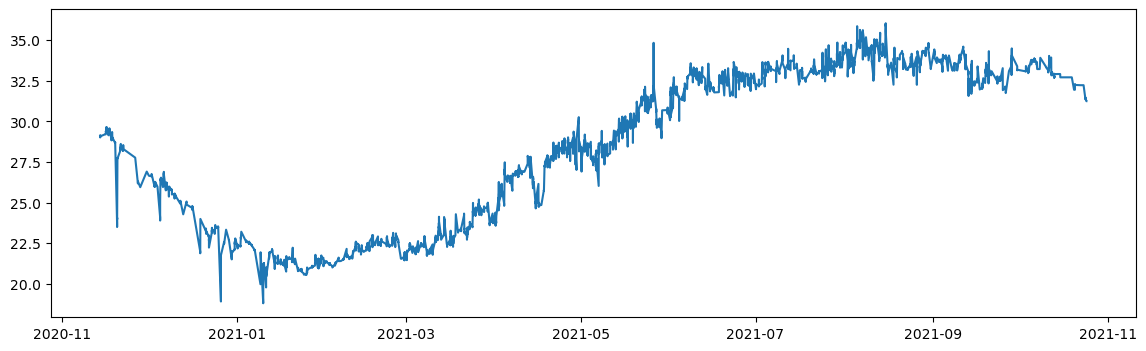

In [367]:
plt.figure(figsize=(14,4))
plt.plot(ds_dive_2.time,ds_dive_2.where((ds_dive_2.tag_id==203018)&(ds_dive_2.time<pd.Timestamp(2021,10,25))).temp1)

# plt.xlim([pd.Timestamp(2021,10,20),pd.Timestamp(2021,11,22)])


In [368]:
ds_dive_2_filtered = ds_dive_2.where(~((ds_dive_2.tag_id == 203018) & (ds_dive_2.time > pd.Timestamp(2021, 10, 25))), drop=True)
ds_dive_2_filtered

<xarray.Dataset>
Dimensions:       (dive_index: 58577)
Coordinates:
  * dive_index    (dive_index) float64 0.0 1.0 2.0 3.0 ... 972.0 973.0 974.0
Data variables:
    tag_id        (dive_index) float64 2.014e+05 2.014e+05 ... 2.03e+05 2.03e+05
    temp1         (dive_index) float64 29.1 29.07 29.08 29.05 ... -1.0 -1.0 -1.0
    temp0         (dive_index) float64 29.02 29.15 29.06 ... -1.0 -1.0 -1.0
    temp_int1     (dive_index) float64 31.0 31.0 31.0 31.0 ... 27.0 27.0 26.0
    temp_int0     (dive_index) float64 30.0 31.0 31.0 31.0 ... 27.0 27.0 27.0
    rec_len       (dive_index) float64 39.0 52.0 36.0 39.0 ... 13.0 12.0 12.0
    first_record  (dive_index) float64 5.509e+04 5.514e+04 ... 6.266e+04
    last_record   (dive_index) float64 5.513e+04 5.519e+04 ... 6.267e+04
    depth_max     (dive_index) float64 13.68 13.69 13.73 ... 3.54 1.92 2.61
    lon           (dive_index) float64 53.15 53.15 53.15 ... 52.95 52.95 52.95
    lat           (dive_index) float64 24.68 24.68 24.68 ... 24.53 24.53 24.53
    time          (dive_index) datetime64[ns] 2020-11-14T06:28:34 ... 2020-12...

### ds_dive_2.tag_id==201410

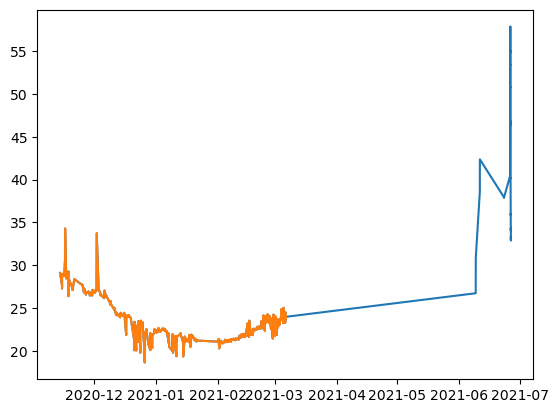

In [369]:
plt.plot(ds_dive_2.time,ds_dive_2.where(((ds_dive_2.tag_id==201410))).temp1)
plt.plot(ds_dive_2.time,ds_dive_2.where(((ds_dive_2.tag_id==201410))& (ds_dive_2.time < pd.Timestamp(2021, 3, 25))).temp1)

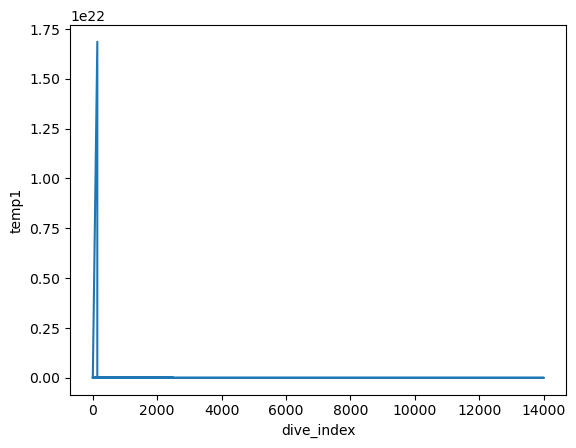

In [370]:
ds_dive_2_filtered = ds_dive_2_filtered.where(~((ds_dive_2_filtered.tag_id == 201410) & (ds_dive_2_filtered.time > pd.Timestamp(2021, 3, 25))), drop=True)
ds_dive_2_filtered.temp1.plot()

### ID = 203029

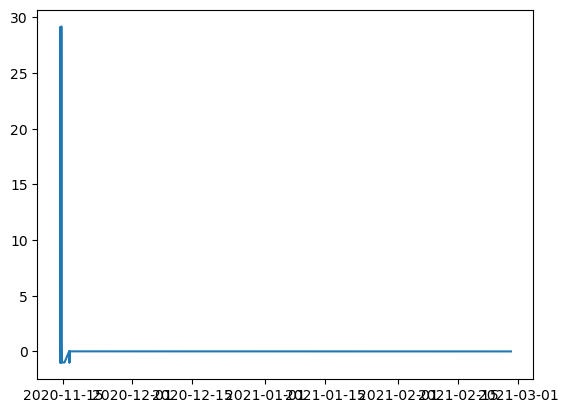

In [371]:
plt.plot(ds_dive_2.time,ds_dive_2.where(((ds_dive_2.tag_id==203029))& (ds_dive_2.time < pd.Timestamp(2021,4, 1))).temp1)

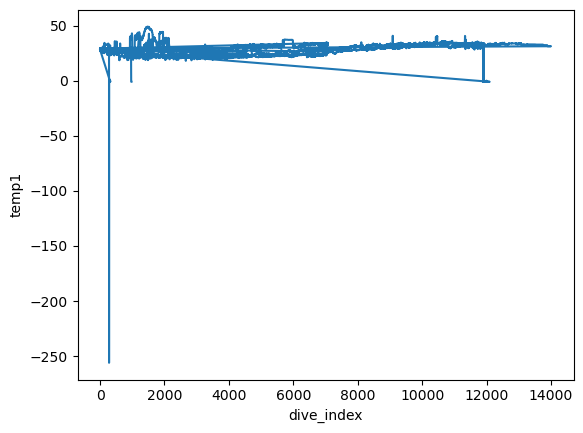

In [373]:
ds_dive_2_filtered = ds_dive_2_filtered.where(~((ds_dive_2_filtered.tag_id == 203029) ), drop=True)
ds_dive_2_filtered.temp1.plot()

### id = 201418

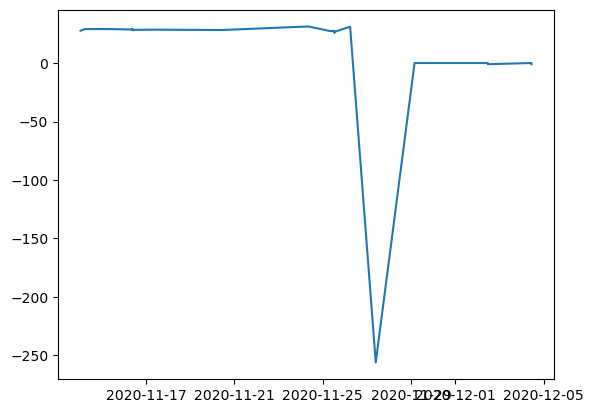

In [376]:
plt.plot(ds_dive_2.time,ds_dive_2.where(((ds_dive_2.tag_id==201418))& (ds_dive_2.time < pd.Timestamp(2025,4, 1))).temp1)

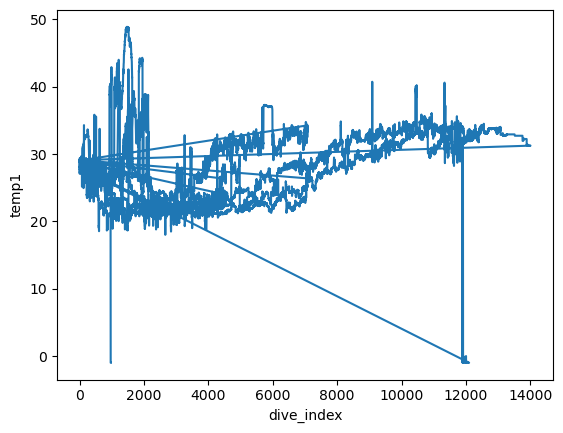

In [377]:
ds_dive_2_filtered = ds_dive_2_filtered.where(~((ds_dive_2_filtered.tag_id == 201418) ), drop=True)
ds_dive_2_filtered.temp1.plot()

### ID = 201411 && 203034 && 203040

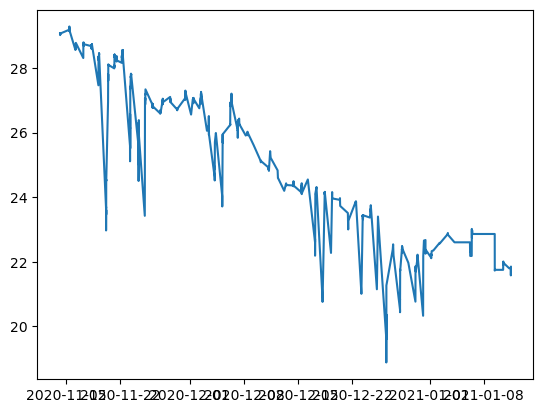

In [329]:
plt.plot(ds_dive_2.time,ds_dive_2.where(((ds_dive_2.tag_id==203034))).temp1)
# plt.show()

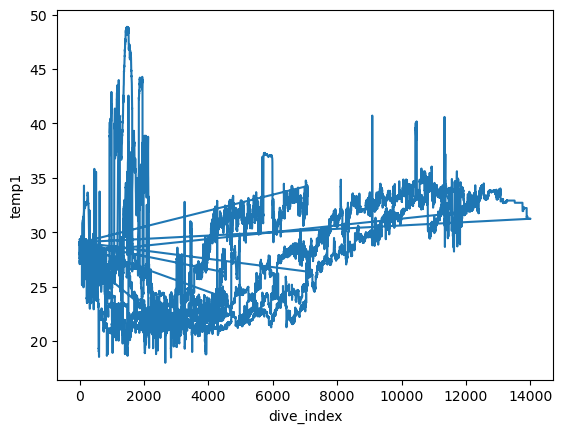

In [378]:
ds_dive_2_filtered = ds_dive_2_filtered.where(~((ds_dive_2_filtered.tag_id == 201411)&(ds_dive_2_filtered.temp1 <= 0) ), drop=True)
# ds_dive_2_filtered = ds_dive_2_filtered.where(~((ds_dive_2_filtered.tag_id == 203034)%(ds_dive_2_filtered.temp1 < 0) ), drop=True)
ds_dive_2_filtered = ds_dive_2_filtered.where(~((ds_dive_2_filtered.tag_id == 203040)&(ds_dive_2_filtered.temp1 < 0) ), drop=True)

ds_dive_2_filtered.temp1.plot()

### temp0 < 0

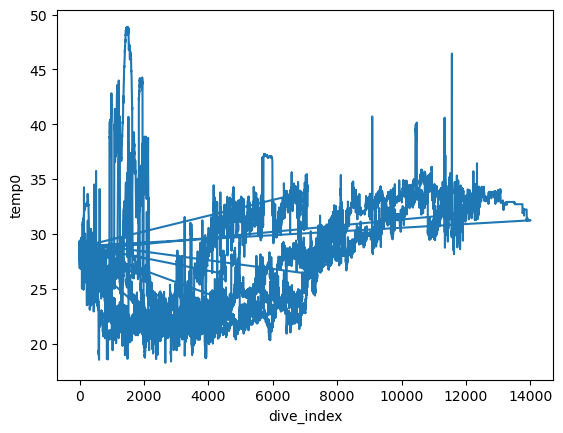

In [379]:
ds_dive_2_filtered = ds_dive_2_filtered.where(~((ds_dive_2_filtered.tag_id == 201411)&(ds_dive_2_filtered.temp0 < 0) ), drop=True)

ds_dive_2_filtered.temp0.plot()

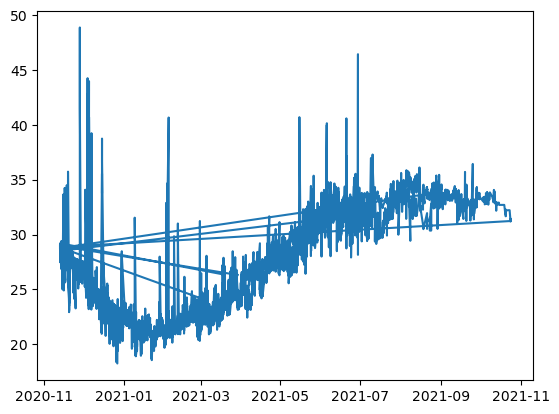

In [332]:
plt.plot(ds_dive_2_filtered.time,ds_dive_2_filtered.temp0)

(18600.0, 18605.0)

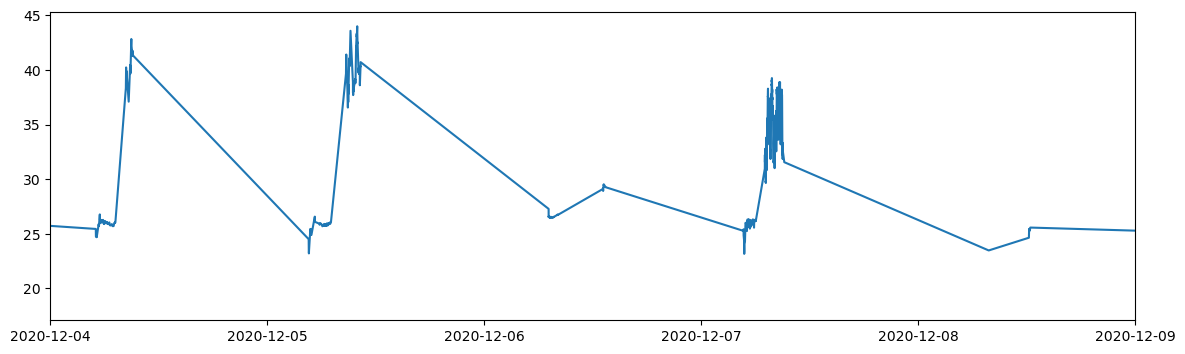

In [380]:
plt.figure(figsize=(14,4))
plt.plot(ds_dive_2_filtered.where(ds_dive_2_filtered.tag_id == 203014).time,ds_dive_2_filtered.where(ds_dive_2_filtered.tag_id == 203014).temp0)
plt.xlim([pd.Timestamp(2020, 12, 4), pd.Timestamp(2020, 12, 9)])

(18600.0, 18605.0)

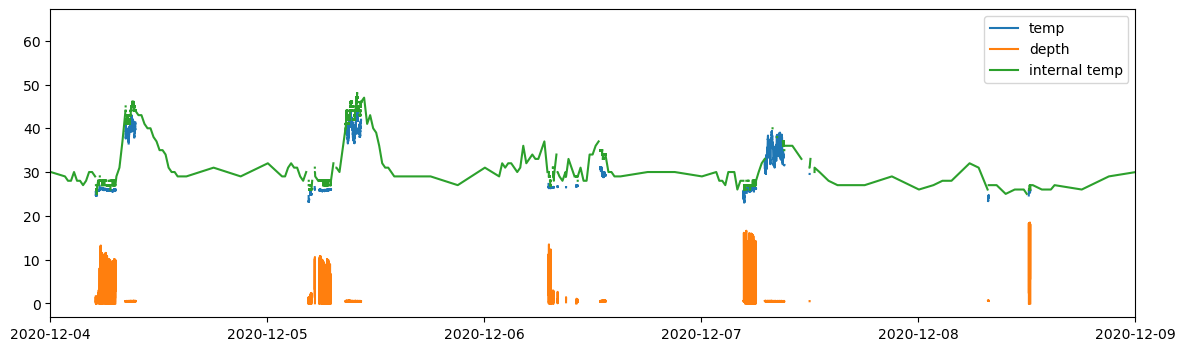

In [381]:
plt.figure(figsize=(14,4))
plt.plot(ds_obs.where(ds_obs.id == 203014).t,ds_obs.where(ds_obs.id == 203014).temp,label='temp')

plt.plot(ds_obs.where(ds_obs.id == 203014).t,ds_obs.where(ds_obs.id == 203014).depth,label='depth')
plt.plot(ds_obs.where(ds_obs.id == 203014).t,ds_obs.where(ds_obs.id == 203014).temp_int,label='internal temp')
plt.legend()
plt.xlim([pd.Timestamp(2020, 12, 4), pd.Timestamp(2020, 12, 9)])

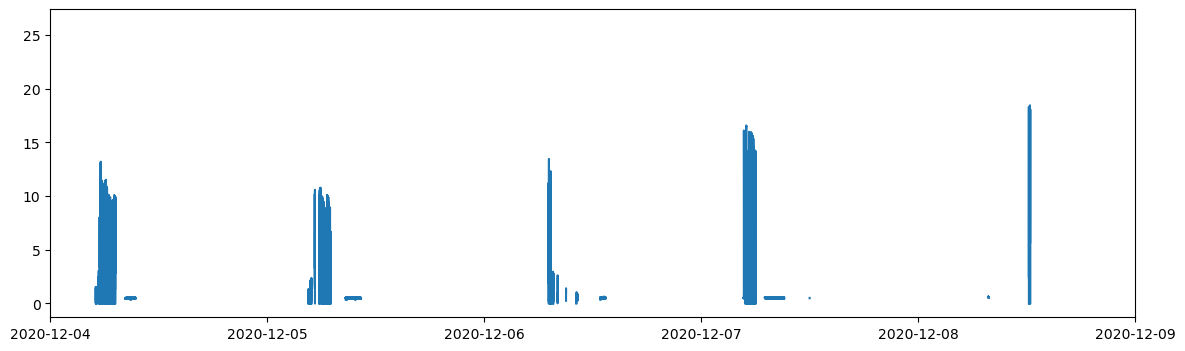

In [142]:
plt.figure(figsize=(14,4))
plt.plot(ds_obs.where(ds_obs.id == 203014).t,ds_obs.where(ds_obs.id == 203014).depth)
plt.xlim([pd.Timestamp(2020, 12, 4), pd.Timestamp(2020, 12, 9)])
plt.show()

In [334]:
np.unique(ds_dive_2_filtered.tag_id)

array([201410., 201411., 201420., 203013., 203014., 203018., 203027.,
       203031., 203034., 203040.])

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


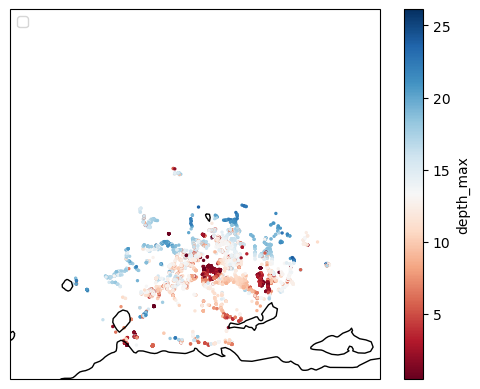

In [149]:
### OLD version
ax = plt.axes(projection=ccrs.PlateCarree())
# plt.plot(ds_obs.lon,ds_obs.lat,'o')

plt.scatter(ds_dive_2_filtered.where(ds_dive_2_filtered.tag_id == 203014).lon,ds_dive_2_filtered.where(ds_dive_2_filtered.tag_id == 203014).lat,
            c=ds_dive_2_filtered.where(ds_dive_2_filtered.tag_id == 203014).depth_max, cmap='RdBu', s=2)
plt.colorbar(label='depth_max')
ax.coastlines()
ax.set_xlim(52,54)
ax.set_ylim(24,26)
# ax.set_xticks(np.arange(47,58,2), crs=ccrs.PlateCarree())
# ax.set_yticks(np.arange(22,33,2), crs=ccrs.PlateCarree())
ax.legend(loc = "upper left")
plt.show()

## interpolate the data

In [150]:
ds_mur_sec1=ds_mur.sst.sel(time=slice(ds_dive_2.time.min(),ds_dive_2.time.max()),lon=slice(47,58),lat=slice(22,33))

(24.0, 26.0)

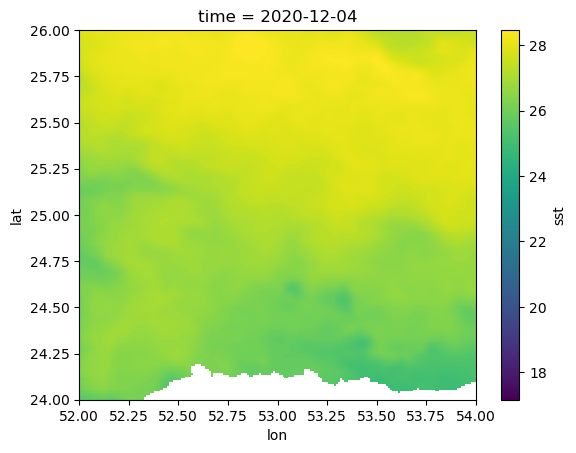

In [151]:
ds_mur_sec1.sel(time=pd.Timestamp(2020, 12, 4),method='nearest').plot()

plt.xlim(52,54)
plt.ylim(24,26)

In [152]:
# fmm2=ds_mur_sec1.interp(lon=ds_dive_2_filtered.lon,lat=ds_dive_2_filtered.lat,time=ds_dive_2_filtered.time) #original
fmm2=ds_mur_sec1.interp(lon=ds_dive_2_filtered.lon,lat=ds_dive_2_filtered.lat,time=ds_dive_2_filtered.time) #original
fmm2_0=ds_mur_sec1.interp(lon=ds_dive_2.lon,lat=ds_dive_2.lat,time=ds_dive_2.time) #original

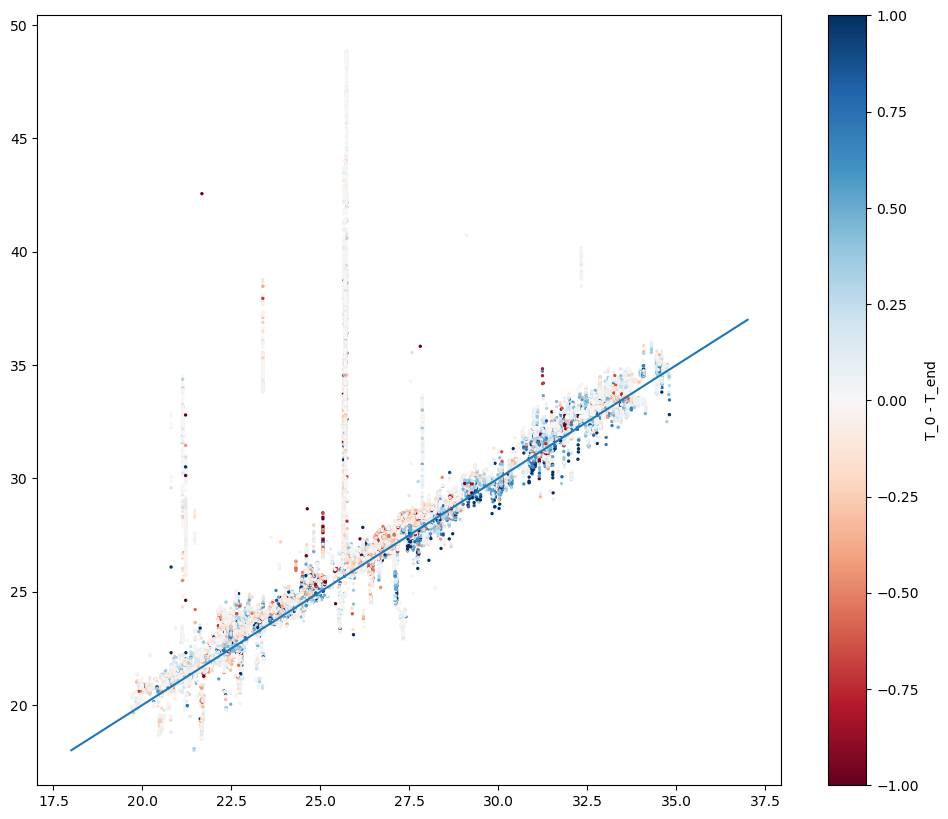

In [153]:
plt.figure(figsize=(12,10))

# plt.scatter(fmm2,ds_dive_2.where(ds_dive_2.dive_index>25000).temp1,c=ds_dive_2.temp0-ds_dive_2.temp1,cmap='RdBu',s=2,vmax=1,vmin=-1)
# plt.scatter(fmm2,ds_dive_2.where(ds_dive_2.dive_index<5000).temp1,c=ds_dive_2.temp0-ds_dive_2.temp1,cmap='RdBu',s=2,vmax=1,vmin=-1)
# plt.scatter(fmm2_0,ds_dive_2.where(ds_dive_2.temp1<50).temp1,c='k',cmap='RdBu',s=2,vmax=1,vmin=-1)
plt.scatter(fmm2,ds_dive_2_filtered.where(ds_dive_2_filtered.temp1<50).temp1,c=ds_dive_2_filtered.temp0-ds_dive_2_filtered.temp1,cmap='RdBu',s=2,vmax=1,vmin=-1)
# plt.scatter(fmm2,ds_dive_2.temp0,c='r',cmap='RdBu',s=2,vmax=1,vmin=-1)

# plt.xlim([18, 37]),plt.ylim([18, 37])
plt.plot([18,37],[18,37])
plt.colorbar(label='T_0 - T_end')

/tmp/ipykernel_553418/118470784.py:5: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'vmax' will be ignored
  plt.scatter(fmm2,ds_dive_2_filtered.where((ds_dive_2_filtered.depth_max<3)&(ds_dive_2_filtered.depth_max>=0)&(ds_dive_2_filtered.rec_len>0)).temp1,c ='r', cmap='jet',s=2,vmax=50)


((18.0, 37.0), (18.0, 37.0))

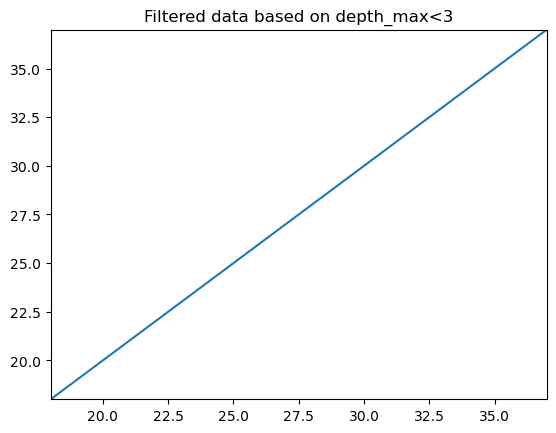

In [342]:
ds000 = ds_dive_2_filtered.where((ds_dive_2_filtered.temp0-ds_dive_2_filtered.temp1>0.8)&(ds_dive_2_filtered.rec_len>30))
# print(len(ds000))

# plt.scatter(fmm2,ds_dive_2_filtered.where(ds_dive_2_filtered.depth_max<50).temp1,c =ds_dive_2_filtered.depth_max, cmap='jet',s=2)
plt.scatter(fmm2,ds_dive_2_filtered.where((ds_dive_2_filtered.depth_max<3)&(ds_dive_2_filtered.depth_max>=0)&(ds_dive_2_filtered.rec_len>0)).temp1,c ='r', cmap='jet',s=2,vmax=50)
# plt.scatter(fmm2,ds_dive_2_filtered.where((ds_dive_2_filtered.depth_max<5)&(ds_dive_2_filtered.depth_max>=0)&(ds_dive_2_filtered.rec_len<5)).temp1,c ='k', cmap='jet',s=2,vmax=50)

plt.title('Filtered data based on depth_max<3')
plt.plot([18,37],[18,37])
plt.xlim([18, 37]),plt.ylim([18, 37])

# plt.colorbar(label='T_surf - T_bot')
# plt.colorbar()

In [ ]:
plt.scatter(fmm2,ds000.temp1,c =ds000.rec_len, cmap='jet',s=2,vmax=50)
plt.plot([18,37],[18,37])
plt.xlim([18, 37]),plt.ylim([18, 37])

# plt.colorbar(label='T_surf - T_bot')
plt.colorbar()

/tmp/ipykernel_553418/2466906955.py:3: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'vmin', 'vmax' will be ignored
  plt.scatter(fmm2,ds_dive_2_filtered.temp0,c='b',cmap='RdBu',s=2,vmax=1,vmin=-1)
/tmp/ipykernel_553418/2466906955.py:4: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'vmin', 'vmax' will be ignored
  plt.scatter(fmm2,ds_dive_2_filtered.temp1,c='r',cmap='RdBu',s=2,vmax=1,vmin=-1)


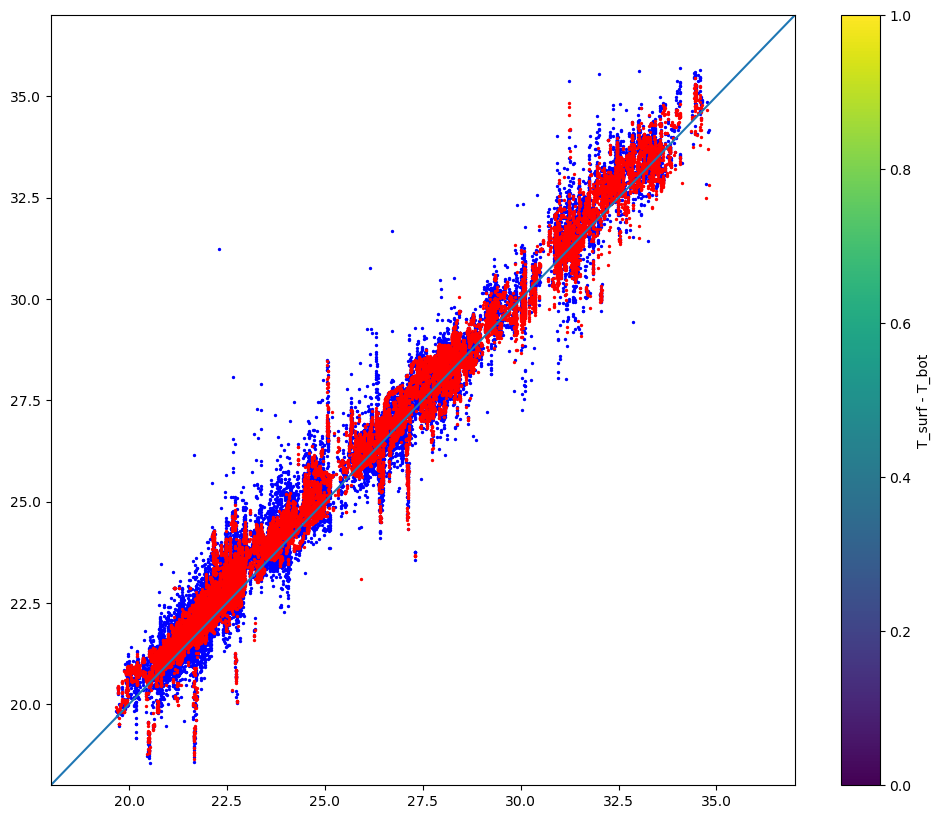

In [365]:
plt.figure(figsize=(12,10))

plt.scatter(fmm2,ds_dive_2_filtered.temp0,c='b',cmap='RdBu',s=2,vmax=1,vmin=-1)
plt.scatter(fmm2,ds_dive_2_filtered.temp1,c='r',cmap='RdBu',s=2,vmax=1,vmin=-1)


plt.xlim([18, 37]),plt.ylim([18, 37])
plt.plot([18,37],[18,37])
plt.colorbar(label='T_surf - T_bot')

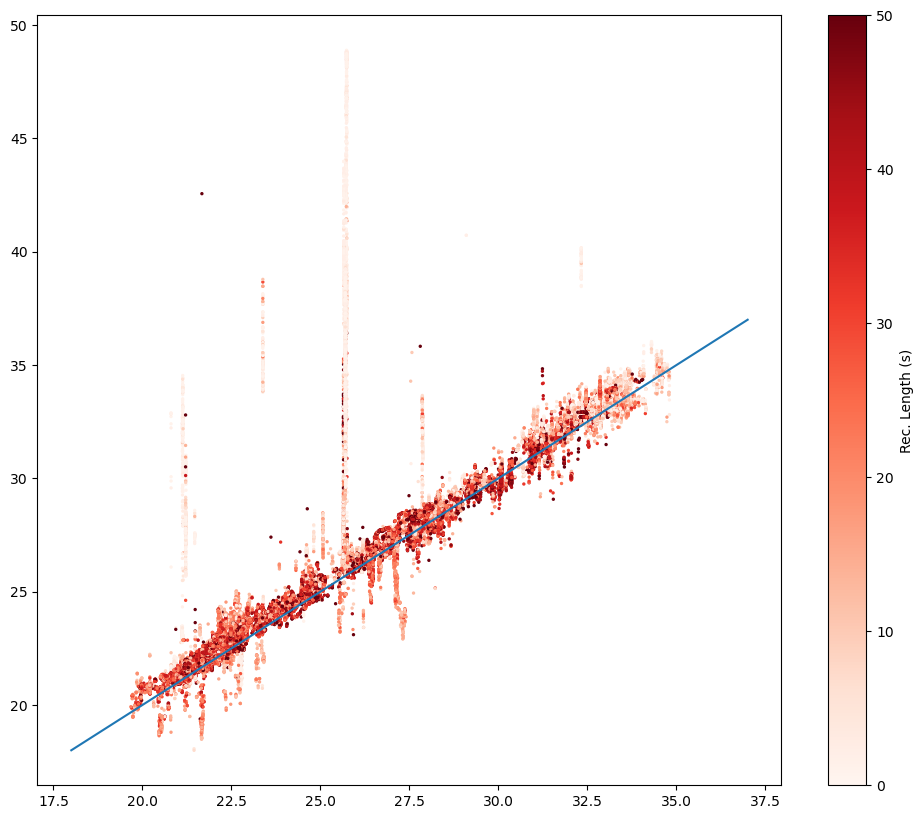

In [217]:
plt.figure(figsize=(12,10))

plt.scatter(fmm2,ds_dive_2_filtered.where(ds_dive_2_filtered.rec_len>0).temp1,c=ds_dive_2_filtered.rec_len,cmap='Reds',s=2,vmax=50,vmin=0)
# plt.scatter(fmm2,ds_dive_2_filtered.where(ds_dive_2_filtered.rec_len>30).temp1,c=ds_dive_2_filtered.rec_len,cmap='Reds',s=2,vmax=50,vmin=0)
# plt.scatter(fmm2,ds_dive_2.where((ds_dive_2.tag_id==237256)).temp1,color='g',s=2,vmax=50,vmin=0)

# plt.xlim([18, 39]),plt.ylim([18, 39])
plt.plot([18,37],[18,37])
plt.colorbar(label='Rec. Length (s)')

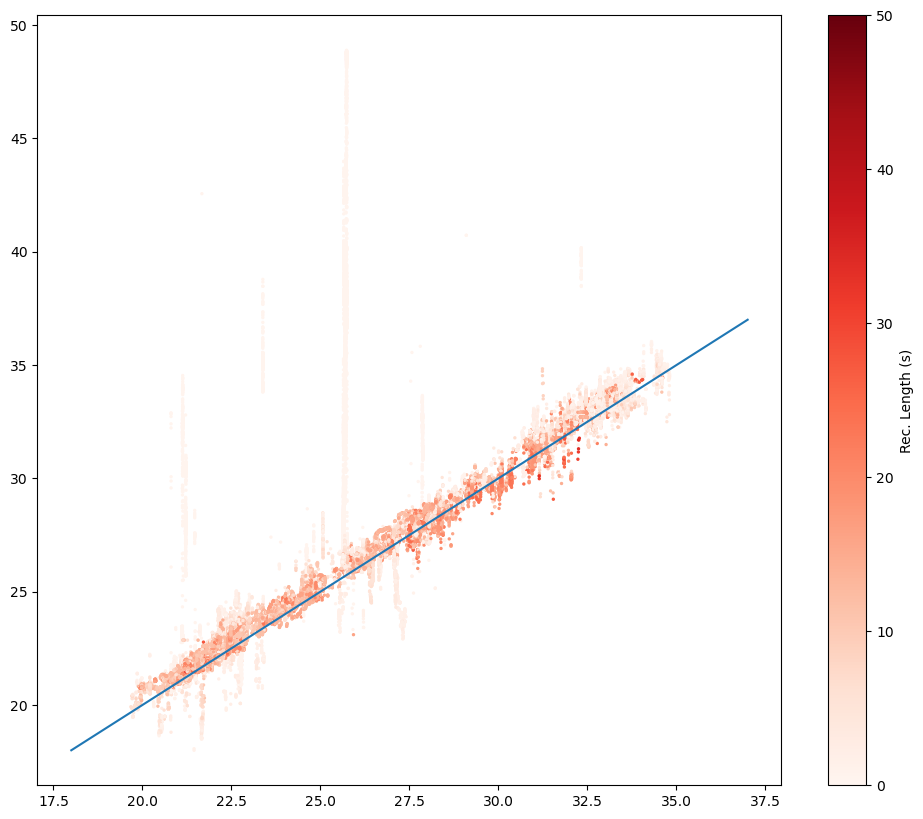

In [384]:
plt.figure(figsize=(12,10))

plt.scatter(fmm2,ds_dive_2_filtered.where(ds_dive_2_filtered.depth_max>0).temp1,c=ds_dive_2_filtered.depth_max,cmap='Reds',s=2,vmax=50,vmin=0)
# plt.scatter(fmm2,ds_dive_2_filtered.where(ds_dive_2_filtered.rec_len>30).temp1,c=ds_dive_2_filtered.rec_len,cmap='Reds',s=2,vmax=50,vmin=0)
# plt.scatter(fmm2,ds_dive_2.where((ds_dive_2.tag_id==237256)).temp1,color='g',s=2,vmax=50,vmin=0)

# plt.xlim([18, 39]),plt.ylim([18, 39])
plt.plot([18,37],[18,37])
plt.colorbar(label='Rec. Length (s)')

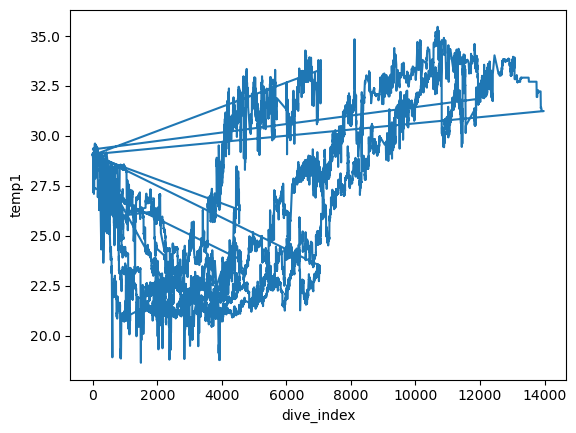

In [348]:
ds_dive_2_filtered.where(~np.isnan(ds_dive_2_filtered.temp1),drop=True).temp1.plot()

0
0.8195215898218791
2.698932437180867
1
0.9903364717979577
0.5561235968176877
2
0.992700381050567
0.46016833402108626
3
0.9933975769654549
0.42258711014173433
4
0.994338017541971
0.38317172176892256
5
0.9945199740609506
0.371361890052625
6
0.9948478055597388
0.35636676859516747
7
0.9950386614144525
0.34736184933629405
8
0.9951794028804888
0.341773419410316
9
0.9953006395727904
0.33722824307366533


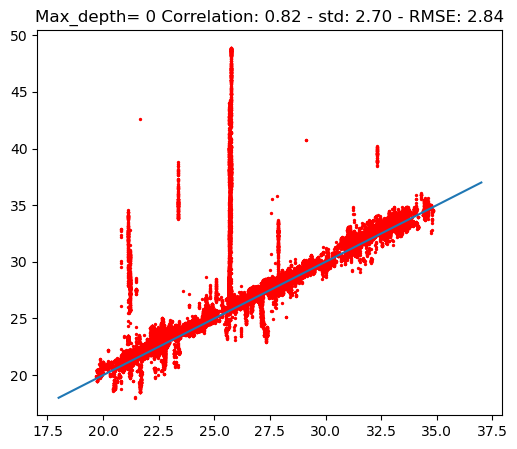

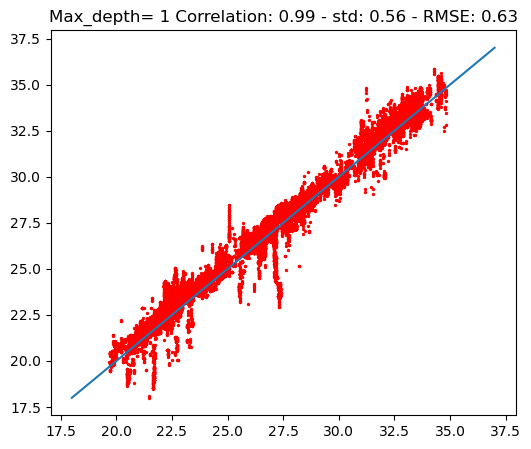

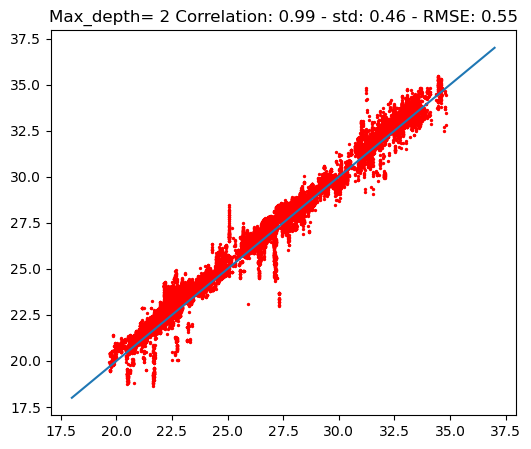

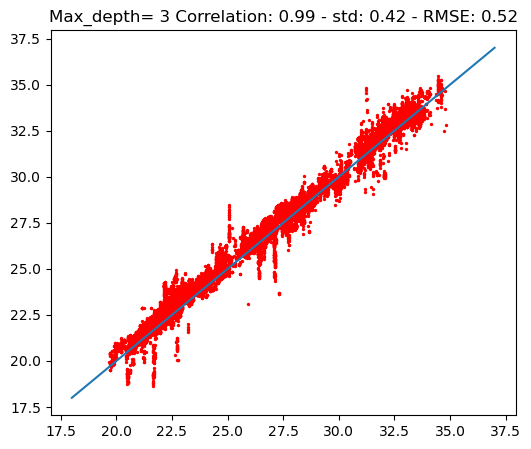

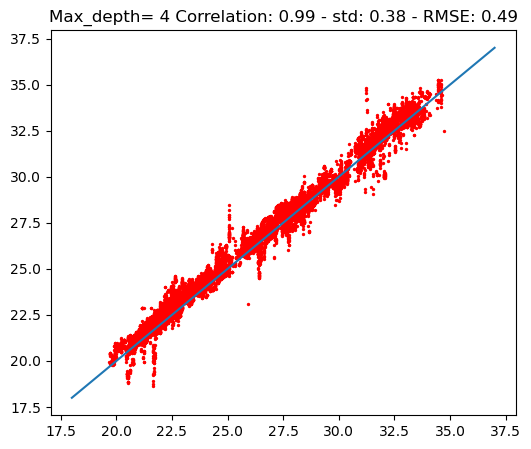

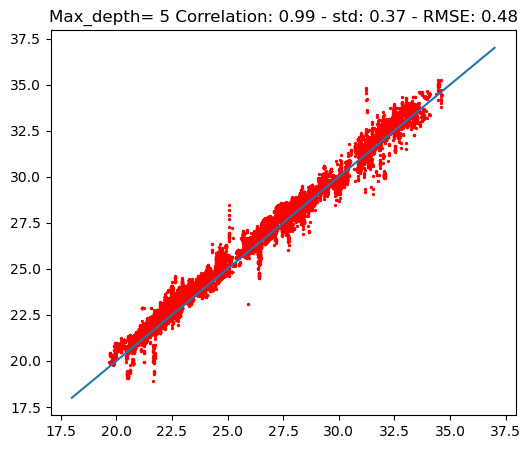

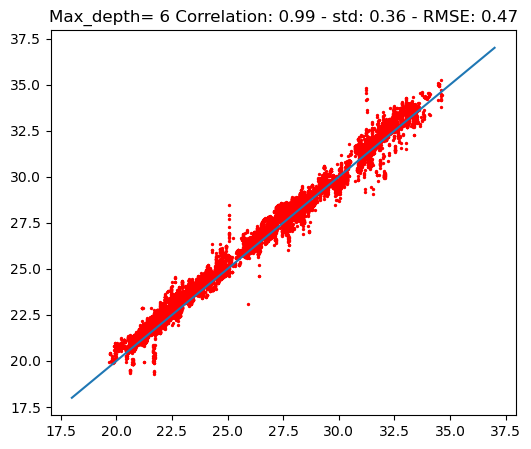

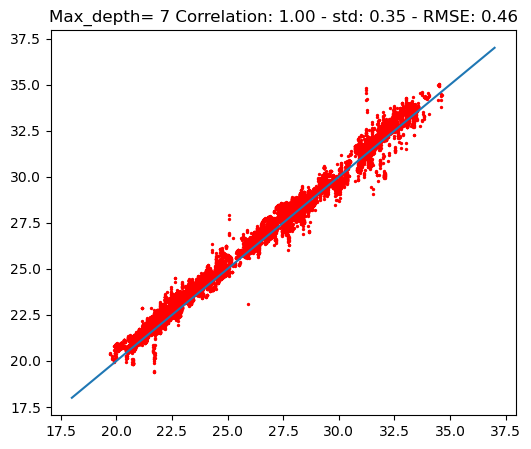

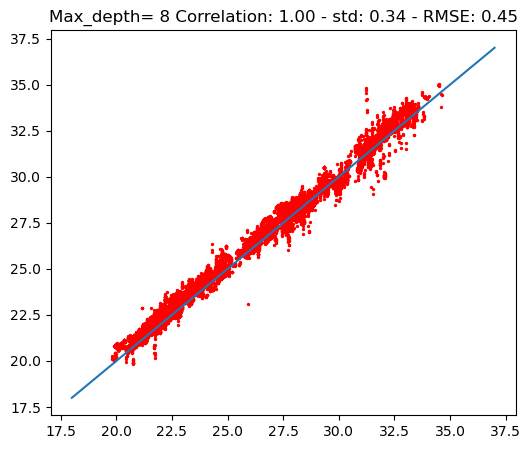

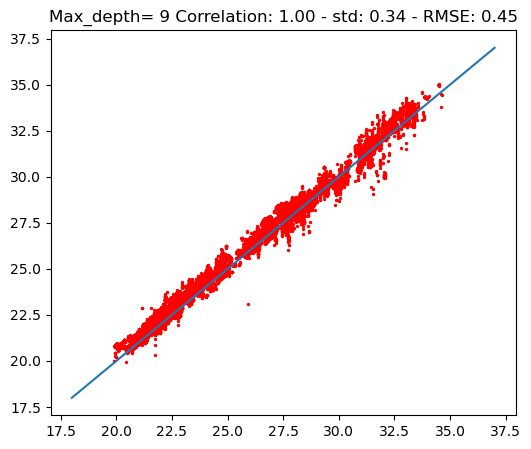

In [394]:
## calculate correlation
corr_with_depth=[]
std_with_depth=[]
rmse_with_depth=[]
for hcut in np.arange(0,10,1):

    fmm2_dn = fmm2.where((~np.isnan(ds_dive_2_filtered.temp1))&(ds_dive_2_filtered.depth_max>hcut),drop=True).values
    ds_dive_2_filtered_dn = ds_dive_2_filtered.where((~np.isnan(ds_dive_2_filtered.temp1))&(ds_dive_2_filtered.depth_max>hcut),drop=True).temp1.values

    fmm2_dn2 = fmm2_dn[~np.isnan(fmm2_dn)]
    ds_dive_2_filtered_dn2 = ds_dive_2_filtered_dn[~np.isnan(fmm2_dn)]
    print(hcut)
    print(np.corrcoef(fmm2_dn2,ds_dive_2_filtered_dn2)[1,0])
    print(np.std(fmm2_dn2-ds_dive_2_filtered_dn2))
    corr_with_depth.append(np.corrcoef(fmm2_dn2,ds_dive_2_filtered_dn2)[1,0])
    std_with_depth.append(np.std(fmm2_dn2-ds_dive_2_filtered_dn2))
    rmse_with_depth.append(np.sqrt(np.mean((fmm2_dn2-ds_dive_2_filtered_dn2)**2)))
    plt.figure(figsize=(6,5))
    plt.scatter(fmm2_dn2,ds_dive_2_filtered_dn2,c='r',s=2)
    plt.plot([18,37],[18,37])
    plt.title(f'Max_depth= {hcut} Correlation: {np.corrcoef(fmm2_dn2,ds_dive_2_filtered_dn2)[1,0]:.2f} - std: {np.std(fmm2_dn2-ds_dive_2_filtered_dn2):.2f} - RMSE: {np.sqrt(np.mean((fmm2_dn2-ds_dive_2_filtered_dn2)**2)):.2f}')


0
0.9933975769654549
0.42258711014173433
5
0.9933972048848345
0.42241876205402124
10
0.993388687523935
0.41986769300945814
15
0.9934692618084534
0.4107051504309872
20
0.9938178527975678
0.3932903781181082
25
0.9942855658872238
0.3749405888061515
30
0.9946704636496859
0.3612033578010958


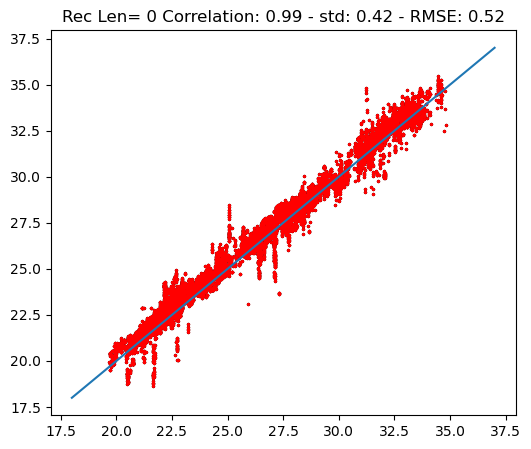

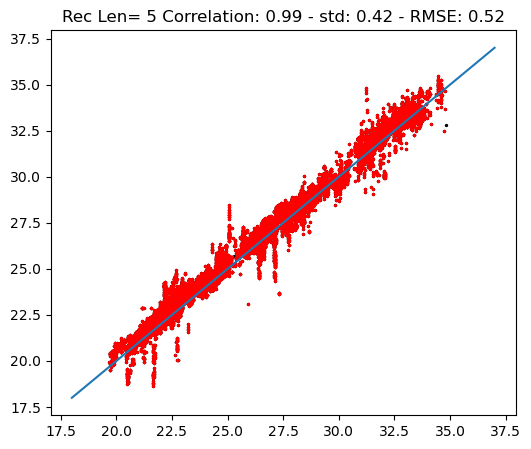

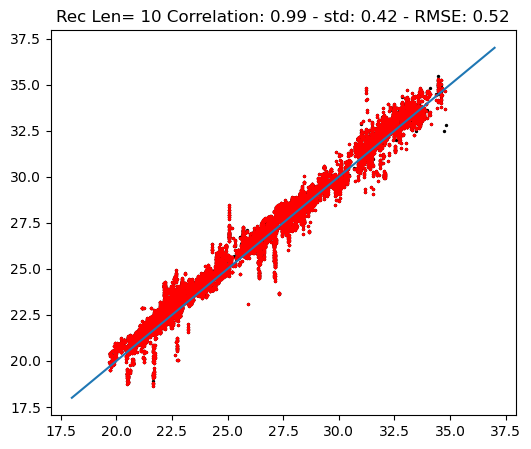

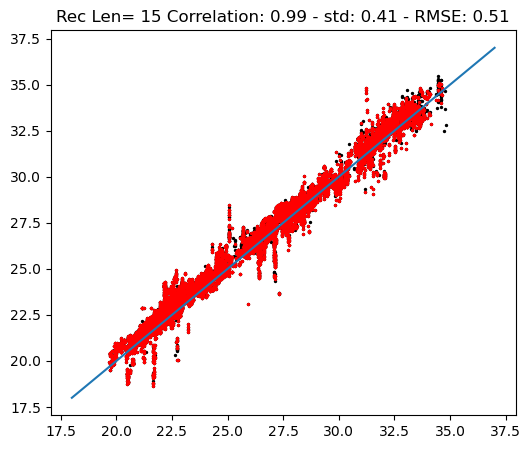

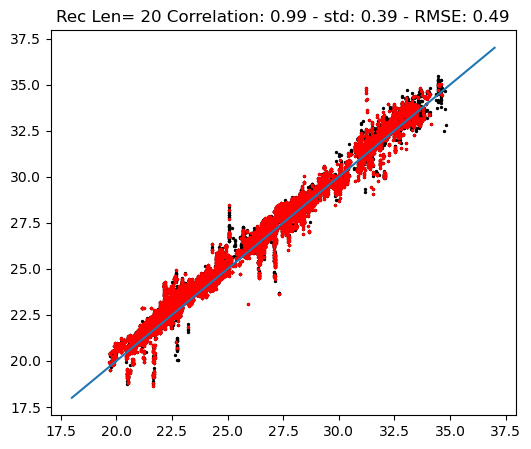

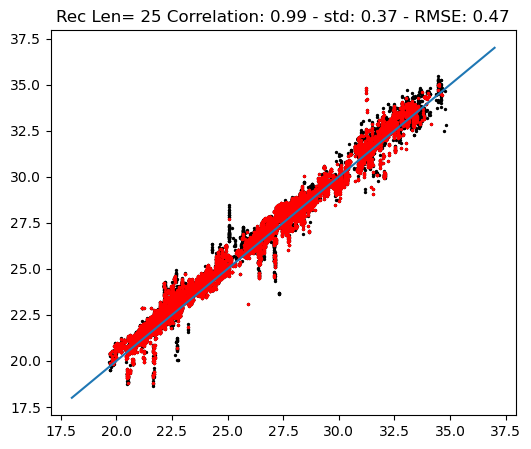

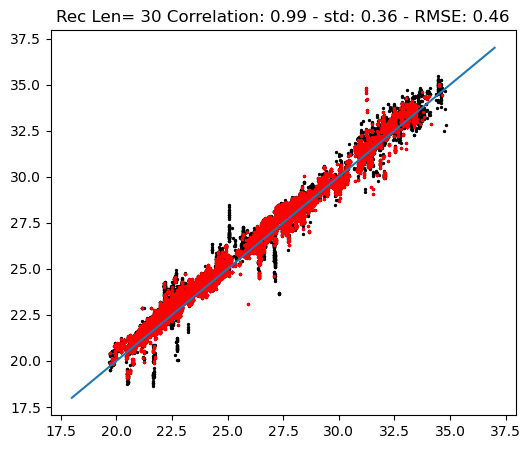

In [430]:
## calculate correlation
corr_with_depth=[]
std_with_depth=[]
rmse_with_depth=[]
for hcut in np.arange(0,35,5):

    fmm2_dn = fmm2.where((~np.isnan(ds_dive_2_filtered.temp1))&(ds_dive_2_filtered.rec_len>hcut)&(ds_dive_2_filtered.depth_max>3),drop=True).values
    ds_dive_2_filtered_dn = ds_dive_2_filtered.where((~np.isnan(ds_dive_2_filtered.temp1))&(ds_dive_2_filtered.rec_len>hcut)&(ds_dive_2_filtered.depth_max>3),drop=True).temp1.values

    fmm2_dn2 = fmm2_dn[~np.isnan(fmm2_dn)]
    ds_dive_2_filtered_dn2 = ds_dive_2_filtered_dn[~np.isnan(fmm2_dn)]
    print(hcut)
    print(np.corrcoef(fmm2_dn2,ds_dive_2_filtered_dn2)[1,0])
    print(np.std(fmm2_dn2-ds_dive_2_filtered_dn2))
    corr_with_depth.append(np.corrcoef(fmm2_dn2,ds_dive_2_filtered_dn2)[1,0])
    std_with_depth.append(np.std(fmm2_dn2-ds_dive_2_filtered_dn2))
    rmse_with_depth.append(np.sqrt(np.mean((fmm2_dn2-ds_dive_2_filtered_dn2)**2)))
    plt.figure(figsize=(6,5))
    plt.scatter(fmm2,ds_dive_2_filtered.temp1.where(ds_dive_2_filtered.depth_max>3),c='k',s=2)
    plt.scatter(fmm2_dn2,ds_dive_2_filtered_dn2,c='r',s=2)
    plt.plot([18,37],[18,37])
    plt.title(f'Rec Len= {hcut} Correlation: {np.corrcoef(fmm2_dn2,ds_dive_2_filtered_dn2)[1,0]:.2f} - std: {np.std(fmm2_dn2-ds_dive_2_filtered_dn2):.2f} - RMSE: {np.sqrt(np.mean((fmm2_dn2-ds_dive_2_filtered_dn2)**2)):.2f}')

0.0
nan
nan
0.1
0.9936974453745427
0.41007807381707634
0.2
0.9936650168628645
0.41073735362295916
0.30000000000000004
0.9936908568704491
0.41150413817888587
0.4
0.9936497780433694
0.41362560941851856
0.5
0.9936111298464279
0.41516966532023136
0.6000000000000001
0.9935569394225029
0.4173891754357726
0.7000000000000001
0.9935241574659492
0.41865912466717903
0.8
0.9935306590909733
0.4190426444766725
0.9
0.9934981841138761
0.4200190925183336


/home/server/pi/homes/liux8/.conda/envs/dev_scipy/lib/python3.11/site-packages/numpy/lib/function_base.py:520: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
/home/server/pi/homes/liux8/.conda/envs/dev_scipy/lib/python3.11/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/home/server/pi/homes/liux8/.conda/envs/dev_scipy/lib/python3.11/site-packages/numpy/lib/function_base.py:2889: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/home/server/pi/homes/liux8/.conda/envs/dev_scipy/lib/python3.11/site-packages/numpy/lib/function_base.py:2748: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/home/server/pi/homes/liux8/.conda/envs/dev_scipy/lib/python3.11/site-packages/numpy/lib/function_base.py:2748: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)
/home/server/pi/homes/liux8/.conda/envs/d

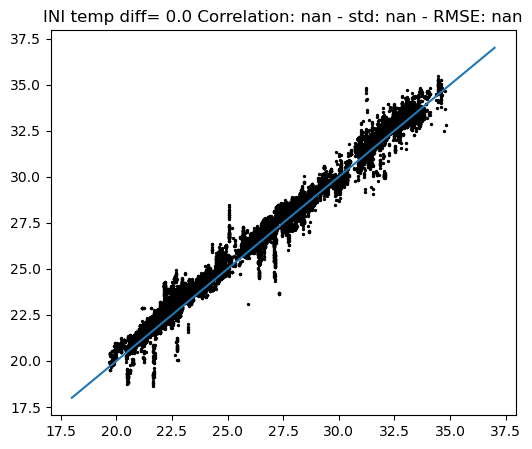

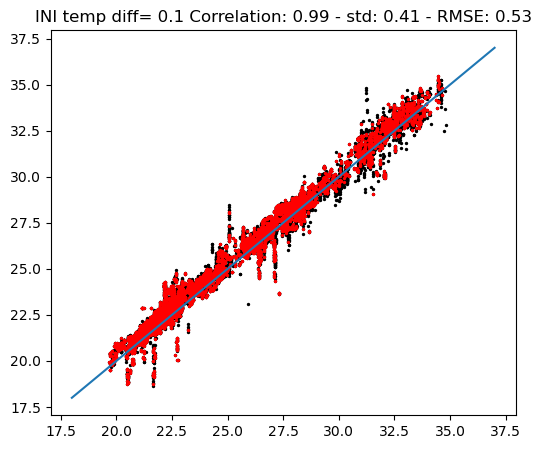

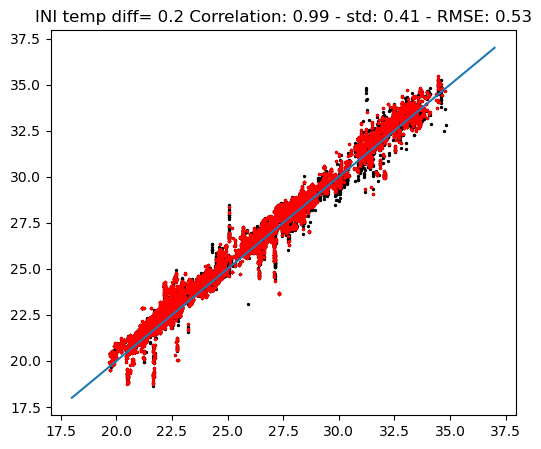

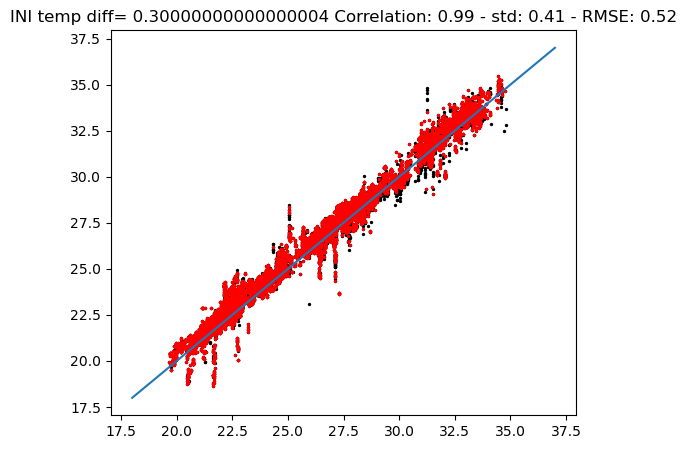

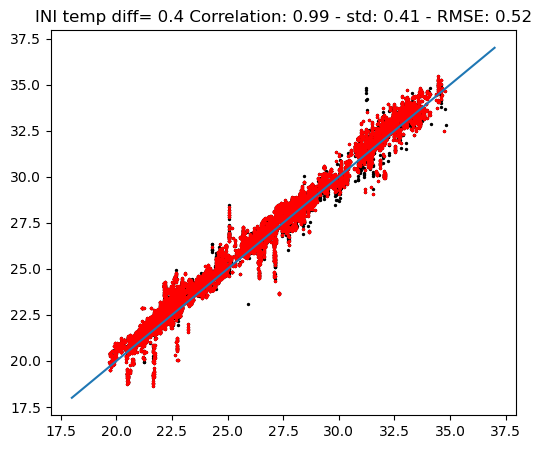

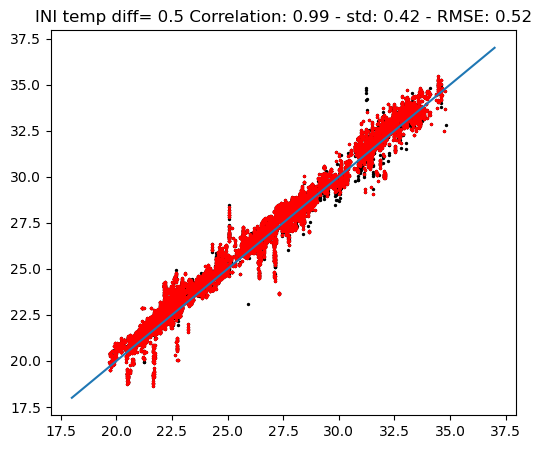

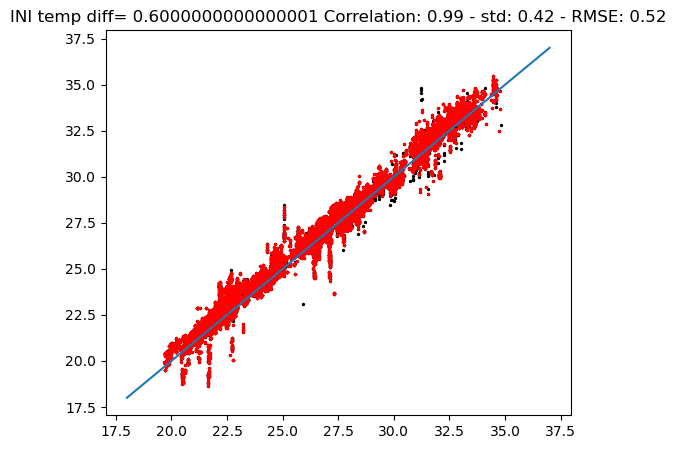

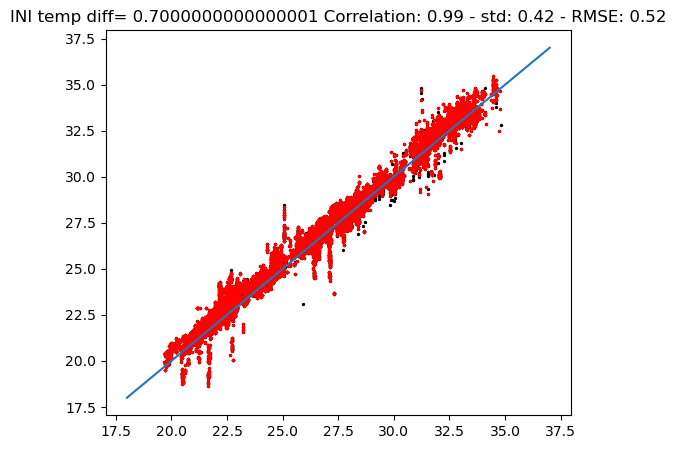

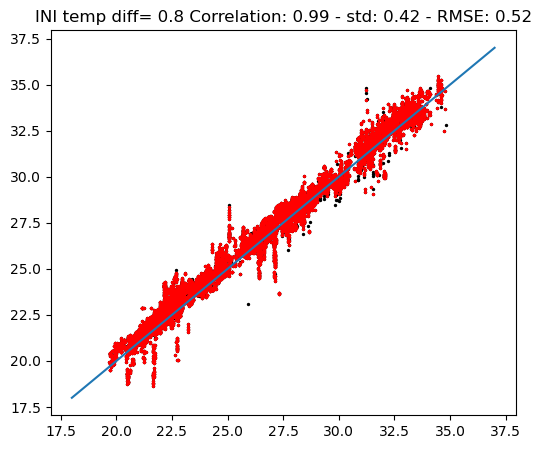

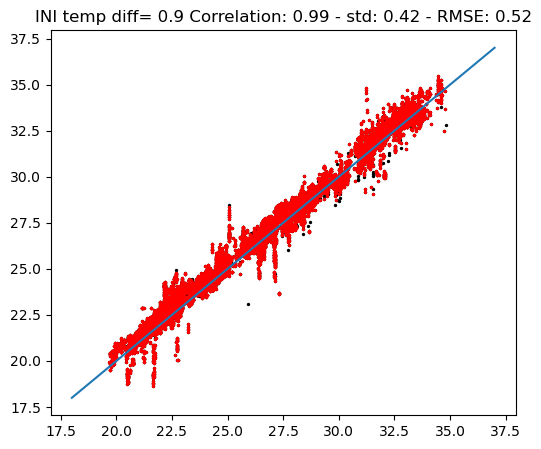

In [429]:
## calculate correlation
corr_with_depth=[]
std_with_depth=[]
rmse_with_depth=[]
for hcut in np.arange(0,1,0.1):

    fmm2_dn = fmm2.where((~np.isnan(ds_dive_2_filtered.temp1))&(np.abs(ds_dive_2_filtered.temp0-ds_dive_2_filtered.temp1)<hcut)&(ds_dive_2_filtered.depth_max>3),drop=True).values
    ds_dive_2_filtered_dn = ds_dive_2_filtered.where((~np.isnan(ds_dive_2_filtered.temp1))&(np.abs(ds_dive_2_filtered.temp0-ds_dive_2_filtered.temp1)<hcut)&(ds_dive_2_filtered.depth_max>3),drop=True).temp1.values

    fmm2_dn2 = fmm2_dn[~np.isnan(fmm2_dn)]
    ds_dive_2_filtered_dn2 = ds_dive_2_filtered_dn[~np.isnan(fmm2_dn)]
    print(hcut)
    print(np.corrcoef(fmm2_dn2,ds_dive_2_filtered_dn2)[1,0])
    print(np.std(fmm2_dn2-ds_dive_2_filtered_dn2))
    corr_with_depth.append(np.corrcoef(fmm2_dn2,ds_dive_2_filtered_dn2)[1,0])
    std_with_depth.append(np.std(fmm2_dn2-ds_dive_2_filtered_dn2))
    rmse_with_depth.append(np.sqrt(np.mean((fmm2_dn2-ds_dive_2_filtered_dn2)**2)))
    plt.figure(figsize=(6,5))
    plt.scatter(fmm2,ds_dive_2_filtered.temp1.where(ds_dive_2_filtered.depth_max>3),c='k',s=2)
    plt.scatter(fmm2_dn2,ds_dive_2_filtered_dn2,c='r',s=2)
    plt.plot([18,37],[18,37])
    plt.title(f'INI temp diff= {hcut} Correlation: {np.corrcoef(fmm2_dn2,ds_dive_2_filtered_dn2)[1,0]:.2f} - std: {np.std(fmm2_dn2-ds_dive_2_filtered_dn2):.2f} - RMSE: {np.sqrt(np.mean((fmm2_dn2-ds_dive_2_filtered_dn2)**2)):.2f}')

Text(0.5, 1.0, 'Correlation with max-depth')

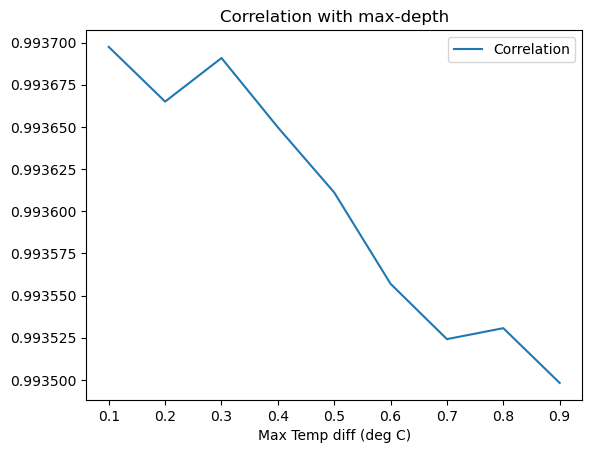

In [425]:
plt.plot(np.arange(0,1,0.1),corr_with_depth,label='Correlation')
# plt.plot(std_with_depth,label='STD')
plt.xlabel('Max Temp diff (deg C)')
plt.legend()
plt.title('Correlation with max-depth')

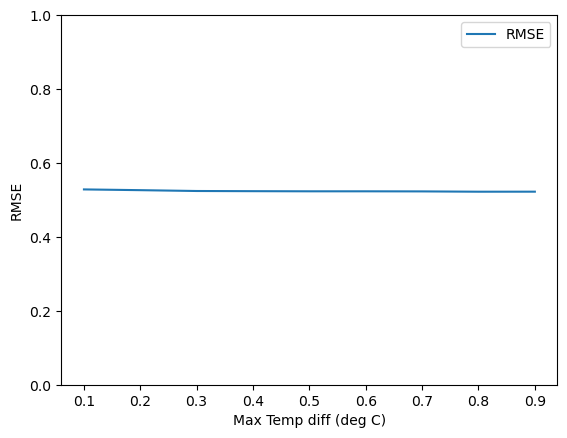

In [426]:
plt.plot(np.arange(0,1,0.1),rmse_with_depth,label='RMSE')
# plt.plot(std_with_depth,label='STD')
# plt.xlabel('Max depth (m)')
plt.xlabel('Max Temp diff (deg C)')
plt.ylabel('RMSE')
plt.ylim(0,1)
plt.legend()

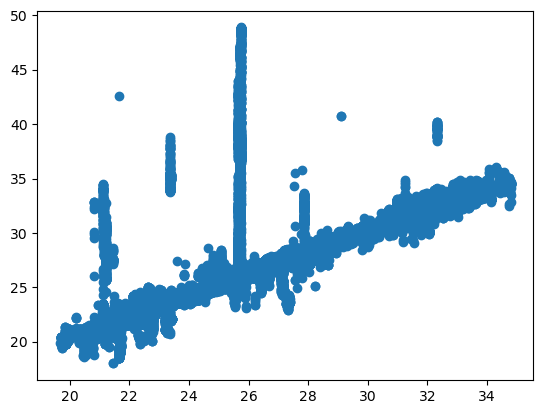

In [386]:
plt.plot(fmm2_dn2,ds_dive_2_filtered_dn2,'o')

In [353]:
ds_dive_2_filtered_dn

array([29.1015625, 29.0703125, 29.078125 , ..., 24.8984375, 24.8828125,
       24.8671875])

/tmp/ipykernel_2645486/600399509.py:9: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  plt.scatter(fmm2,ds_dive_2_filtered.where(ds_dive_2_filtered.rec_len>70).temp1,color='r',s=2,vmax=50,vmin=0)


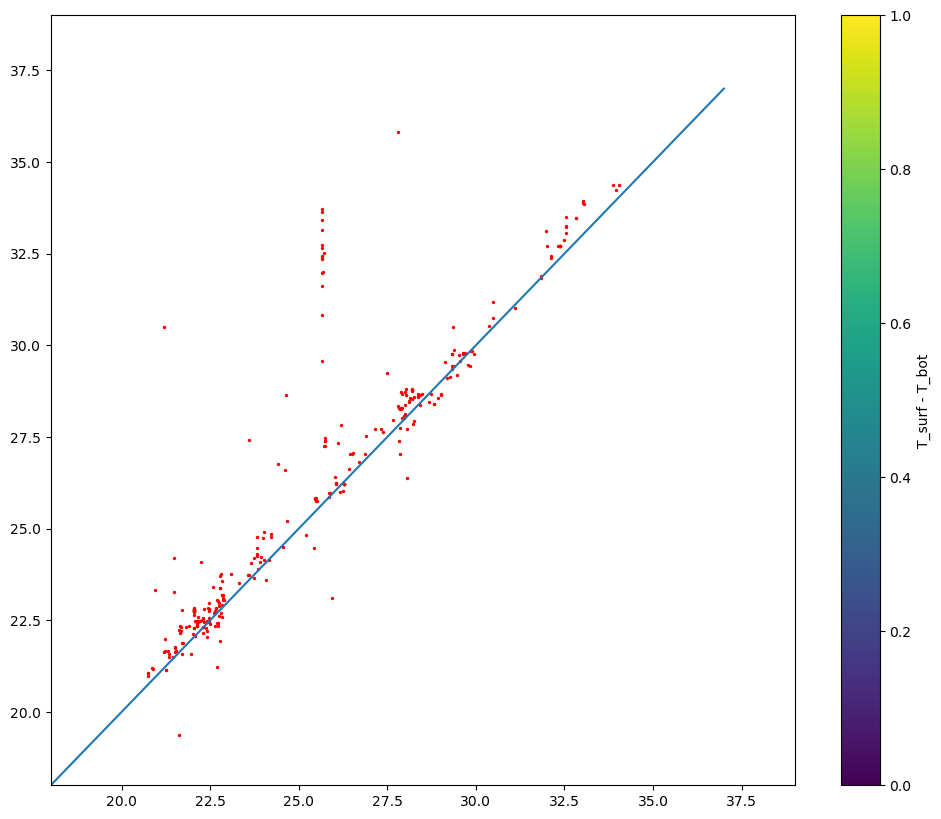

In [208]:
plt.figure(figsize=(12,10))

# plt.scatter(fmm2,ds_dive_2.where(ds_dive_2.rec_len>50).temp1,c=ds_dive_2.rec_len,cmap='Reds',s=2,vmax=50,vmin=0)
# plt.scatter(fmm2,ds_dive_2.where(ds_dive_2.rec_len>50).temp1,color='b',s=2,vmax=50,vmin=0)
# plt.scatter(fmm2,ds_dive_2_filtered.where(ds_dive_2_filtered.rec_len>60).temp1,color='g',s=2,vmax=50,vmin=0)
# plt.scatter(fmm2,ds_dive_2_filtered.where(ds_dive_2_filtered.rec_len>30).temp1,c=ds_dive_2_filtered.rec_len,s=2,vmax=50,vmin=0)
# plt.scatter(fmm2,ds_dive_2_filtered.where(ds_dive_2_filtered.rec_len>30).temp1,c=ds_dive_2_filtered.temp0-ds_dive_2_filtered.temp1,cmap='RdBu',s=2,vmax=1,vmin=-1)
# plt.scatter(fmm2,ds_dive_2_filtered.where(ds_dive_2_filtered.rec_len>70).temp0,color='k',s=2,vmax=50,vmin=0)
plt.scatter(fmm2,ds_dive_2_filtered.where(ds_dive_2_filtered.rec_len>70).temp1,color='r',s=2,vmax=50,vmin=0)
# plt.scatter(fmm2,ds_dive_2.where(ds_dive_2.rec_len>80).temp1,color='k',s=2,vmax=50,vmin=0)
# plt.scatter(fmm2,ds_dive_2.where(ds_dive_2.rec_len>80).temp1,color='r',s=2,vmax=50,vmin=0)

plt.xlim([18, 39]),plt.ylim([18, 39])
plt.plot([18,37],[18,37])
plt.colorbar(label='T_surf - T_bot')

In [245]:
tau = 4

T0 = ds_dive_2_filtered.temp0
Tm = ds_dive_2_filtered.temp1
tf = ds_dive_2_filtered.rec_len

eps = (1-np.exp(-tf/tau))/(1-T0/Tm*np.exp(-tf/tau))


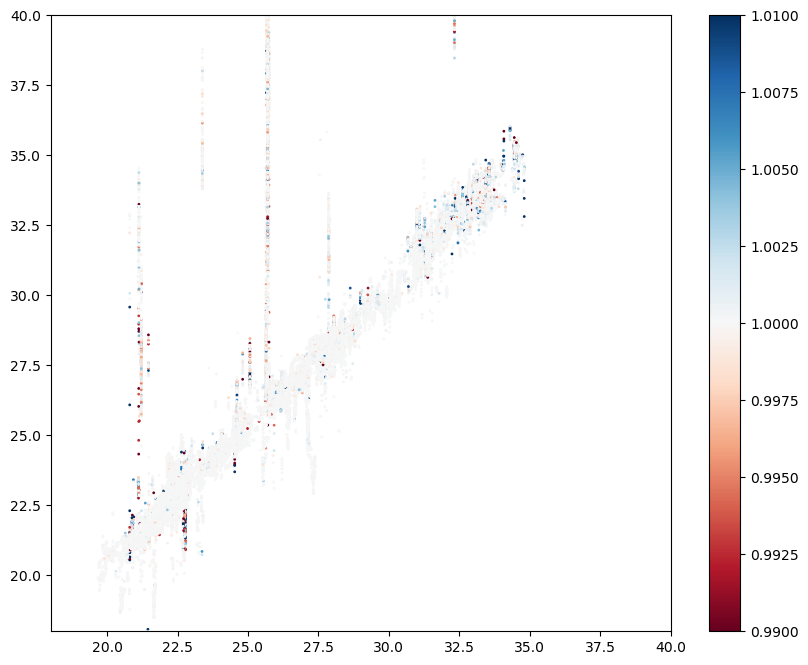

In [246]:
plt.figure(figsize=(10,8))
plt.scatter(fmm2,ds_dive_2_filtered.temp1,c=eps,s=1,vmin=0.99,vmax=1.01,cmap='RdBu',alpha=1)
plt.xlim([18, 40]),plt.ylim([18, 40])

plt.colorbar()

Standard Deviation: <xarray.DataArray ()>
array(2.69893244)
Root Mean Square Error: <xarray.DataArray ()>
array(2.84446121)
Standard Deviation (filtered): <xarray.DataArray ()>
array(2.41114028)
Root Mean Square Error (filtered): <xarray.DataArray ()>
array(2.52033403)


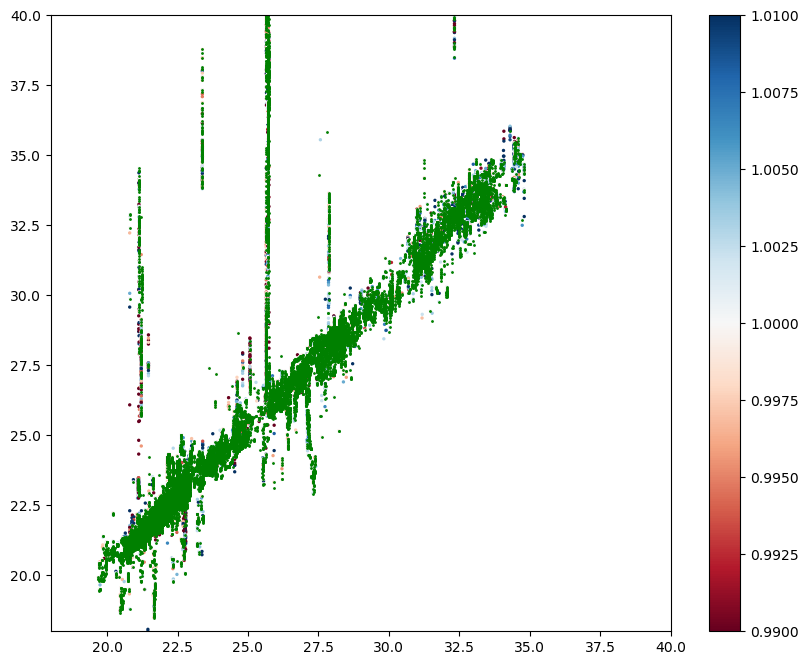

In [221]:
plt.figure(figsize=(10,8))
plt.scatter(fmm2,ds_dive_2_filtered.temp1,c=eps,s=2,vmin=0.99,vmax=1.01,cmap='RdBu')
plt.colorbar()
# plt.scatter(fmm2,ds_dive_2_filtered.where((eps>1.002)|(eps<0.998)).temp1,s=1,c='g')

plt.scatter(fmm2,ds_dive_2_filtered.where((eps<1.002)&(eps>0.998)).temp1,s=1,c='g')
plt.xlim([18, 40]),plt.ylim([18, 40])
std_dev = np.std(fmm2 - ds_dive_2_filtered.temp1)
print(f'Standard Deviation: {std_dev}')

rmse = np.sqrt(np.mean((fmm2 - ds_dive_2_filtered.temp1)**2))
print(f'Root Mean Square Error: {rmse}')

std_dev_filtered = np.std(fmm2 - ds_dive_2_filtered.where((eps < 1.002) & (eps > 0.998)).temp1)
print(f'Standard Deviation (filtered): {std_dev_filtered}')

rmse_filtered = np.sqrt(np.mean((fmm2 - ds_dive_2_filtered.where((eps < 1.002) & (eps > 0.998)).temp1)**2))
print(f'Root Mean Square Error (filtered): {rmse_filtered}')

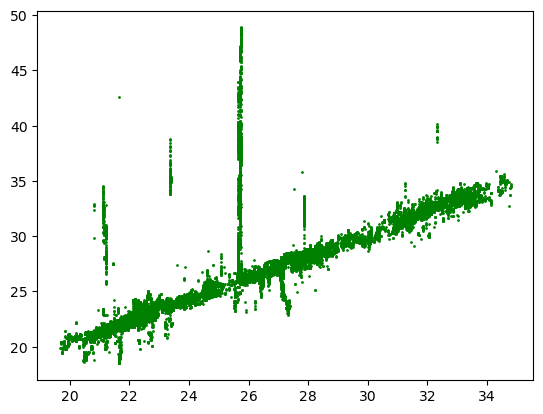

In [212]:

# plt.scatter(fmm2,ds_dive_2_filtered.where((eps>1.002)|(eps<0.998)).temp1,s=1,c='g')

plt.scatter(fmm2,ds_dive_2_filtered.where((eps<1.002)&(eps>0.998)).temp1,s=1,c='g')

/tmp/ipykernel_2645486/3674477829.py:3: RuntimeWarning: invalid value encountered in divide
  return (1 - np.exp(-t/tau)) / (1 - (T0 / T_obs) * np.exp(-t/tau))


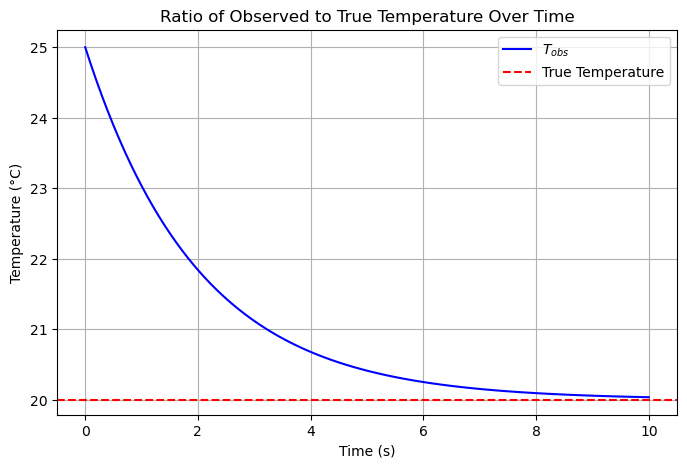

In [244]:

# Define function for the ratio
def temp_ratio(t, T0, T_obs, tau):
    return (1 - np.exp(-t/tau)) / (1 - (T0 / T_obs) * np.exp(-t/tau))

# Time range
t = np.linspace(0, 10, 100)  # Time from 0 to 10 seconds

# Example parameters
T0 = 25.0  # Initial sensor temperature
T_true = 20.0  # True water temperature
tau = 2.0  # Response time

# Compute T_obs from the model
T_obs = T_true + (T0 - T_true) * np.exp(-t/tau)

# Compute ratio
ratio = temp_ratio(t, T0, T_obs, tau)

# Plot
plt.figure(figsize=(8, 5))
# plt.plot(t, ratio, label=r'$\frac{T_{obs}}{T_{true}}$', color='b')
plt.plot(t, T_obs, label=r'${T_{obs}}$', color='b')
plt.axhline(T_true, linestyle='--', color='r', label='True Temperature')
plt.xlabel("Time (s)")
plt.ylabel("Temperature (°C)")
plt.title("Ratio of Observed to True Temperature Over Time")
plt.legend()
plt.grid()
plt.show()

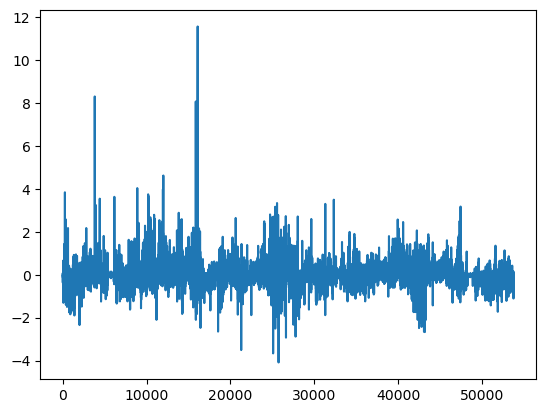

In [214]:
plt.plot(ds_dive_2_filtered.temp0-ds_dive_2_filtered.temp1)
# plt.plot(ds_dive_2.temp1)

In [221]:
ds_dive_2_filtered.where(ds_dive_2_filtered.rec_len>70,drop=True)

<xarray.Dataset>
Dimensions:       (dive_index: 911)
Coordinates:
  * dive_index    (dive_index) float64 1.456e+04 1.608e+04 ... 1.389e+04
Data variables:
    tag_id        (dive_index) float64 2.372e+05 2.372e+05 ... 2.373e+05
    temp1         (dive_index) float64 19.88 20.91 20.73 ... 20.59 20.62 20.53
    temp0         (dive_index) float64 19.88 20.61 20.62 ... 20.46 20.02 20.51
    rec_len       (dive_index) float64 72.0 76.0 76.0 74.0 ... 73.0 75.0 72.0
    first_record  (dive_index) float64 3.988e+05 4.46e+05 ... 3.761e+05
    last_record   (dive_index) float64 3.989e+05 4.461e+05 ... 3.761e+05
    lon           (dive_index) float64 50.39 50.31 50.36 ... 50.53 50.42 50.62
    lat           (dive_index) float64 25.56 25.98 25.99 ... 25.5 25.68 25.41
    time          (dive_index) datetime64[ns] 2024-02-13T07:54:41 ... 2024-03...

Estimated Response Time (tau): 0.10 seconds
Case 1: Estimated True Water Temperature = 25.68
Case 1: Initial Temperature = 26.56
Case 1: Measured Temperature = 25.68
Case 1: response time = 39.00


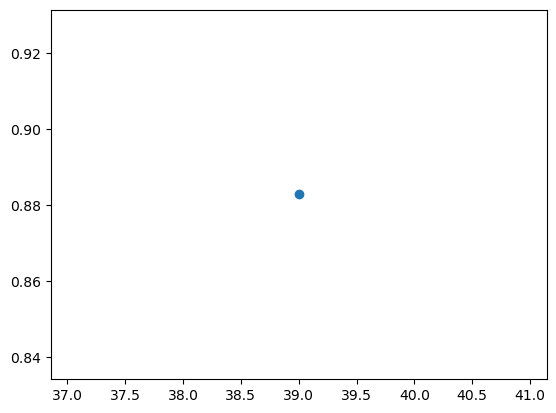

In [271]:
from scipy.optimize import minimize

# # Example dataset: each row is (T0, t_obs, T_obs)
# data = np.array([
#     [10.0, 1, 15.0],  # Case 1: (T0, t_obs, T_obs)
#     [12.0, 2, 17.5],  # Case 2
#     [11.0, 3, 18.2],  # Case 3
#     [9.0, 1.5, 14.5], # Case 4
# ])

# # Extract values
# T0_all = data[:, 0]  # Initial sensor temperatures
# t_obs_all = data[:, 1]  # Time after sensor in water
# T_obs_all = data[:, 2]  # Observed temperatures
# n_cases = len(data)  # Number of cases

# data = ds_dive_2_filtered.where(ds_dive_2_filtered.rec_len<10,drop=True)
data = ds000.dropna(dim='dive_index')
t_obs_all = data.rec_len.values[0:1]
T_obs_all = data['temp1'].values[0:1]
T0_all = data['temp0'].values[0:1]
n_cases = len(t_obs_all)  # Number of cases

# Objective function: minimizes the squared error
def objective(params):
    tau = params[0]  # First parameter is the shared tau
    T_true_all = params[1:]  # Remaining parameters are T_true for each case
    model_T_obs = T_true_all + (T0_all - T_true_all) * np.exp(-t_obs_all / tau)
    return np.sum((T_obs_all - model_T_obs) ** 2)  # Sum of squared errors

# Initial guesses: tau=5s, each T_true starts from T_obs (reasonable assumption)
initial_guess = np.concatenate(([0.02], T_obs_all))

# Run optimization
result = minimize(objective, initial_guess, method='L-BFGS-B', bounds=[(0.1, None)] + [(None, None)] * n_cases)

# Extract fitted tau and T_true values
tau_fit = result.x[0]
T_true_fit = result.x[1:]

print(f"Estimated Response Time (tau): {tau_fit:.2f} seconds")
for i, T_true in enumerate(T_true_fit):
    print(f"Case {i+1}: Estimated True Water Temperature = {T_true:.2f}")
    print(f"Case {i+1}: Initial Temperature = {T0_all[i]:.2f}")
    print(f"Case {i+1}: Measured Temperature = {T_obs_all[i]:.2f}")
    print(f"Case {i+1}: response time = {t_obs_all[i]:.2f}")

plt.plot(t_obs_all,T0_all-T_obs_all,'o')

In [208]:
ds_dive_2_filtered

<xarray.Dataset>
Dimensions:       (dive_index: 53776)
Coordinates:
  * dive_index    (dive_index) float64 0.0 1.0 2.0 3.0 ... 960.0 961.0 962.0
Data variables: (12/13)
    tag_id        (dive_index) float64 2.014e+05 2.014e+05 ... 2.03e+05 2.03e+05
    temp1         (dive_index) float64 29.1 29.07 29.08 ... 24.9 24.88 24.87
    temp0         (dive_index) float64 29.02 29.15 29.06 ... 24.89 24.66 24.88
    temp_int1     (dive_index) float64 31.0 31.0 31.0 31.0 ... 26.0 25.0 26.0
    temp_int0     (dive_index) float64 30.0 31.0 31.0 31.0 ... 26.0 26.0 25.0
    rec_len       (dive_index) float64 39.0 52.0 36.0 39.0 ... 35.0 61.0 36.0
    ...            ...
    last_record   (dive_index) float64 5.513e+04 5.519e+04 ... 6.222e+04
    depth_max     (dive_index) float64 13.68 13.69 13.73 ... 16.72 16.01 16.04
    lon           (dive_index) float64 53.15 53.15 53.15 ... 53.26 53.27 53.27
    lat           (dive_index) float64 24.68 24.68 24.68 ... 24.7 24.69 24.69
    time          (dive_index) datetime64[ns] 2020-11-14T06:28:34 ... 2020-12...
    date          (dive_index) object 2020-11-14 2020-11-14 ... 2020-12-11

In [336]:
ds_dive_2_filtered = ds_dive_2_filtered.where(ds_dive_2_filtered.depth_max>3)

In [400]:
## make daily average

# Add a new variable for the date component of the time variable
# ds_dive_2_filtered = ds_dive_2_filtered.assign(date=ds_dive_2_filtered.time.dt.date)

# Group by tag_id and the new date variable
# Initialize an empty list to store the results for each tag_id
daily_averages = []

# Loop through each unique tag_id
for tag in np.unique(ds_dive_2_filtered.tag_id):
    # Filter the dataset for the current tag_id
    tag_data = ds_dive_2_filtered.where((ds_dive_2_filtered.tag_id == tag)&(ds_dive_2_filtered.depth_max>1), drop=True)
    
    # Group by the date component of the time variable and calculate the mean
    daily_mean = tag_data.groupby(tag_data.time.dt.date).mean()
    
    # Add the tag_id as a coordinate to the daily mean dataset
    # daily_mean = daily_mean.assign_coords(tag_id=tag)
    
    # Append the daily mean dataset to the list
    daily_averages.append(daily_mean)

# Combine all the daily averages into a single xarray dataset
ds_dive_2_filtered_daily = xr.concat(daily_averages, dim='date')


In [341]:
np.unique(ds_dive_2_filtered.tag_id)

array([201410., 201411., 201420., 203013., 203014., 203018., 203027.,
       203031., 203034., 203040.,     nan])

In [401]:
ds_dive_2_filtered_daily['time'] = ds_dive_2_filtered_daily.date
ds_dive_2_filtered_daily.assign_coords(time=ds_dive_2_filtered_daily.date)
ds_dive_2_filtered_daily = ds_dive_2_filtered_daily.swap_dims({'date': 'time'}).drop_vars('date')

In [402]:
ds_dive_2_filtered_daily['time'] = pd.to_datetime(ds_dive_2_filtered_daily.time)

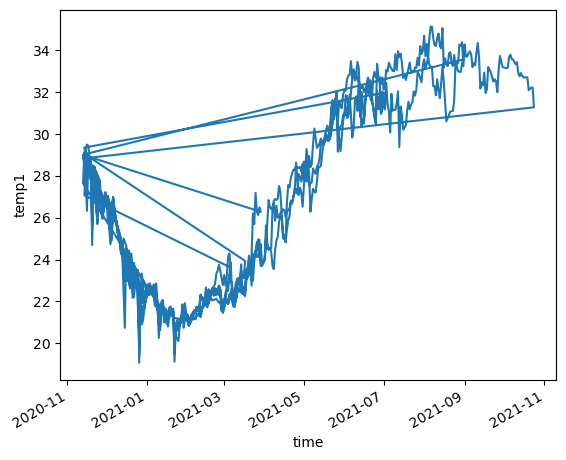

In [403]:
ds_dive_2_filtered_daily.temp1.plot()

In [404]:
# ffm = ds_dive_2_filtered_daily
ffm_daily = ds_mur_sec1.interp(lon=ds_dive_2_filtered_daily.lon,lat=ds_dive_2_filtered_daily.lat,time=pd.to_datetime(ds_dive_2_filtered_daily.time)) #original
ffm_daily  

<xarray.DataArray 'sst' (time: 1218)>
array([28.80966129, 28.79611041, 28.24915479, ..., 26.26088463,
       25.21274679, 24.501662  ])
Coordinates:
    lon      (time) float64 53.15 53.09 53.01 52.88 ... 53.16 53.11 53.09 53.25
    lat      (time) float64 24.69 24.77 24.67 24.63 ... 24.77 24.83 24.82 24.71
  * time     (time) datetime64[ns] 2020-11-14 2020-11-15 ... 2020-12-11

/tmp/ipykernel_553418/2286596094.py:2: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'vmin', 'vmax' will be ignored
  plt.scatter(fmm2,ds_dive_2_filtered.where(ds_dive_2_filtered.depth_max>1).temp1,c='r',cmap='RdBu',s=2,vmax=1,vmin=-1)
/tmp/ipykernel_553418/2286596094.py:3: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'vmin', 'vmax' will be ignored
  plt.scatter(ffm_daily.values,ds_dive_2_filtered_daily.temp1.values,c='k',cmap='RdBu',s=2,vmax=1,vmin=-1)


((18.0, 37.0), (18.0, 37.0))

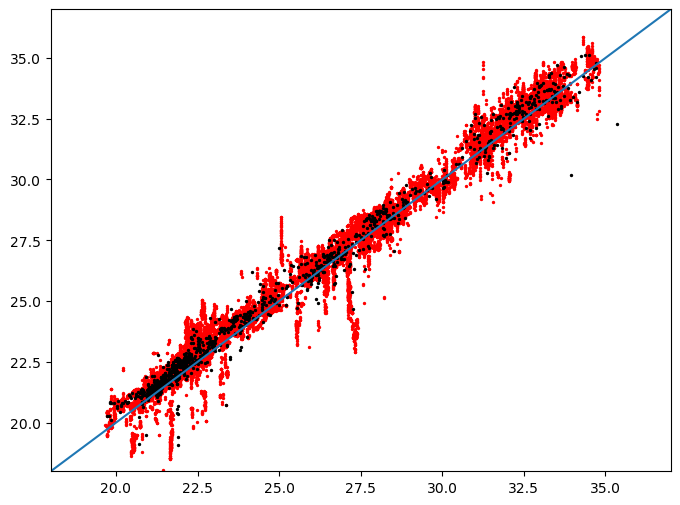

In [407]:
plt.figure(figsize=(8,6))
plt.scatter(fmm2,ds_dive_2_filtered.where(ds_dive_2_filtered.depth_max>1).temp1,c='r',cmap='RdBu',s=2,vmax=1,vmin=-1)
plt.scatter(ffm_daily.values,ds_dive_2_filtered_daily.temp1.values,c='k',cmap='RdBu',s=2,vmax=1,vmin=-1)
plt.plot([18,37],[18,37])

plt.xlim(18,37),plt.ylim(18,37)

In [408]:
from sklearn.metrics import mean_squared_error
import numpy as np

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(ds_dive_2_filtered_daily.temp1.values, ffm_daily.values))
print(f"RMSE: {rmse}")

ValueError: Input contains NaN.

In [307]:
import numpy as np
from scipy.optimize import curve_fit

# Example dataset: each row is (T0, t_obs, T_obs)
# data = np.array([
#     [10.0, 10, 15.0],  # Case 1: (T0, t_obs, T_obs)
#     [12.0, 20, 17.5],  # Case 2
#     [11.0, 30, 18.2],  # Case 3
#     [9.0, 15, 14.5], # Case 4
# ])

# Extract values
# T0_all = data[:, 0]  # Initial sensor temperatures
# t_obs_all = data[:, 1]  # Time after sensor in water
# T_obs_all = data[:, 2]  # Observed temperatures

# data = ds_dive_2_filtered.where(ds_dive_2_filtered.rec_len<10,drop=True)
data = ds000.dropna(dim='dive_index')
t_obs_all = data.rec_len.values[0:]
T_obs_all = (data['temp1'].values-data['temp0'].values)[0:]
T0_all = data['temp0'].values[0:]*0

# Define the model function
def temperature_model(t, tau, C):
    return T0_all + C * np.exp(-t / tau)

# Initial guess for tau and C
initial_guess = [0.000001, np.mean(T_obs_all)]  # Guess tau=5s, C=mean observed temp

# Fit the model
popt, pcov = curve_fit(temperature_model, t_obs_all, T_obs_all, p0=initial_guess)

# Extract fitted parameters
tau_fit, C_fit = popt

print(f"Estimated Response Time (tau): {tau_fit:.2f} seconds")
print(f"Estimated Final Temperature (C): {C_fit:.2f}")
for i in range(len(T0_all)):
    print(i)
    print(f"Case {i+1}: Initial Temperature = {T0_all[i]:.2f}")
    print(f"Case {i+1}: Measured Temperature = {T_obs_all[i]:.2f}")
    print(f"Case {i+1}: response time = {t_obs_all[i]:.2f}")

    # Calculate the predicted temperatures using the fitted model
T_predict = temperature_model(t_obs_all, tau_fit, C_fit)

# Print the predicted temperatures
for i in range(len(T_predict)):
    print(f"Case {i+1}: Predicted Temperature = {T_predict[i]:.2f}")

Estimated Response Time (tau): 0.00 seconds
Estimated Final Temperature (C): -1.27
0
Case 1: Initial Temperature = 0.00
Case 1: Measured Temperature = -0.88
Case 1: response time = 39.00
1
Case 2: Initial Temperature = 0.00
Case 2: Measured Temperature = -0.84
Case 2: response time = 37.00
2
Case 3: Initial Temperature = 0.00
Case 3: Measured Temperature = -1.06
Case 3: response time = 36.00
3
Case 4: Initial Temperature = 0.00
Case 4: Measured Temperature = -0.94
Case 4: response time = 31.00
4
Case 5: Initial Temperature = 0.00
Case 5: Measured Temperature = -1.03
Case 5: response time = 38.00
5
Case 6: Initial Temperature = 0.00
Case 6: Measured Temperature = -0.91
Case 6: response time = 33.00
6
Case 7: Initial Temperature = 0.00
Case 7: Measured Temperature = -0.84
Case 7: response time = 32.00
7
Case 8: Initial Temperature = 0.00
Case 8: Measured Temperature = -0.86
Case 8: response time = 33.00
8
Case 9: Initial Temperature = 0.00
Case 9: Measured Temperature = -1.18
Case 9: res

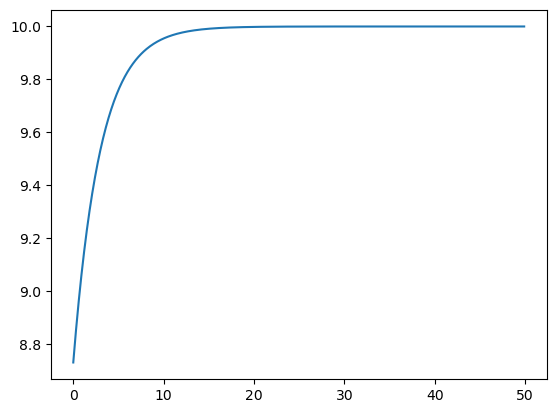

In [309]:
t00 = np.arange(0, 50, 0.1)
tau0 = 3
y00= 10 + C_fit*np.exp(-t00/tau0)
plt.plot(t00,y00)

# all tags